<a href="https://colab.research.google.com/github/cl2832/CHEME-5660-CourseRepository-Fall-2025/blob/main/GTG_performance/OLS_vs_GBT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CHP Causal Regression — OLS vs GBT Total-Effect Comparison
## Cornell Combined Heat and Power Plant
### Power & Fuel outcomes × OLS/GBT × Spec A/B × Plugin + AIPW

**Pipeline**: Load → CONFIG → Prepare → OLS baseline (original) → **New Section 7**: Fair OLS-vs-GBT comparison with day-block split, dual outcomes, AIPW


---
## Section 0. Setup & load data
包含套件安裝、imports、Drive/Repo、讀取資料與 CONFIG。


In [ ]:
# ============================================================================
# INSTALL LIGHTGBM (required for GBT section)
# ============================================================================
!pip install -q lightgbm


In [ ]:
# ============================================================================
# ALL IMPORTS (single cell, no duplicates)
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from pathlib import Path
import warnings, os, sys, time
warnings.filterwarnings('ignore')

import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import dmatrix, bs, cr
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMRegressor

SEED = 42
np.random.seed(SEED)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (14, 5),
                     'axes.grid': True, 'grid.alpha': 0.3})
print('All imports done (incl. LightGBM, LogisticRegression)')


All imports done (incl. LightGBM, LogisticRegression)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted


In [ ]:
from google.colab import userdata
!rm -rf /content/insight-chp
token = userdata.get('GITHUB_TOKEN')
!git clone https://{token}@github.com/cl2832/insight-chp.git /content/insight-chp
sys.path.insert(0, '/content/insight-chp/GTG_performance')
from src.chp_preprocessing import load_and_preprocess
print('Import successful')


Cloning into '/content/insight-chp'...
remote: Enumerating objects: 352, done.
remote: Counting objects: 100% (154/154), done.
remote: Compressing objects: 100% (147/147), done.
remote: Total 352 (delta 93), reused 20 (delta 6), pack-reused 198 (from 1)
Receiving objects: 100% (352/352), 13.31 MiB | 9.00 MiB/s, done.
Resolving deltas: 100% (198/198), done.
Import successful


In [ ]:
results = load_and_preprocess(
    data_path='/content/drive/MyDrive/M.Eng._Project/Data/chp_raw_data/'
              'merged_chp_data_jul2025_canonical.xlsx',
    cache_dir='/content/drive/MyDrive/M.Eng._Project/Data/chp_raw_data',
    power_threshold_mw=11.0,
    filtering_mode='manual',
    show_plots=False,
    cooling_mode='binary',
)

df      = results['df']
df_ct1  = results['df_ct1']
df_ct2  = results['df_ct2']
df_both = results['df_both']
print(f'df_ct1: {len(df_ct1):,}  |  df_ct2: {len(df_ct2):,}')

# Quick check for fuel column
for ct_p in ['ct1', 'ct2']:
    fuel_col = f'{ct_p}_gas_fuel_flow_lbph'
    has_it = fuel_col in df_ct1.columns or fuel_col in df_ct2.columns
    print(f'  {fuel_col}: {"FOUND" if has_it else "NOT FOUND"}')


📦 Loading from CACHE: /content/drive/MyDrive/M.Eng._Project/Data/chp_raw_data/merged_chp_data_jul2025_canonical.pkl
   ✅ 44,688 rows × 90 columns

CALCULATING PERFORMANCE METRICS

📊 CT1 Metrics:
   ✓ ct1_power_mw
   ✓ ct1_heat_input_mmbtu_h
   ✓ ct1_efficiency_pct (avg: 25.65%, 44,176 valid)

📊 CT2 Metrics:
   ✓ ct2_power_mw
   ✓ ct2_heat_input_mmbtu_h
   ✓ ct2_efficiency_pct (avg: 31.02%, 44,623 valid)

❄️  IAC Status:
   ✓ cooling_on  (BINARY mode, threshold: 50.0 GPM)
     • Flow range: -2.9 – 1172.7 GPM
     • ON:  20,476 records
     • OFF: 24,212 records

OPERATIONAL STATUS SUMMARY
Threshold: 11.0 MW

CT1:  Operating 35,820 (80.2%)  |  Offline 8,868 (19.8%)
CT2:  Operating 44,612 (99.8%)  |  Offline 76 (0.2%)

Combined:
  Both ON:   35,804  (80.1%)
  CT1 only:  16  (0.0%)
  CT2 only:  8,808  (19.7%)
  Both OFF:  60  (0.1%)

SMART FILTERING (INDEPENDENT CT1 & CT2)

🎯 MANUAL MODE: fixed thresholds
   CT1: > 11.0 MW
   CT2: > 11.0 MW

📊 Filtering Results:
  Original:      44,688 rec


### CONFIG（Single source of truth）


In [ ]:
# ============================================================================
# NESTED CONFIG (original + new comparison section)
# ============================================================================
CONFIG = {
    'data': {
        'train_temp_range_F':  (55, 110),
        'report_temp_range_F': (55, 110),
    },
    'treatment': {
        'method':           'full_vs_off',
        'switch_window_min': 10,
    },
    'model': {
        'spec': 'A',
    },
    'overlap': {
        'enabled':          True,
        'strategy':         'strong_grid',
        'temp_bin_width_F': 2.5,
        'strong_min':       50,
        'weak_min':         20,
        'min_total':        50,
        'on_rate_lo':       0.10,
        'on_rate_hi':       0.90,
    },
    'bootstrap': {
        'n_iterations':  500,
        'ci_level':      0.95,
    },
    'diagnostics': {
        'enabled':              True,
        'binned_diff_width_F':  2,
        'test_days_frac':       0.2,
        'mccv_repeats':         30,
        'jackknife_enabled':    True,
        'jackknife_max_days':   40,
    },
    # --- NEW: comparison section ---
    'compare': {
        'test_days_frac':  0.20,
        'boot_n':          500,
        'boot_ci':         0.95,
        'propensity_clip': (0.02, 0.98),
        'lgbm_params': {
            'n_estimators': 150,
            'learning_rate': 0.05,
            'max_depth': 4,
            'num_leaves': 15,
            'min_child_samples': 50,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'random_state': 42,
            'n_jobs': -1,
            'verbose': -1,
        },
    },
    'seed':       42,
    'output_dir': './outputs',
}

os.makedirs(CONFIG['output_dir'], exist_ok=True)
np.random.seed(CONFIG['seed'])

def _pp(d, indent=0):
    for k, v in d.items():
        if isinstance(v, dict):
            print(' '*indent + f'{k}:')
            _pp(v, indent+4)
        else:
            print(' '*indent + f'{k:25s} = {v}')

print('CONFIG:'); _pp(CONFIG)


# Convenience alias
OUT = CONFIG['output_dir']


CONFIG:
data:
    train_temp_range_F        = (55, 110)
    report_temp_range_F       = (55, 110)
treatment:
    method                    = full_vs_off
    switch_window_min         = 10
model:
    spec                      = A
overlap:
    enabled                   = True
    strategy                  = strong_grid
    temp_bin_width_F          = 2.5
    strong_min                = 50
    weak_min                  = 20
    min_total                 = 50
    on_rate_lo                = 0.1
    on_rate_hi                = 0.9
bootstrap:
    n_iterations              = 500
    ci_level                  = 0.95
diagnostics:
    enabled                   = True
    binned_diff_width_F       = 2
    test_days_frac            = 0.2
    mccv_repeats              = 30
    jackknife_enabled         = True
    jackknife_max_days        = 40
compare:
    test_days_frac            = 0.2
    boot_n                    = 500
    boot_ci                   = 0.95
    propensity_clip           = (0.02, 

---
## Section 1. General helper function
與模型無關：treatment、資料清理、Overlap 與通用視覺化。


### 1a. Data Preparation (treatment + decontaminate + filter)

In [ ]:
# ============================================================================
# prepare_df: treatment assignment + decontamination + temp filter + time cols
# ============================================================================

def assign_treatment(df, method='full_vs_off'):
    flow = df['iac_cw_flow_gpm']
    if method == 'simple':
        return (flow > 50).astype(float)
    elif method == 'deadband':
        D = pd.Series(np.nan, index=df.index)
        D[flow >= 60] = 1.0
        D[flow <= 40] = 0.0
        return D
    elif method == 'full_vs_off':
        D = pd.Series(np.nan, index=df.index)
        D[flow >= 500] = 1.0
        D[flow <= 20]  = 0.0
        return D
    else:
        raise ValueError(f'Unknown method: {method}')

def decontaminate_switches(df, d_col='D', ts_col='TimeStamp', window_min=10):
    df = df.sort_values(ts_col).copy()
    d = df[d_col]
    change_idx = d.ne(d.shift()).fillna(False)
    change_times = df.loc[change_idx, ts_col]
    window = pd.Timedelta(minutes=window_min)
    mask_keep = pd.Series(True, index=df.index)
    for ct in change_times:
        mask_keep &= ~df[ts_col].between(ct - window, ct + window)
    return df[mask_keep]

def prepare_df(df_raw, ct_label, temp_range, treatment_cfg):
    df = df_raw.copy()
    df['D'] = assign_treatment(df, treatment_cfg['method'])
    n0 = len(df)
    df = df.dropna(subset=['D'])
    print(f"  {ct_label}: treatment '{treatment_cfg['method']}' -> "
          f'dropped {n0 - len(df):,} partial rows')
    n1 = len(df)
    df = decontaminate_switches(df, window_min=treatment_cfg['switch_window_min'])
    print(f"  {ct_label}: decontamination (+/-{treatment_cfg['switch_window_min']}min) "
          f'-> dropped {n1 - len(df):,} rows')
    lo, hi = temp_range
    df = df[df['ambient_air_temp_f'].between(lo, hi)].copy()
    print(f'  {ct_label}: temp [{lo}-{hi}F] -> {len(df):,} rows')
    df['hour'] = df['TimeStamp'].dt.hour
    df['day']  = df['TimeStamp'].dt.date
    return df

print('prepare_df defined')


prepare_df defined


### 1b. Overlap Filter (strong-grid, fast vectorized)

In [ ]:
# ============================================================================
# apply_overlap_filter
# ============================================================================

def _build_overlap_grid(df, ovl_cfg):
    bw = ovl_cfg['temp_bin_width_F']
    lo = np.floor(df['ambient_air_temp_f'].min() / bw) * bw
    hi = np.ceil(df['ambient_air_temp_f'].max() / bw) * bw + bw
    bins = np.arange(lo, hi, bw)
    tmp = df.copy()
    tmp['temp_bin'] = pd.cut(tmp['ambient_air_temp_f'], bins=bins)
    grid = tmp.groupby(['temp_bin', 'hour'])['D'].agg(
        n_on  = lambda x: (x == 1).sum(),
        n_off = lambda x: (x == 0).sum(),
        n_total = 'count',
    ).reset_index()
    grid['on_rate']   = grid['n_on'] / grid['n_total'].clip(lower=1)
    grid['min_count'] = grid[['n_on', 'n_off']].min(axis=1)
    def classify(r):
        if r['n_total'] < ovl_cfg['min_total'] or r['min_count'] < ovl_cfg['weak_min']:
            return 'none'
        if (r['min_count'] >= ovl_cfg['strong_min']
            and ovl_cfg['on_rate_lo'] <= r['on_rate'] <= ovl_cfg['on_rate_hi']):
            return 'strong'
        return 'weak'
    grid['overlap_class'] = grid.apply(classify, axis=1)
    grid['class_num'] = grid['overlap_class'].map({'none':0,'weak':1,'strong':2})
    return grid, bins

def _build_strong_mask(df, grid, bins):
    tmp = df.copy()
    tmp['temp_bin'] = pd.cut(tmp['ambient_air_temp_f'], bins=bins)
    tmp['tb_str']   = tmp['temp_bin'].astype(str)
    strong = grid[grid['overlap_class']=='strong'][['temp_bin','hour']].copy()
    strong['tb_str'] = strong['temp_bin'].astype(str)
    strong['_s'] = True
    merged = tmp[['tb_str','hour']].merge(
        strong[['tb_str','hour','_s']], on=['tb_str','hour'], how='left')
    mask = merged['_s'].fillna(False).values
    return pd.Series(mask, index=df.index), tmp['temp_bin']

def _overlap_summary(grid):
    ct = pd.crosstab(grid['temp_bin'], grid['overlap_class'])
    for c in ['none','weak','strong']:
        if c not in ct.columns: ct[c] = 0
    ct = ct[['none','weak','strong']]
    ct['total_hours'] = ct.sum(axis=1)
    ct['strong_pct']  = (ct['strong']/ct['total_hours']*100).round(1)
    return ct.reset_index()

def apply_overlap_filter(df, ovl_cfg):
    grid, bins = _build_overlap_grid(df, ovl_cfg)
    mask, temp_bins = _build_strong_mask(df, grid, bins)
    summary = _overlap_summary(grid)
    df_strong = df[mask.values].copy()
    df_strong['temp_bin'] = temp_bins[mask.values].values
    vc = grid['overlap_class'].value_counts()
    meta = {
        'grid': grid, 'summary': summary, 'bins': bins,
        'mask': mask, 'temp_bins': temp_bins,
        'n_strong_cells': int(vc.get('strong',0)),
        'n_weak_cells':   int(vc.get('weak',0)),
        'n_none_cells':   int(vc.get('none',0)),
        'n_rows_base':    len(df),
        'n_rows_strong':  len(df_strong),
        'strong_frac':    len(df_strong)/max(len(df),1),
    }
    return df_strong, meta

print('Overlap helpers defined')


Overlap helpers defined


### 1c. Overlap Heatmap Plots

In [ ]:
# ============================================================================
# plot_overlap_heatmaps
# ============================================================================

def plot_overlap_heatmaps(grid, ct_label, out_dir):
    g = grid.copy(); g['tb_str'] = g['temp_bin'].astype(str)
    piv_rate  = g.pivot(index='tb_str', columns='hour', values='on_rate')
    piv_min   = g.pivot(index='tb_str', columns='hour', values='min_count')
    piv_class = g.pivot(index='tb_str', columns='hour', values='class_num')
    nh = max(6, len(piv_rate)*0.35)
    fig, axes = plt.subplots(1,3,figsize=(22,nh))
    im=axes[0].imshow(piv_rate.values,aspect='auto',cmap='RdYlGn_r',vmin=0,vmax=1,origin='lower')
    axes[0].set_xticks(range(piv_rate.shape[1])); axes[0].set_xticklabels(piv_rate.columns,fontsize=7)
    axes[0].set_yticks(range(piv_rate.shape[0])); axes[0].set_yticklabels(piv_rate.index,fontsize=7)
    axes[0].set_xlabel('Hour'); axes[0].set_ylabel('Temp Bin')
    axes[0].set_title(f'{ct_label}: ON Rate'); plt.colorbar(im,ax=axes[0],shrink=0.7)
    im=axes[1].imshow(piv_min.values,aspect='auto',cmap='YlOrRd',vmin=0,origin='lower')
    axes[1].set_xticks(range(piv_min.shape[1])); axes[1].set_xticklabels(piv_min.columns,fontsize=7)
    axes[1].set_yticks(range(piv_min.shape[0])); axes[1].set_yticklabels(piv_min.index,fontsize=7)
    axes[1].set_xlabel('Hour'); axes[1].set_ylabel('Temp Bin')
    axes[1].set_title(f'{ct_label}: min(n_on, n_off)'); plt.colorbar(im,ax=axes[1],shrink=0.7)
    cmap_cls=mcolors.ListedColormap(['#d73027','#fee08b','#1a9850'])
    norm=mcolors.BoundaryNorm([-0.5,0.5,1.5,2.5],cmap_cls.N)
    im=axes[2].imshow(piv_class.values,aspect='auto',cmap=cmap_cls,norm=norm,origin='lower')
    axes[2].set_xticks(range(piv_class.shape[1])); axes[2].set_xticklabels(piv_class.columns,fontsize=7)
    axes[2].set_yticks(range(piv_class.shape[0])); axes[2].set_yticklabels(piv_class.index,fontsize=7)
    axes[2].set_xlabel('Hour'); axes[2].set_ylabel('Temp Bin')
    axes[2].set_title(f'{ct_label}: Overlap Class')
    cb=plt.colorbar(im,ax=axes[2],shrink=0.7,ticks=[0,1,2]); cb.set_ticklabels(['none','weak','strong'])
    fig.suptitle(f'{ct_label}: Overlap Diagnostics',fontweight='bold',fontsize=14)
    plt.tight_layout()
    fig.savefig(f'{out_dir}/overlap_heatmap_{ct_label}.png',dpi=150,bbox_inches='tight')
    plt.show(); plt.close('all')

print('Plot helpers defined')


Plot helpers defined


### 1d. Outcome columns helper
（Comparison / diagnostics 共用）


In [ ]:
# ============================================================================
# Outcome columns helper
# ============================================================================
def get_outcome_cols(ct_prefix):
    """Return dict of outcome_name -> column_name."""
    return {
        'power': f'{ct_prefix}_power_mw',
        'fuel':  f'{ct_prefix}_gas_fuel_flow_lbph',
    }

print('Outcome columns helper defined')


Outcome columns helper defined


---
## Section 2. OLS


### Section 2-1: OLS helper function
（Formula、fit、counterfactual uplift、bootstrap）


### 2-1a. Regression (build_formula + fit_model)

In [ ]:
# ============================================================================
# build_formula / fit_model
# ============================================================================

def build_formula(ct_prefix, spec='A', y_col=None):
    """Return (y_col, formula_string) for OLS.
    If y_col is None, defaults to power."""
    if y_col is None:
        y_col = f'{ct_prefix}_power_mw'
    rhs = [
        'D',
        'cr(ambient_air_temp_f, df=5)',
        'D : cr(ambient_air_temp_f, df=5)',
        'ambient_rh_pct',
        f'{ct_prefix}_gas_supply_pressure_psi',
        f'{ct_prefix}_inlet_air_supply_pressure_psig',
        'C(hour)',
        'demand',
    ]
    if spec == 'B':
        rhs += [f'{ct_prefix}_pcd', f'{ct_prefix}_t7_avg_temp']
    return y_col, f'{y_col} ~ ' + ' + '.join(rhs)

def fit_model(df, ct_prefix, ct_label, spec='A', y_col=None):
    y_col, formula = build_formula(ct_prefix, spec, y_col)
    needed = [y_col, 'D', 'ambient_air_temp_f', 'ambient_rh_pct',
              f'{ct_prefix}_gas_supply_pressure_psi',
              f'{ct_prefix}_inlet_air_supply_pressure_psig', 'hour', 'day', 'demand']
    if spec == 'B':
        needed += [f'{ct_prefix}_pcd', f'{ct_prefix}_t7_avg_temp']
    missing = [c for c in needed if c not in df.columns]
    if missing:
        print(f'  {ct_label}: Spec {spec} skipped -- missing {missing}')
        return None
    reg_cols = [c for c in needed if c != 'day']
    df_reg = df.dropna(subset=reg_cols).copy()
    if len(df_reg) < 100:
        print(f'  {ct_label}: too few rows ({len(df_reg)}), skipping')
        return None
    groups = df_reg['day'].astype(str)
    try:
        model = smf.ols(formula, data=df_reg).fit(
            cov_type='cluster', cov_kwds={'groups': groups})
    except Exception as e:
        print(f'  {ct_label}: fit failed -- {e}')
        return None
    model._df_reg    = df_reg
    model._ct_prefix = ct_prefix
    model._spec      = spec
    model._y_col     = y_col
    print(f'  {ct_label} Spec {spec} [{y_col}]: N={len(df_reg):,}  '
          f'R2={model.rsquared:.4f}  clusters={groups.nunique()}')
    if 'D' in model.params.index:
        print(f'    D coef={model.params["D"]:+.4f}  p={model.pvalues["D"]:.4f}')
    return model

print('Regression helpers defined')


Regression helpers defined


### 2-1b. Counterfactual Uplift

In [ ]:
# ============================================================================
# counterfactual_uplift / point_uplift
# ============================================================================

def counterfactual_uplift(model, df=None):
    if df is None:
        df = model._df_reg
    df_on  = df.copy(); df_on['D']  = 1.0
    df_off = df.copy(); df_off['D'] = 0.0
    return model.predict(df_on) - model.predict(df_off)

def point_uplift(model, df_ref, temp, hour=15):
    ct = model._ct_prefix
    t_lo = df_ref['ambient_air_temp_f'].min()
    t_hi = df_ref['ambient_air_temp_f'].max()
    tc = np.clip(temp, t_lo, t_hi)
    row = pd.DataFrame({
        'D':                [1.0, 0.0],
        'ambient_air_temp_f': [tc, tc],
        'ambient_rh_pct':   [df_ref['ambient_rh_pct'].median()] * 2,
        f'{ct}_gas_supply_pressure_psi':
            [df_ref[f'{ct}_gas_supply_pressure_psi'].median()] * 2,
        f'{ct}_inlet_air_supply_pressure_psig':
            [df_ref[f'{ct}_inlet_air_supply_pressure_psig'].median()] * 2,
        'hour': [hour, hour],
        'demand': [df_ref['demand'].median()] * 2,
    })
    for extra in [f'{ct}_pcd', f'{ct}_t7_avg_temp']:
        if extra in df_ref.columns and extra in str(model.model.formula):
            row[extra] = df_ref[extra].median()
    yhat = model.predict(row)
    return float(yhat.iloc[0] - yhat.iloc[1])

print('Uplift helpers defined')


Uplift helpers defined


### 2-1c. Bootstrap Uplift Curve

In [ ]:
# ============================================================================
# FAST bootstrap: merged ATE + curve in ONE loop, vectorized uplift, pre-indexed days
# ============================================================================

def _vectorized_ols_curve(model, df_ref, temps):
    """Predict uplift at all temps in ONE vectorized call (no per-temp loop)."""
    ct_prefix = model._ct_prefix
    spec      = model._spec
    base = df_ref.iloc[[0]].copy()
    # Build grid: one row per temp, all other features at median
    grid = pd.concat([base]*len(temps), ignore_index=True)
    grid['ambient_air_temp_f'] = temps
    for c in ['ambient_rh_pct', f'{ct_prefix}_gas_supply_pressure_psi',
              f'{ct_prefix}_inlet_air_supply_pressure_psig', 'demand']:
        if c in df_ref.columns:
            grid[c] = df_ref[c].median()
    if spec == 'B':
        for c in [f'{ct_prefix}_pcd', f'{ct_prefix}_t7_avg_temp']:
            if c in df_ref.columns:
                grid[c] = df_ref[c].median()
    grid['hour'] = 15
    grid_on  = grid.copy(); grid_on['D']  = 1.0
    grid_off = grid.copy(); grid_off['D'] = 0.0
    return model.predict(grid_on).values - model.predict(grid_off).values


def bootstrap_ate_and_curve(df_boot_pop, boot_cfg, ct_prefix, spec, y_col=None):
    """Single-loop bootstrap: computes BOTH ATE CI and curve CI with one refit per iteration."""
    y_col, formula = build_formula(ct_prefix, spec, y_col=y_col)
    n_boot = boot_cfg['n_iterations']
    alpha  = 1 - boot_cfg['ci_level']

    # Temperature grid
    t_min = np.floor(df_boot_pop['ambient_air_temp_f'].min() * 2) / 2
    t_max = np.ceil(df_boot_pop['ambient_air_temp_f'].max() * 2) / 2
    temps = np.arange(t_min, t_max + 0.5, 0.5)

    # Point estimates (full sample)
    try:
        m_pt = smf.ols(formula, data=df_boot_pop).fit()
        m_pt._ct_prefix = ct_prefix; m_pt._spec = spec
        point_curve = _vectorized_ols_curve(m_pt, df_boot_pop, temps)
    except Exception as e:
        print(f'  Point-estimate fit failed: {e}')
        return None, None

    # Pre-index day groups for fast resampling
    days = df_boot_pop['day'].unique()
    day_groups = {d: df_boot_pop[df_boot_pop['day'] == d] for d in days}
    day_list = list(days)

    boot_ates   = np.full(n_boot, np.nan)
    boot_curves = np.full((n_boot, len(temps)), np.nan)

    for b in range(n_boot):
        bd = np.random.choice(day_list, size=len(day_list), replace=True)
        df_b = pd.concat([day_groups[d] for d in bd], ignore_index=True)
        if len(df_b) < 100 or df_b['D'].nunique() < 2:
            continue
        try:
            m_b = smf.ols(formula, data=df_b).fit()
            m_b._ct_prefix = ct_prefix; m_b._spec = spec

            # ATE
            df_on = df_b.copy(); df_on['D'] = 1.0
            df_off = df_b.copy(); df_off['D'] = 0.0
            boot_ates[b] = float((m_b.predict(df_on) - m_b.predict(df_off)).mean())

            # Curve
            boot_curves[b, :] = _vectorized_ols_curve(m_b, df_b, temps)
        except:
            pass
        if (b + 1) % 100 == 0:
            print(f'    {b+1}/{n_boot}', end='\r')

    # ATE CI
    valid_ates = boot_ates[~np.isnan(boot_ates)]
    if len(valid_ates) > 0:
        ate_ci_lo = np.percentile(valid_ates, 100 * alpha / 2)
        ate_ci_hi = np.percentile(valid_ates, 100 * (1 - alpha / 2))
    else:
        ate_ci_lo, ate_ci_hi = np.nan, np.nan

    # Curve CI
    curve_ci_lo = np.nanpercentile(boot_curves, 100 * alpha / 2, axis=0)
    curve_ci_hi = np.nanpercentile(boot_curves, 100 * (1 - alpha / 2), axis=0)
    n_valid = np.sum(~np.isnan(boot_curves[:, 0]))
    print(f'    Done ({n_valid}/{n_boot} valid)        ')

    ate_result = (float(np.nanmean(valid_ates)), ate_ci_lo, ate_ci_hi, boot_ates)
    curve_result = (temps, point_curve, curve_ci_lo, curve_ci_hi)
    return ate_result, curve_result


# Keep legacy wrappers for backward compatibility (if other cells call them)
def bootstrap_ate(df_boot_pop, boot_cfg, ct_prefix, spec, y_col=None):
    ate_res, _ = bootstrap_ate_and_curve(df_boot_pop, boot_cfg, ct_prefix, spec, y_col)
    return ate_res

def bootstrap_uplift_curve(model_or_spec, df_boot_pop, boot_cfg, ct_prefix, spec, y_col=None):
    _, curve_res = bootstrap_ate_and_curve(df_boot_pop, boot_cfg, ct_prefix, spec, y_col)
    return curve_res

print('Fast bootstrap helpers defined (merged ATE+curve, vectorized, pre-indexed)')


Fast bootstrap helpers defined (merged ATE+curve, vectorized, pre-indexed)


### Section 2-2: OLS 全域data training


### Section 2-3: OLS Strong Overlap uplift
（同一個 cell 會同時完成 global training + strong-overlap uplift + bootstrap）


In [ ]:
# ============================================================================
# OLS BASELINE: prepare + fit + overlap + uplift + bootstrap (all outcomes)
# ============================================================================
SPEC     = CONFIG['model']['spec']
OUT      = CONFIG['output_dir']
OVL_ON   = CONFIG['overlap']['enabled']
tag      = f'spec{SPEC}_overlap{"ON" if OVL_ON else "OFF"}'

all_results = {}

for ct_prefix, ct_label, df_raw in [('ct1','CT1',df_ct1), ('ct2','CT2',df_ct2)]:
    print(f'\n{"="*72}\n{ct_label}\n{"="*72}')

    print('\n--- df_train ---')
    df_train = prepare_df(df_raw, ct_label,
                          CONFIG['data']['train_temp_range_F'], CONFIG['treatment'])
    print('\n--- df_report_base ---')
    df_report_base = prepare_df(df_raw, ct_label,
                                CONFIG['data']['report_temp_range_F'], CONFIG['treatment'])

    outcomes = get_outcome_cols(ct_prefix)

    for outcome_name, y_col in outcomes.items():
        print(f'\n--- {ct_label} / {outcome_name} ---')

        if y_col not in df_train.columns:
            print(f'  {y_col} not found, skipping'); continue

        # --- Fit ---
        print(f'  Fitting Spec {SPEC} on df_train [{outcome_name}]')
        model = fit_model(df_train, ct_prefix, ct_label, SPEC, y_col=y_col)
        if model is None:
            print(f'  {ct_label}/{outcome_name}: model fit failed, skipping'); continue

        # --- Needed columns for NA drop on report ---
        needed = [y_col, 'D', 'ambient_air_temp_f', 'ambient_rh_pct',
                  f'{ct_prefix}_gas_supply_pressure_psi',
                  f'{ct_prefix}_inlet_air_supply_pressure_psig', 'hour', 'day', 'demand']
        if SPEC == 'B':
            needed += [f'{ct_prefix}_pcd', f'{ct_prefix}_t7_avg_temp']
        reg_cols = [c for c in needed if c != 'day']
        df_rep = df_report_base.dropna(subset=reg_cols).copy()

        # --- Overlap ---
        ovl_meta = None
        if OVL_ON:
            print('  Overlap filter')
            df_report_strong, ovl_meta = apply_overlap_filter(df_rep, CONFIG['overlap'])
            print(f'    Cells: strong={ovl_meta["n_strong_cells"]}  '
                  f'weak={ovl_meta["n_weak_cells"]}  none={ovl_meta["n_none_cells"]}')
            print(f'    Rows:  {ovl_meta["n_rows_strong"]:,} / '
                  f'{ovl_meta["n_rows_base"]:,} ({ovl_meta["strong_frac"]*100:.1f}%)')
        else:
            df_report_strong = df_rep.copy()

        # --- Uplift ---
        print(f'  Uplift (Spec {SPEC}, {"strong-only" if OVL_ON else "full"})')
        uplift_vec = counterfactual_uplift(model, df_report_strong)
        ate = float(uplift_vec.mean())
        u85 = point_uplift(model, df_report_strong, 85)
        u90 = point_uplift(model, df_report_strong, 90)
        u95 = point_uplift(model, df_report_strong, 95)
        unit = 'MW' if outcome_name == 'power' else 'lb/h'
        print(f'    ATE={ate:+.4f} {unit}  @85F={u85:+.4f}  @90F={u90:+.4f}  @95F={u95:+.4f}')
        print(f'    N_train={len(model._df_reg):,}  N_report={len(df_report_strong):,}')

        # --- Bootstrap ATE + curve (merged, single loop) ---
        print(f'  Bootstrap ATE + curve ({CONFIG["bootstrap"]["n_iterations"]} iter)')
        ate_result, curve = bootstrap_ate_and_curve(
            df_report_strong, CONFIG['bootstrap'], ct_prefix, SPEC, y_col=y_col)
        ate_boot_mean, ci_lo, ci_hi, boot_arr = ate_result
        print(f'    ATE CI: [{ci_lo:+.4f}, {ci_hi:+.4f}]')

        # --- Store ---
        key = f'{ct_label}_{outcome_name}'
        all_results[key] = {
            'model': model, 'ct_prefix': ct_prefix, 'ct_label': ct_label,
            'outcome_name': outcome_name, 'y_col': y_col,
            'df_train': df_train, 'df_report_base': df_report_base,
            'df_report_strong': df_report_strong, 'ovl_meta': ovl_meta,
            'uplift_vec': uplift_vec, 'ate': ate,
            'u85': u85, 'u90': u90, 'u95': u95,
            'boot_arr': boot_arr, 'ci_lo': ci_lo, 'ci_hi': ci_hi, 'curve': curve,
        }

print('\n' + '='*72 + '\nOLS baseline complete\n' + '='*72)


CT1

--- df_train ---
  CT1: treatment 'full_vs_off' -> dropped 1,608 partial rows
  CT1: decontamination (+/-10min) -> dropped 305 rows
  CT1: temp [55-110F] -> 33,417 rows

--- df_report_base ---
  CT1: treatment 'full_vs_off' -> dropped 1,608 partial rows
  CT1: decontamination (+/-10min) -> dropped 305 rows
  CT1: temp [55-110F] -> 33,417 rows

--- CT1 / power ---
  Fitting Spec A on df_train [power]
  CT1 Spec A [ct1_power_mw]: N=33,417  R2=0.9427  clusters=28
    D coef=+0.7294  p=0.0000
  Overlap filter
    Cells: strong=58  weak=59  none=411
    Rows:  12,680 / 33,417 (37.9%)
  Uplift (Spec A, strong-only)
    ATE=+1.0856 MW  @85F=+1.2009  @90F=+1.3327  @95F=+1.4236
    N_train=33,417  N_report=12,680
  Bootstrap ATE + curve (500 iter)
    Done (500/500 valid)        
    ATE CI: [+0.8560, +1.1678]

--- CT1 / fuel ---
  Fitting Spec A on df_train [fuel]
  CT1 Spec A [ct1_gas_fuel_flow_lbph]: N=33,417  R2=0.9330  clusters=28
    D coef=+240.7395  p=0.0000
  Overlap filter
    C

### Save OLS Outputs

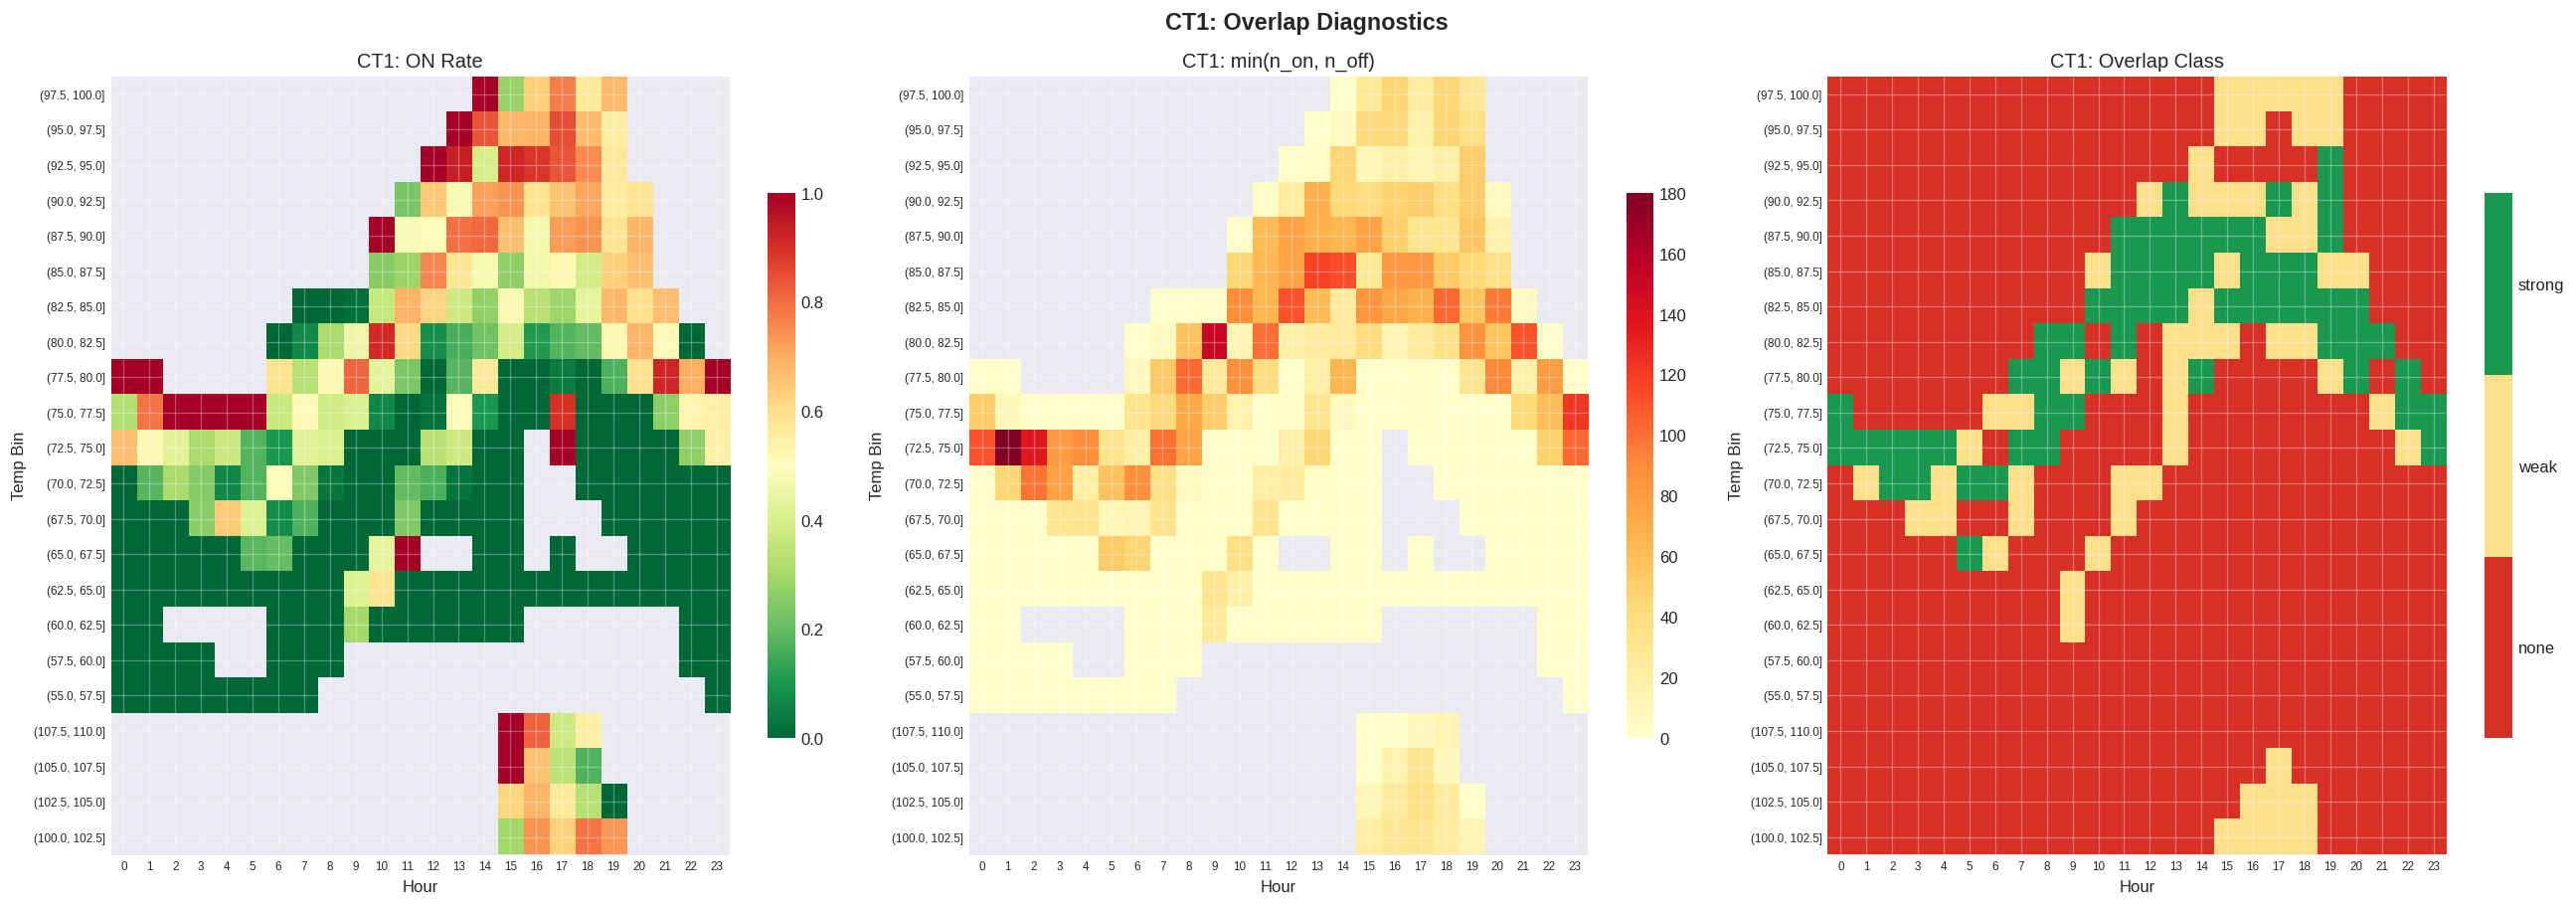

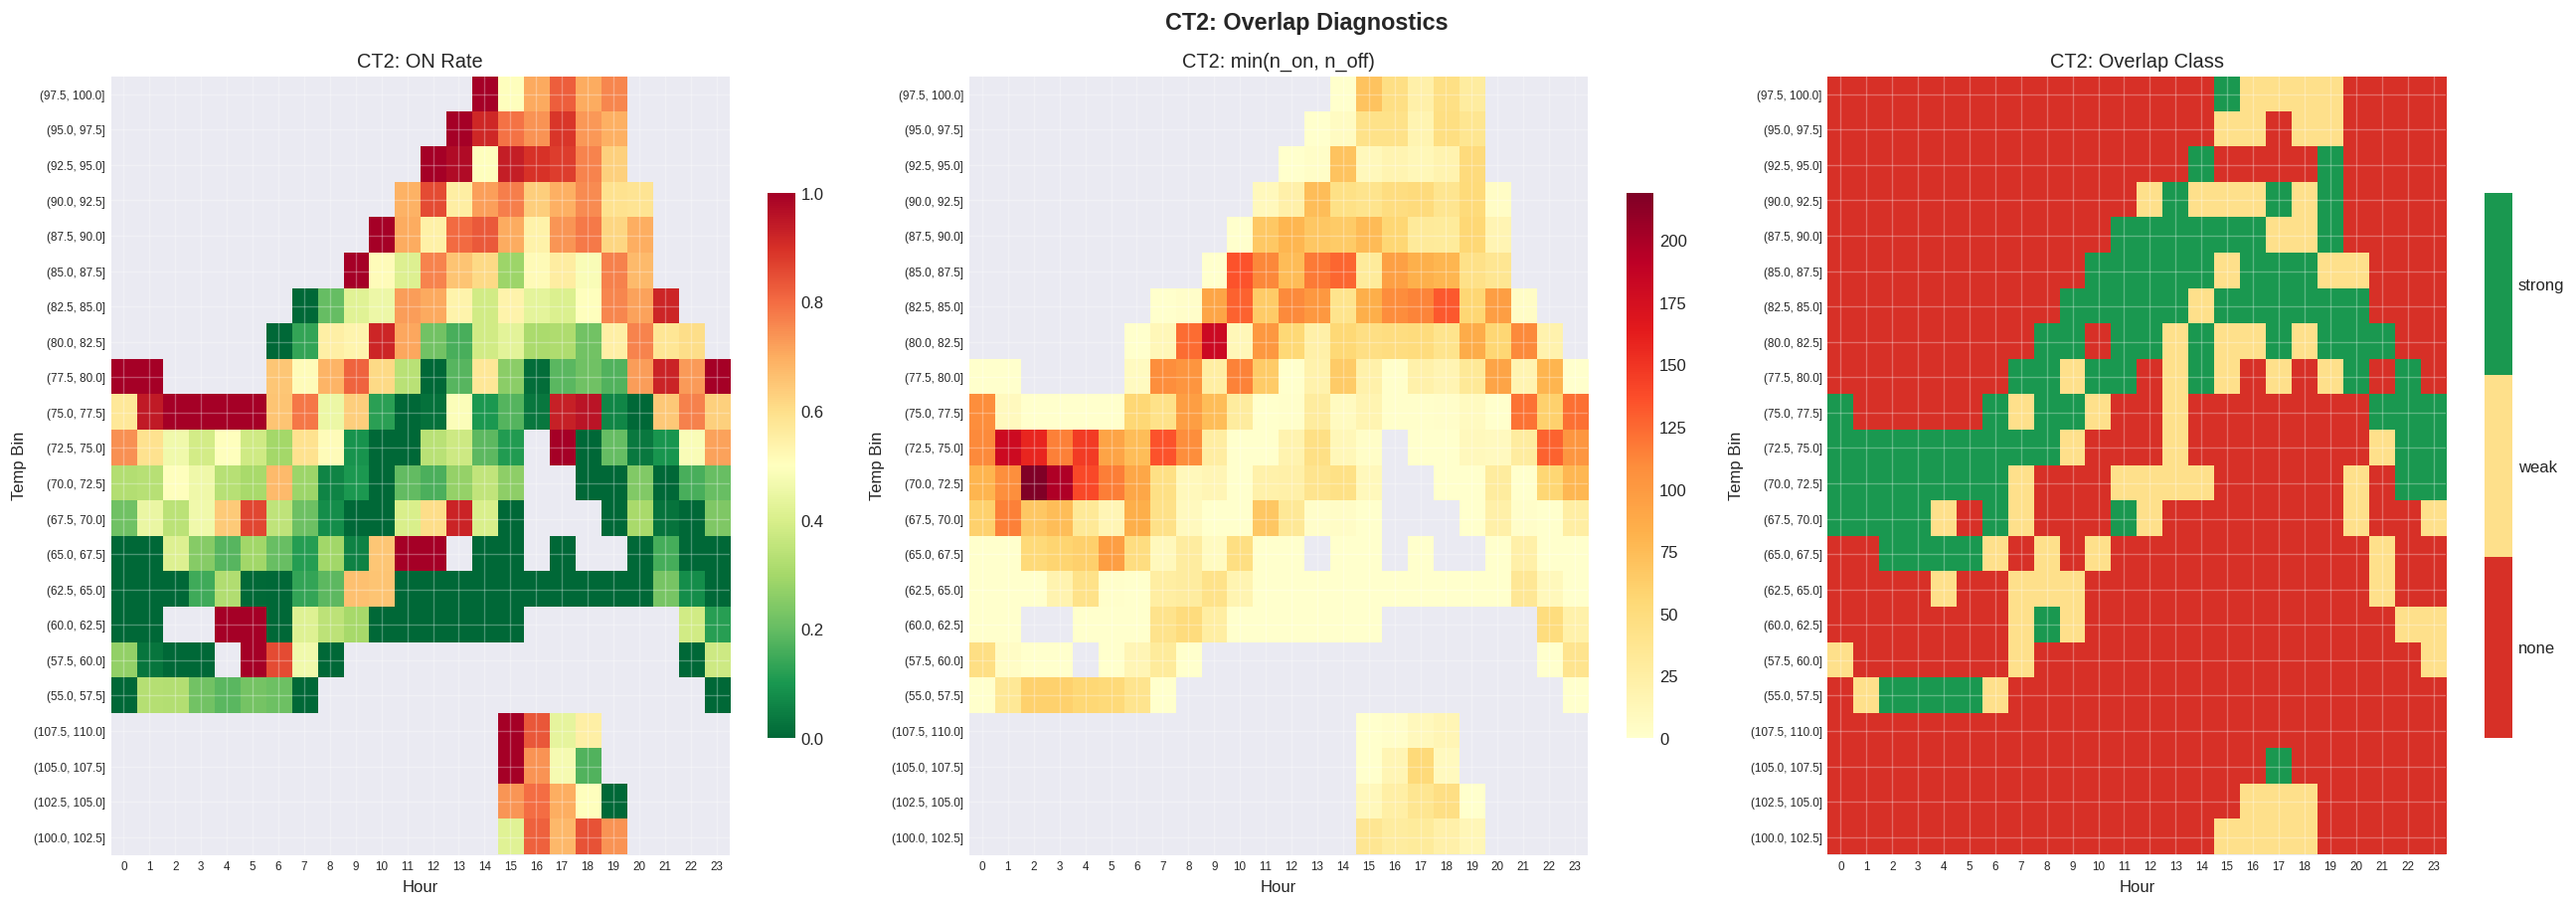


EFFECTS SUMMARY:
turbine outcome spec overlap  ATE_MW    ci_lo    ci_hi  uplift_85F  uplift_90F  uplift_95F     R2  N_train  N_report_strong  strong_frac  ATE_lb/h
    CT1   power    A  strong  1.0856   0.8560   1.1678      1.2009      1.3327      1.4236 0.9427    33417            12680       0.3794       NaN
    CT1    fuel    A  strong     NaN 276.6371 374.6789    377.8817    417.9352    446.5288 0.9330    33417            12680       0.3794  346.8738
    CT2   power    A  strong  1.2589   1.1906   1.3184      1.5541      1.7603      1.9180 0.9434    42046            23549       0.5601       NaN
    CT2    fuel    A  strong     NaN 380.8431 419.0938    490.7387    553.7788    602.6538 0.9322    42046            23549       0.5601  404.2592


In [ ]:
# ============================================================================
# SAVE OLS OUTPUTS (all outcomes)
# ============================================================================
effects_rows = []
for key, res in all_results.items():
    ct_label = res['ct_label']
    outcome_name = res['outcome_name']
    unit = 'MW' if outcome_name == 'power' else 'lb/h'

    effects_rows.append({
        'turbine': ct_label, 'outcome': outcome_name, 'spec': SPEC,
        'overlap': 'strong' if OVL_ON else 'off',
        f'ATE_{unit}': res['ate'], 'ci_lo': res['ci_lo'], 'ci_hi': res['ci_hi'],
        'uplift_85F': res['u85'], 'uplift_90F': res['u90'], 'uplift_95F': res['u95'],
        'R2': res['model'].rsquared,
        'N_train': len(res['df_train']),
        'N_report_strong': len(res['df_report_strong']),
        'strong_frac': res['ovl_meta']['strong_frac'] if res['ovl_meta'] else 1.0,
    })

    # Overlap grid/summary: only save once per turbine (avoid duplicating for fuel)
    if outcome_name == 'power' and res['ovl_meta']:
        m = res['ovl_meta']
        m['grid'].to_csv(f'{OUT}/overlap_grid_{ct_label}_{tag}.csv', index=False)
        m['summary'].to_csv(f'{OUT}/overlap_summary_{ct_label}_{tag}.csv', index=False)
        plot_overlap_heatmaps(m['grid'], ct_label, OUT)

    pd.DataFrame({f'boot_ate_{unit}': res['boot_arr']}).to_csv(
        f'{OUT}/bootstrap_ate_{ct_label}_{outcome_name}_{tag}.csv', index=False)

    if res['curve']:
        temps, pe, clo, chi = res['curve']
        pd.DataFrame({
            'temp_f': temps, f'uplift_{unit}': pe, 'ci_lo': clo, 'ci_hi': chi,
        }).to_csv(f'{OUT}/bootstrap_curve_{ct_label}_{outcome_name}_{tag}.csv', index=False)

effects_df = pd.DataFrame(effects_rows)
effects_df.to_csv(f'{OUT}/effects_summary_{tag}.csv', index=False)
print('\nEFFECTS SUMMARY:')
print(effects_df.to_string(index=False))

### OLS Uplift Curve Plots

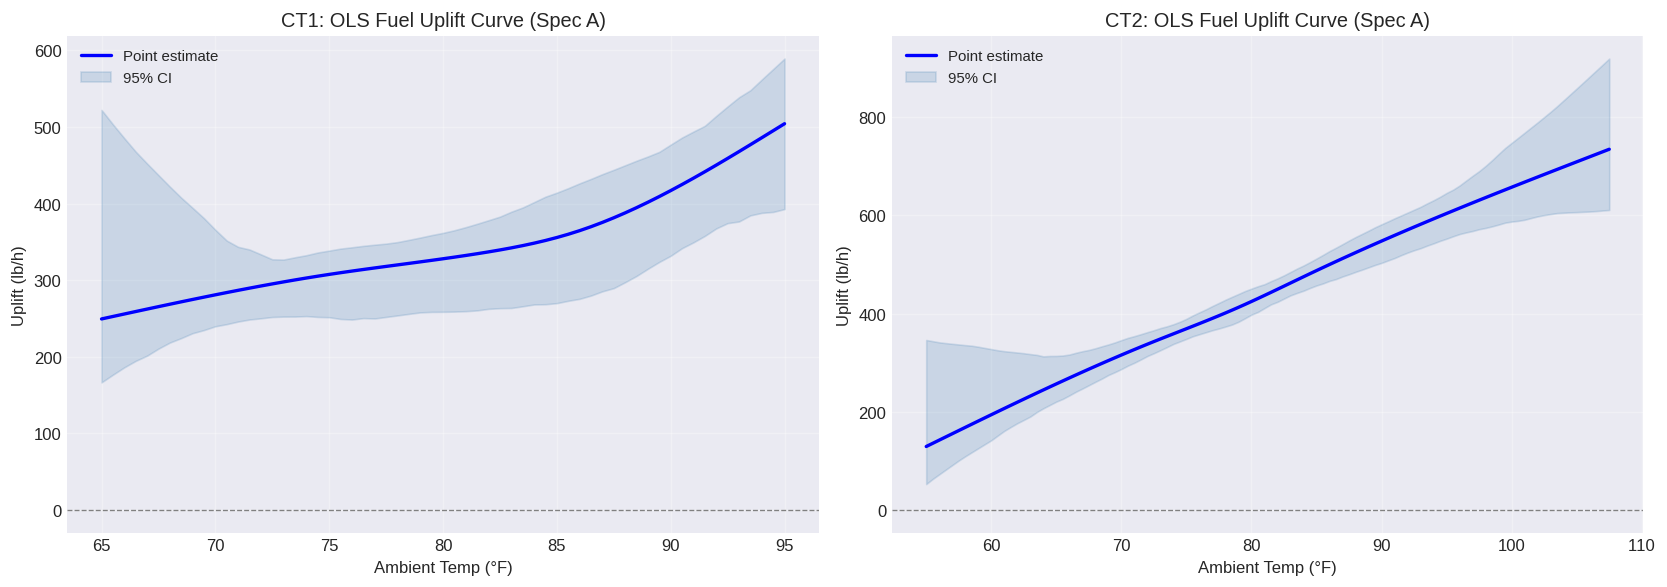

Saved: ./outputs/uplift_curve_fuel_specA_overlapON.png


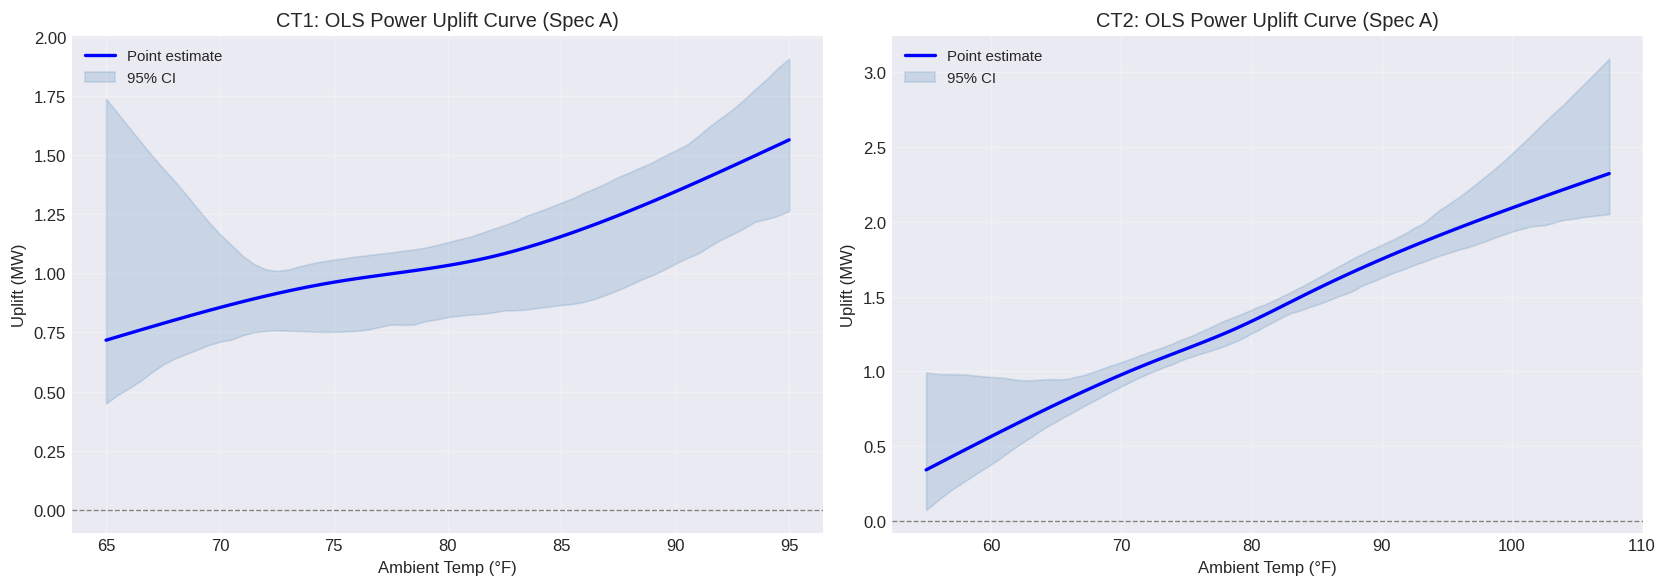

Saved: ./outputs/uplift_curve_power_specA_overlapON.png


In [ ]:
# ============================================================================
# OLS Uplift Curve Plots (all outcomes)
# ============================================================================
if len(all_results) > 0:
    # Group by outcome for separate figures
    outcome_names = sorted(set(r['outcome_name'] for r in all_results.values()))

    for outcome_name in outcome_names:
        # Gather results for this outcome
        ores = {k: v for k, v in all_results.items() if v['outcome_name'] == outcome_name}
        n_ct = len(ores)
        if n_ct == 0:
            continue

        unit = 'MW' if outcome_name == 'power' else 'lb/h'

        fig, axes = plt.subplots(1, n_ct, figsize=(7*n_ct, 5), squeeze=False)
        for i, (key, res) in enumerate(ores.items()):
            ax = axes[0, i]
            if res['curve']:
                temps, pe, clo, chi = res['curve']
                ax.plot(temps, pe, 'b-', lw=2, label='Point estimate')
                ax.fill_between(temps, clo, chi, alpha=0.2, color='steelblue',
                                label=f'{int(CONFIG["bootstrap"]["ci_level"]*100)}% CI')
            ax.axhline(0, color='grey', ls='--', lw=0.8)
            ax.set_xlabel('Ambient Temp (°F)')
            ax.set_ylabel(f'Uplift ({unit})')
            ax.set_title(f'{res["ct_label"]}: OLS {outcome_name.capitalize()} '
                         f'Uplift Curve (Spec {SPEC})')
            ax.legend(fontsize=9)

        plt.tight_layout()
        fname = f'uplift_curve_{outcome_name}_{tag}.png'
        fig.savefig(f'{OUT}/{fname}', dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved: {OUT}/{fname}')

### Section 2-4: OLS diagnostic


In [ ]:

# ============================================================================
# OLS DIAGNOSTICS (hold-out day split, factual prediction quality)
# ============================================================================

if CONFIG.get('diagnostics', {}).get('enabled', True):
    SPEC = CONFIG['model']['spec']
    test_frac = CONFIG.get('diagnostics', {}).get('test_days_frac', CONFIG['compare']['test_days_frac'])

    diag_rows = []
    for ct_prefix, ct_label, df_raw in [('ct1','CT1',df_ct1), ('ct2','CT2',df_ct2)]:
        df_prep = prepare_df(df_raw, ct_label, CONFIG['data']['train_temp_range_F'], CONFIG['treatment'])

        # Evaluate BOTH outcomes to keep OLS-vs-GBT symmetry
        for outcome_name, y_col in get_outcome_cols(ct_prefix).items():
            y_col, formula = build_formula(ct_prefix, SPEC, y_col=y_col)

            # Drop rows needed by the formula (conservative superset)
            needed = [y_col, 'D', 'ambient_air_temp_f', 'ambient_rh_pct',
                      f'{ct_prefix}_gas_supply_pressure_psi',
                      f'{ct_prefix}_inlet_air_supply_pressure_psig',
                      'hour', 'day', 'demand']
            if SPEC == 'B':
                needed += [f'{ct_prefix}_pcd', f'{ct_prefix}_t7_avg_temp']

            df_clean = df_prep.dropna(subset=[c for c in needed if c in df_prep.columns]).copy()
            if len(df_clean) < 500:
                diag_rows.append({
                    'turbine': ct_label, 'outcome': outcome_name, 'model': 'OLS', 'spec': SPEC,
                    'rmse': np.nan, 'mae': np.nan, 'r2': np.nan, 'n_test': 0, 'note': 'too few rows'
                })
                continue

            # Day-block split
            days = np.array(sorted(df_clean['day'].unique()))
            n_test = max(1, int(len(days) * test_frac))
            test_days = np.random.choice(days, size=n_test, replace=False)
            df_tr = df_clean[~df_clean['day'].isin(test_days)].copy()
            df_te = df_clean[ df_clean['day'].isin(test_days)].copy()

            try:
                m = smf.ols(formula, data=df_tr).fit()
                y_true = df_te[y_col].values
                y_hat  = m.predict(df_te).values

                rmse = float(np.sqrt(mean_squared_error(y_true, y_hat)))
                mae  = float(mean_absolute_error(y_true, y_hat))
                r2   = float(r2_score(y_true, y_hat))
                diag_rows.append({
                    'turbine': ct_label, 'outcome': outcome_name, 'model': 'OLS', 'spec': SPEC,
                    'rmse': rmse, 'mae': mae, 'r2': r2, 'n_test': len(df_te), 'note': ''
                })
            except Exception as e:
                diag_rows.append({
                    'turbine': ct_label, 'outcome': outcome_name, 'model': 'OLS', 'spec': SPEC,
                    'rmse': np.nan, 'mae': np.nan, 'r2': np.nan, 'n_test': len(df_te),
                    'note': f'fit/predict failed: {e}'
                })

    ols_diag_df = pd.DataFrame(diag_rows)
    display(ols_diag_df)
    ols_diag_df.to_csv(f'{OUT}/ols_diagnostics_spec{SPEC}.csv', index=False)
    print(f'Saved: {OUT}/ols_diagnostics_spec{SPEC}.csv')


  CT1: treatment 'full_vs_off' -> dropped 1,608 partial rows
  CT1: decontamination (+/-10min) -> dropped 305 rows
  CT1: temp [55-110F] -> 33,417 rows
  CT2: treatment 'full_vs_off' -> dropped 1,735 partial rows
  CT2: decontamination (+/-10min) -> dropped 328 rows
  CT2: temp [55-110F] -> 42,046 rows


,turbine,outcome,model,spec,rmse,mae,r2,n_test,note
0,CT1,power,OLS,A,0.1729,0.1105,0.9122,5953,
1,CT1,fuel,OLS,A,69.6284,40.9938,0.9156,5227,
2,CT2,power,OLS,A,0.1296,0.0975,0.9646,8216,
3,CT2,fuel,OLS,A,56.5356,43.9762,0.9255,7643,


Saved: ./outputs/ols_diagnostics_specA.csv


  CT1: treatment 'full_vs_off' -> dropped 1,608 partial rows
  CT1: decontamination (+/-10min) -> dropped 305 rows
  CT1: temp [55-110F] -> 33,417 rows
  CT1/power OLS SpecA: RMSE=0.1587±0.0298  MAE=0.1013±0.0124  R²=0.9123±0.0378  (30/30 valid rounds)


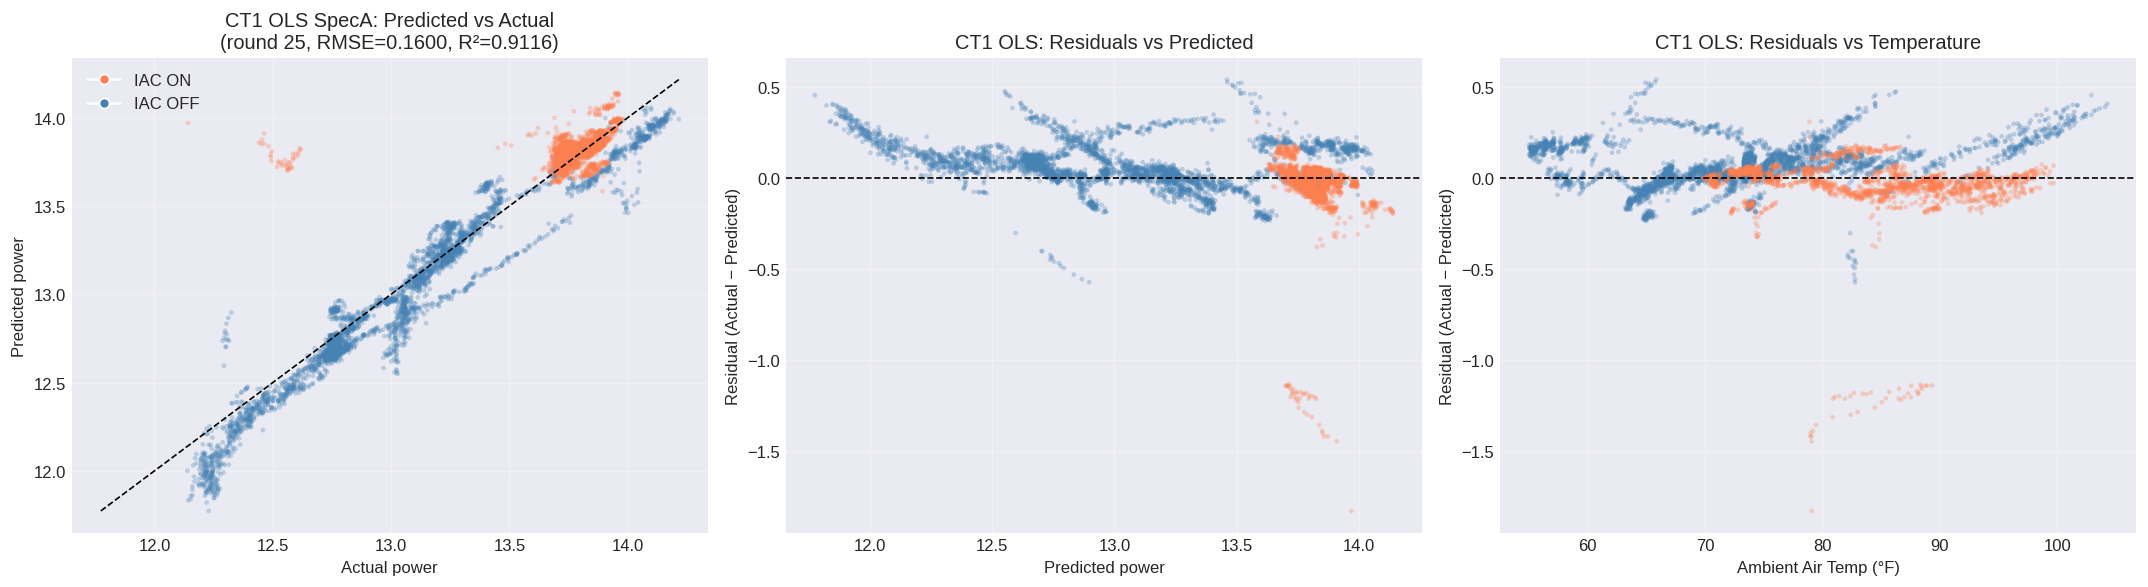

  Saved: ./outputs/ols_diag_plots_CT1_power_specA.png  (median-RMSE round=25)
  CT1/fuel OLS SpecA: RMSE=56.7520±9.3556  MAE=39.4353±5.2466  R²=0.8968±0.0388  (30/30 valid rounds)


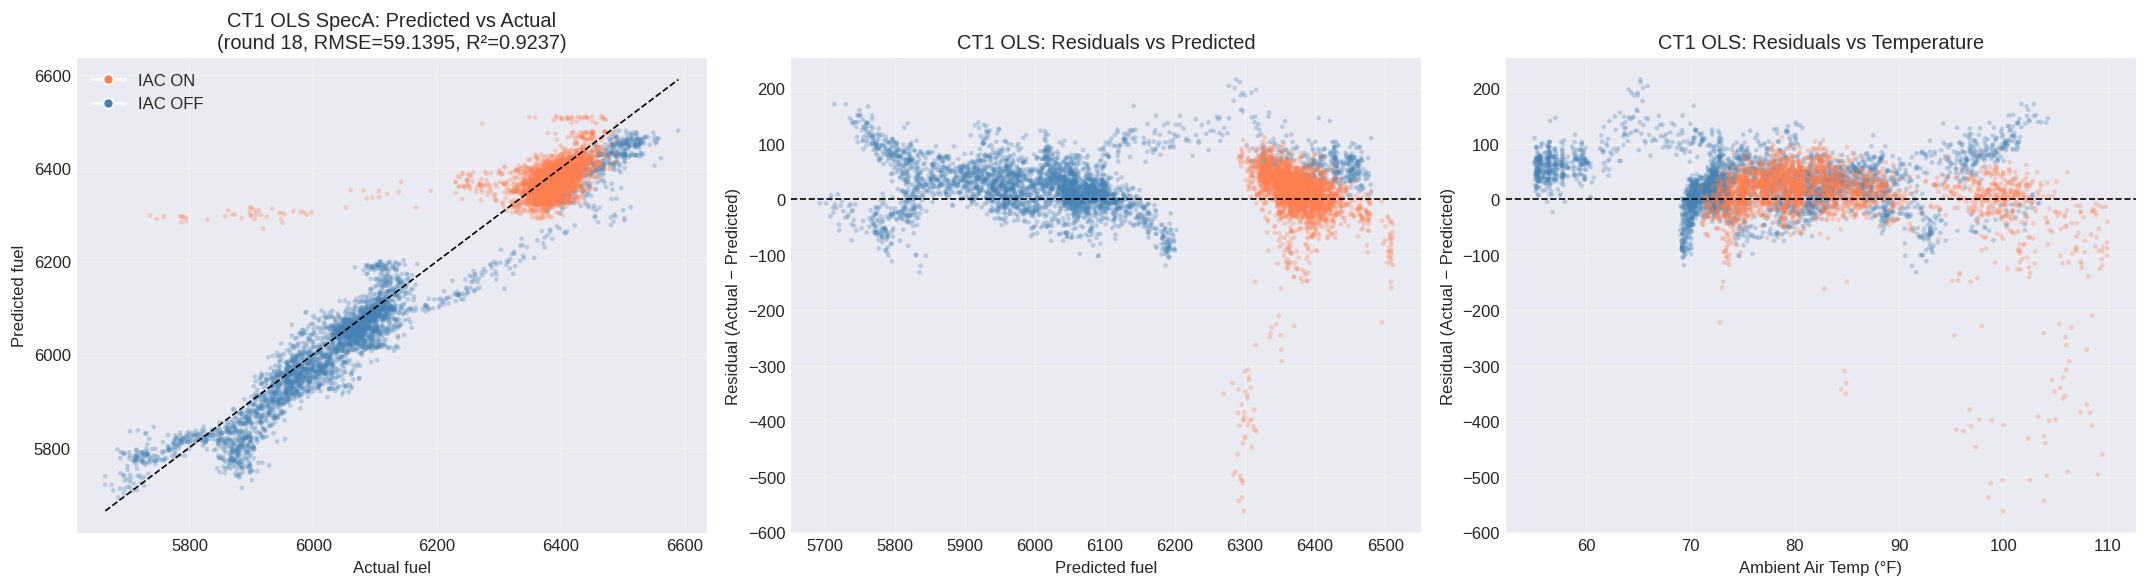

  Saved: ./outputs/ols_diag_plots_CT1_fuel_specA.png  (median-RMSE round=18)
  CT2: treatment 'full_vs_off' -> dropped 1,735 partial rows
  CT2: decontamination (+/-10min) -> dropped 328 rows
  CT2: temp [55-110F] -> 42,046 rows
  CT2/power OLS SpecA: RMSE=0.1868±0.0295  MAE=0.1405±0.0217  R²=0.8933±0.0480  (30/30 valid rounds)


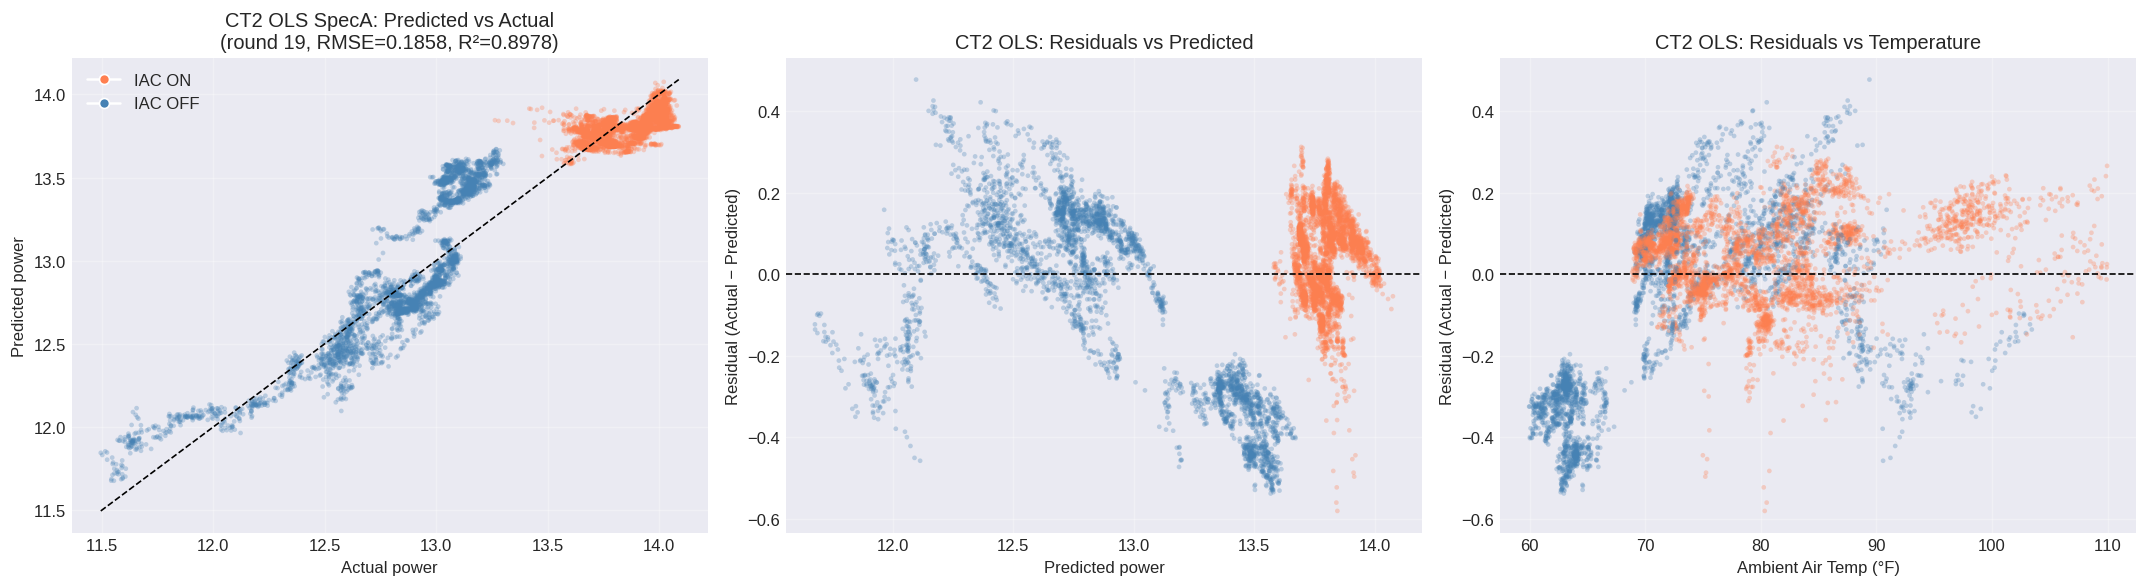

  Saved: ./outputs/ols_diag_plots_CT2_power_specA.png  (median-RMSE round=19)
  CT2/fuel OLS SpecA: RMSE=63.0215±8.3607  MAE=48.8538±6.3146  R²=0.8859±0.0405  (30/30 valid rounds)


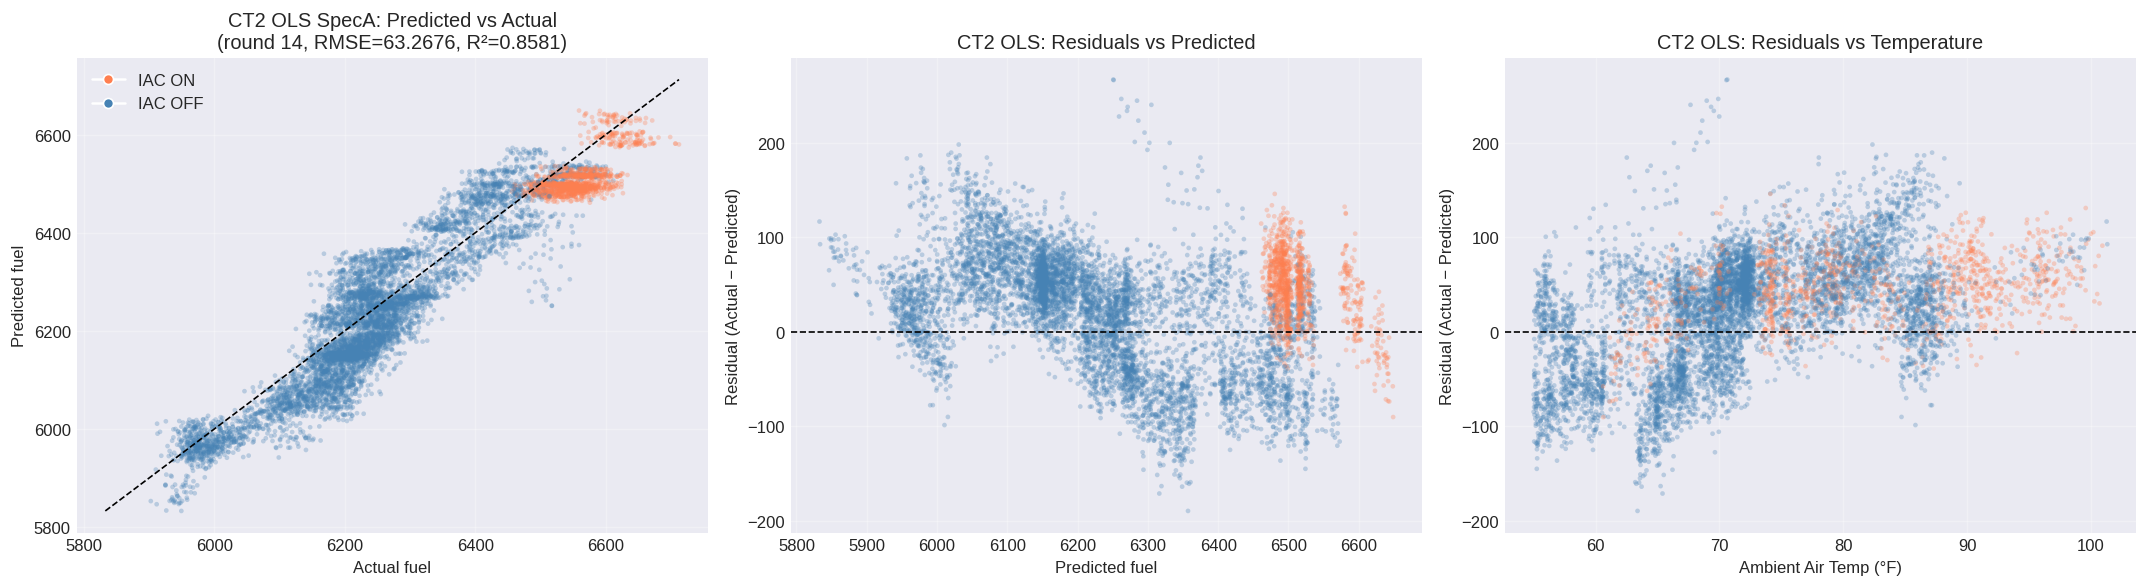

  Saved: ./outputs/ols_diag_plots_CT2_fuel_specA.png  (median-RMSE round=14)


,turbine,outcome,model,spec,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std,n_test_mean,n_repeats_valid,note
0,CT1,power,OLS,A,0.1587,0.0298,0.1013,0.0124,0.9123,0.0378,6128.5667,30,
1,CT1,fuel,OLS,A,56.7520,9.3556,39.4353,5.2466,0.8968,0.0388,6128.5667,30,
2,CT2,power,OLS,A,0.1868,0.0295,0.1405,0.0217,0.8933,0.0480,8082.5333,30,
3,CT2,fuel,OLS,A,63.0215,8.3607,48.8538,6.3146,0.8859,0.0405,8082.5333,30,


Saved: ./outputs/ols_diagnostics_specA.csv


In [ ]:
# ============================================================================
# OLS DIAGNOSTICS (Monte Carlo Cross-Validation, day-block split)
# ============================================================================

if CONFIG.get('diagnostics', {}).get('enabled', True):
    SPEC = CONFIG['model']['spec']
    test_frac = CONFIG.get('diagnostics', {}).get('test_days_frac', CONFIG['compare']['test_days_frac'])
    n_repeats = CONFIG.get('diagnostics', {}).get('mccv_repeats', 30)

    diag_rows = []
    for ct_prefix, ct_label, df_raw in [('ct1','CT1',df_ct1), ('ct2','CT2',df_ct2)]:
        df_prep = prepare_df(df_raw, ct_label, CONFIG['data']['train_temp_range_F'], CONFIG['treatment'])

        for outcome_name, y_col in get_outcome_cols(ct_prefix).items():
            y_col, formula = build_formula(ct_prefix, SPEC, y_col=y_col)

            needed = [y_col, 'D', 'ambient_air_temp_f', 'ambient_rh_pct',
                      f'{ct_prefix}_gas_supply_pressure_psi',
                      f'{ct_prefix}_inlet_air_supply_pressure_psig',
                      'hour', 'day', 'demand']
            if SPEC == 'B':
                needed += [f'{ct_prefix}_pcd', f'{ct_prefix}_t7_avg_temp']

            df_clean = df_prep.dropna(subset=[c for c in needed if c in df_prep.columns]).copy()
            if len(df_clean) < 500:
                diag_rows.append({
                    'turbine': ct_label, 'outcome': outcome_name, 'model': 'OLS', 'spec': SPEC,
                    'rmse_mean': np.nan, 'rmse_std': np.nan,
                    'mae_mean': np.nan, 'mae_std': np.nan,
                    'r2_mean': np.nan, 'r2_std': np.nan,
                    'n_test_mean': 0, 'n_repeats_valid': 0,
                    'note': 'too few rows'
                })
                continue

            days = np.array(sorted(df_clean['day'].unique()))
            n_test = max(1, int(len(days) * test_frac))

            round_metrics = []
            for r in range(n_repeats):
                rng = np.random.RandomState(CONFIG['seed'] + r)
                test_days = rng.choice(days, size=n_test, replace=False)
                df_tr = df_clean[~df_clean['day'].isin(test_days)].copy()
                df_te = df_clean[ df_clean['day'].isin(test_days)].copy()

                if len(df_te) < 50 or df_tr['D'].nunique() < 2:
                    continue
                try:
                    m = smf.ols(formula, data=df_tr).fit()
                    y_true = df_te[y_col].values
                    y_hat  = m.predict(df_te).values
                    round_metrics.append({
                        'rmse': float(np.sqrt(mean_squared_error(y_true, y_hat))),
                        'mae':  float(mean_absolute_error(y_true, y_hat)),
                        'r2':   float(r2_score(y_true, y_hat)),
                        'n_te': len(df_te),
                        '_y_true': y_true.copy(),
                        '_y_hat':  y_hat.copy(),
                        '_temp':   df_te['ambient_air_temp_f'].values.copy(),
                        '_D':      df_te['D'].values.copy(),
                    })
                except:
                    continue

            if len(round_metrics) > 0:
                mdf = pd.DataFrame(round_metrics)
                diag_rows.append({
                    'turbine': ct_label, 'outcome': outcome_name, 'model': 'OLS', 'spec': SPEC,
                    'rmse_mean': float(mdf['rmse'].mean()), 'rmse_std': float(mdf['rmse'].std()),
                    'mae_mean':  float(mdf['mae'].mean()),  'mae_std':  float(mdf['mae'].std()),
                    'r2_mean':   float(mdf['r2'].mean()),   'r2_std':   float(mdf['r2'].std()),
                    'n_test_mean': float(mdf['n_te'].mean()),
                    'n_repeats_valid': len(round_metrics),
                    'note': ''
                })
                print(f'  {ct_label}/{outcome_name} OLS Spec{SPEC}: '
                      f'RMSE={mdf["rmse"].mean():.4f}±{mdf["rmse"].std():.4f}  '
                      f'MAE={mdf["mae"].mean():.4f}±{mdf["mae"].std():.4f}  '
                      f'R²={mdf["r2"].mean():.4f}±{mdf["r2"].std():.4f}  '
                      f'({len(round_metrics)}/{n_repeats} valid rounds)')

                # --- Pick the median-RMSE round for diagnostic plots ---
                mdf = pd.DataFrame(round_metrics)
                median_rmse = mdf['rmse'].median()
                best_idx = (mdf['rmse'] - median_rmse).abs().idxmin()
                rep = round_metrics[best_idx]

                y_true_plot = rep['_y_true']
                y_hat_plot  = rep['_y_hat']
                temp_plot   = rep['_temp']
                D_plot      = rep['_D']
                resid       = y_true_plot - y_hat_plot

                fig, axes = plt.subplots(1, 3, figsize=(18, 5))

                # (1) Predicted vs Actual
                ax = axes[0]
                colors = np.where(D_plot == 1, 'coral', 'steelblue')
                ax.scatter(y_true_plot, y_hat_plot, c=colors, alpha=0.3, s=8, edgecolors='none')
                lo = min(y_true_plot.min(), y_hat_plot.min())
                hi = max(y_true_plot.max(), y_hat_plot.max())
                ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
                ax.set_xlabel(f'Actual {outcome_name}')
                ax.set_ylabel(f'Predicted {outcome_name}')
                ax.set_title(f'{ct_label} OLS Spec{SPEC}: Predicted vs Actual\n'
                             f'(round {best_idx}, RMSE={rep["rmse"]:.4f}, R²={rep["r2"]:.4f})')
                ax.legend(handles=[
                    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='coral', label='IAC ON'),
                    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', label='IAC OFF'),
                ], loc='upper left')

                # (2) Residuals vs Predicted
                ax = axes[1]
                ax.scatter(y_hat_plot, resid, c=colors, alpha=0.3, s=8, edgecolors='none')
                ax.axhline(0, color='k', ls='--', lw=1)
                ax.set_xlabel(f'Predicted {outcome_name}')
                ax.set_ylabel('Residual (Actual − Predicted)')
                ax.set_title(f'{ct_label} OLS: Residuals vs Predicted')

                # (3) Residuals vs Temperature
                ax = axes[2]
                ax.scatter(temp_plot, resid, c=colors, alpha=0.3, s=8, edgecolors='none')
                ax.axhline(0, color='k', ls='--', lw=1)
                ax.set_xlabel('Ambient Air Temp (°F)')
                ax.set_ylabel('Residual (Actual − Predicted)')
                ax.set_title(f'{ct_label} OLS: Residuals vs Temperature')

                plt.tight_layout()
                fname = f'ols_diag_plots_{ct_label}_{outcome_name}_spec{SPEC}.png'
                fig.savefig(f'{OUT}/{fname}', dpi=150, bbox_inches='tight')
                plt.show()
                print(f'  Saved: {OUT}/{fname}  (median-RMSE round={best_idx})')
            else:
                diag_rows.append({
                    'turbine': ct_label, 'outcome': outcome_name, 'model': 'OLS', 'spec': SPEC,
                    'rmse_mean': np.nan, 'rmse_std': np.nan,
                    'mae_mean': np.nan, 'mae_std': np.nan,
                    'r2_mean': np.nan, 'r2_std': np.nan,
                    'n_test_mean': 0, 'n_repeats_valid': 0,
                    'note': 'all rounds failed'
                })

    ols_diag_df = pd.DataFrame(diag_rows)
    display(ols_diag_df)
    ols_diag_df.to_csv(f'{OUT}/ols_diagnostics_spec{SPEC}.csv', index=False)
    print(f'Saved: {OUT}/ols_diagnostics_spec{SPEC}.csv')

### Residual Diagnosis — Large |residual| > 1 MW
Fit full-sample OLS, extract observations where |predicted − actual| > 1 MW, and analyze their `hour`, `demand`, `day`, `D`, and temperature profiles to diagnose the upper-left orange cluster in Pred-vs-Actual.

  CT1: treatment 'full_vs_off' -> dropped 1,608 partial rows
  CT1: decontamination (+/-10min) -> dropped 305 rows
  CT1: temp [55-110F] -> 33,417 rows

CT1 — Residual Diagnosis (threshold = ±1.0 MW)
  Total observations:  33,417
  |resid| > 1.0 MW:     116 (0.3%)
    Over-predicted (pred >> actual):  116  (0.3%)
    Under-predicted (pred << actual): 0  (0.0%)

  --- OVER-PREDICTED (pred >> actual by >1.0 MW) ---
  IAC distribution:
    D=1: 116 (100.0%)

  Hour distribution (top 10):
    Hour  8:   21  ████████████████
    Hour  9:   16  ████████████
    Hour 12:   14  ██████████
    Hour 17:   18  █████████████
    Hour 19:   39  ██████████████████████████████
    Hour 20:    8  ██████

  Temperature stats:
    Mean: 85.6°F   Median: 82.8°F   Range: [78.0, 109.5]°F

  Demand stats:
    Mean: 21.7   Median: 22.8   Range: [18.7, 25.0]

  Demand comparison:
    Over-predicted mean demand: 21.7
    Normal mean demand:         22.4
    Difference:                 -0.6

  Day distribution 

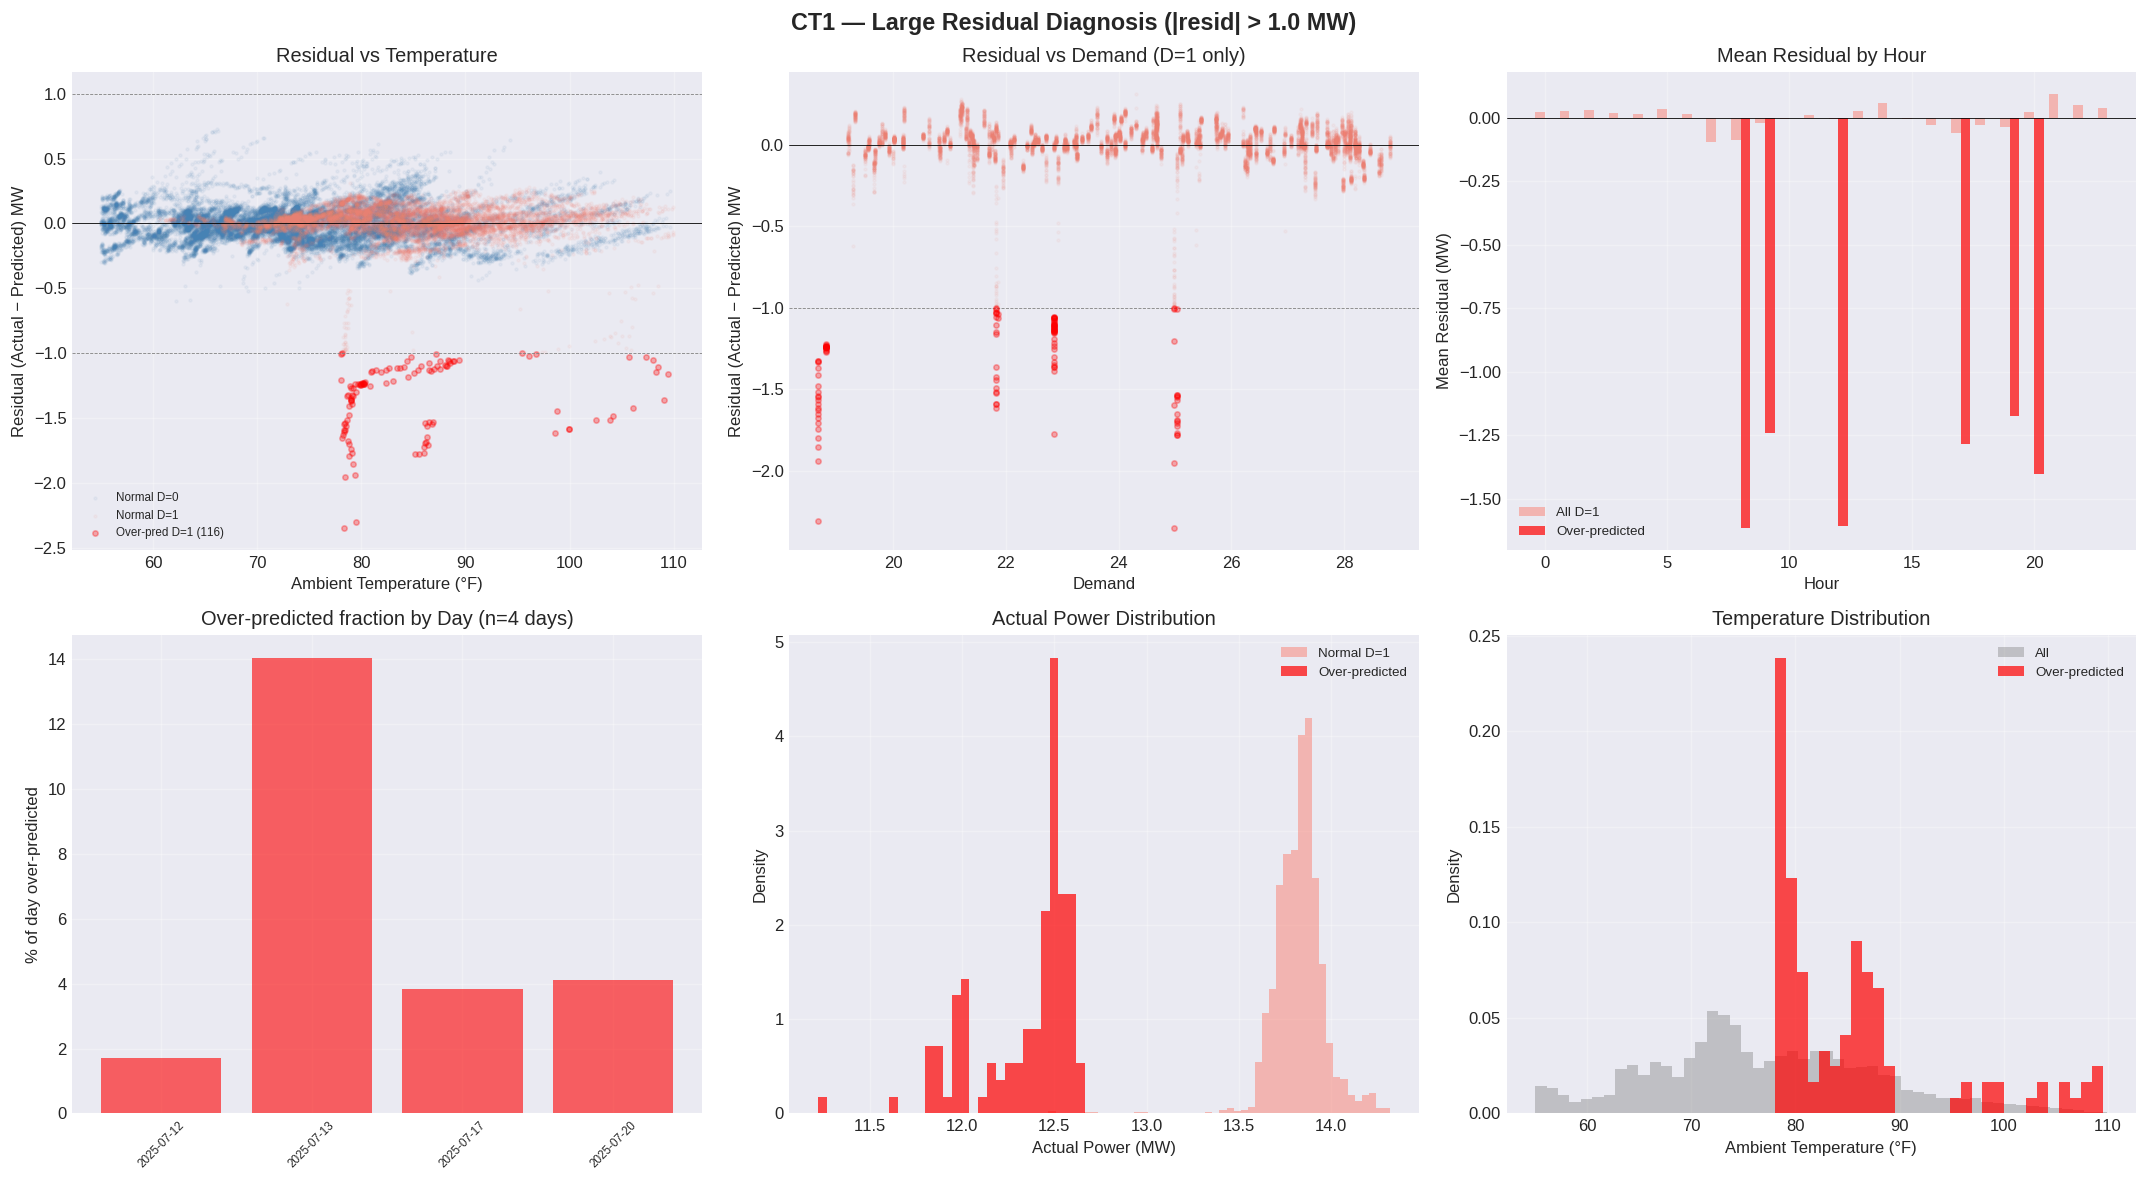


  Saved: ./outputs/resid_diagnosis_CT1_power.png
  CT2: treatment 'full_vs_off' -> dropped 1,735 partial rows
  CT2: decontamination (+/-10min) -> dropped 328 rows
  CT2: temp [55-110F] -> 42,046 rows

CT2 — Residual Diagnosis (threshold = ±1.0 MW)
  Total observations:  42,046
  |resid| > 1.0 MW:     53 (0.1%)
    Over-predicted (pred >> actual):  53  (0.1%)
    Under-predicted (pred << actual): 0  (0.0%)

  --- OVER-PREDICTED (pred >> actual by >1.0 MW) ---
  IAC distribution:
    D=1: 53 (100.0%)

  Hour distribution (top 10):
    Hour 17:    1  
    Hour 18:   52  ██████████████████████████████

  Temperature stats:
    Mean: 84.0°F   Median: 82.7°F   Range: [81.9, 91.0]°F

  Demand stats:
    Mean: 24.7   Median: 24.7   Range: [24.7, 25.7]

  Demand comparison:
    Over-predicted mean demand: 24.7
    Normal mean demand:         22.3
    Difference:                 +2.4

  Day distribution (top 10):
    2025-07-10:   53 obs  (4% of that day's data)

  Actual power stats:
    Over

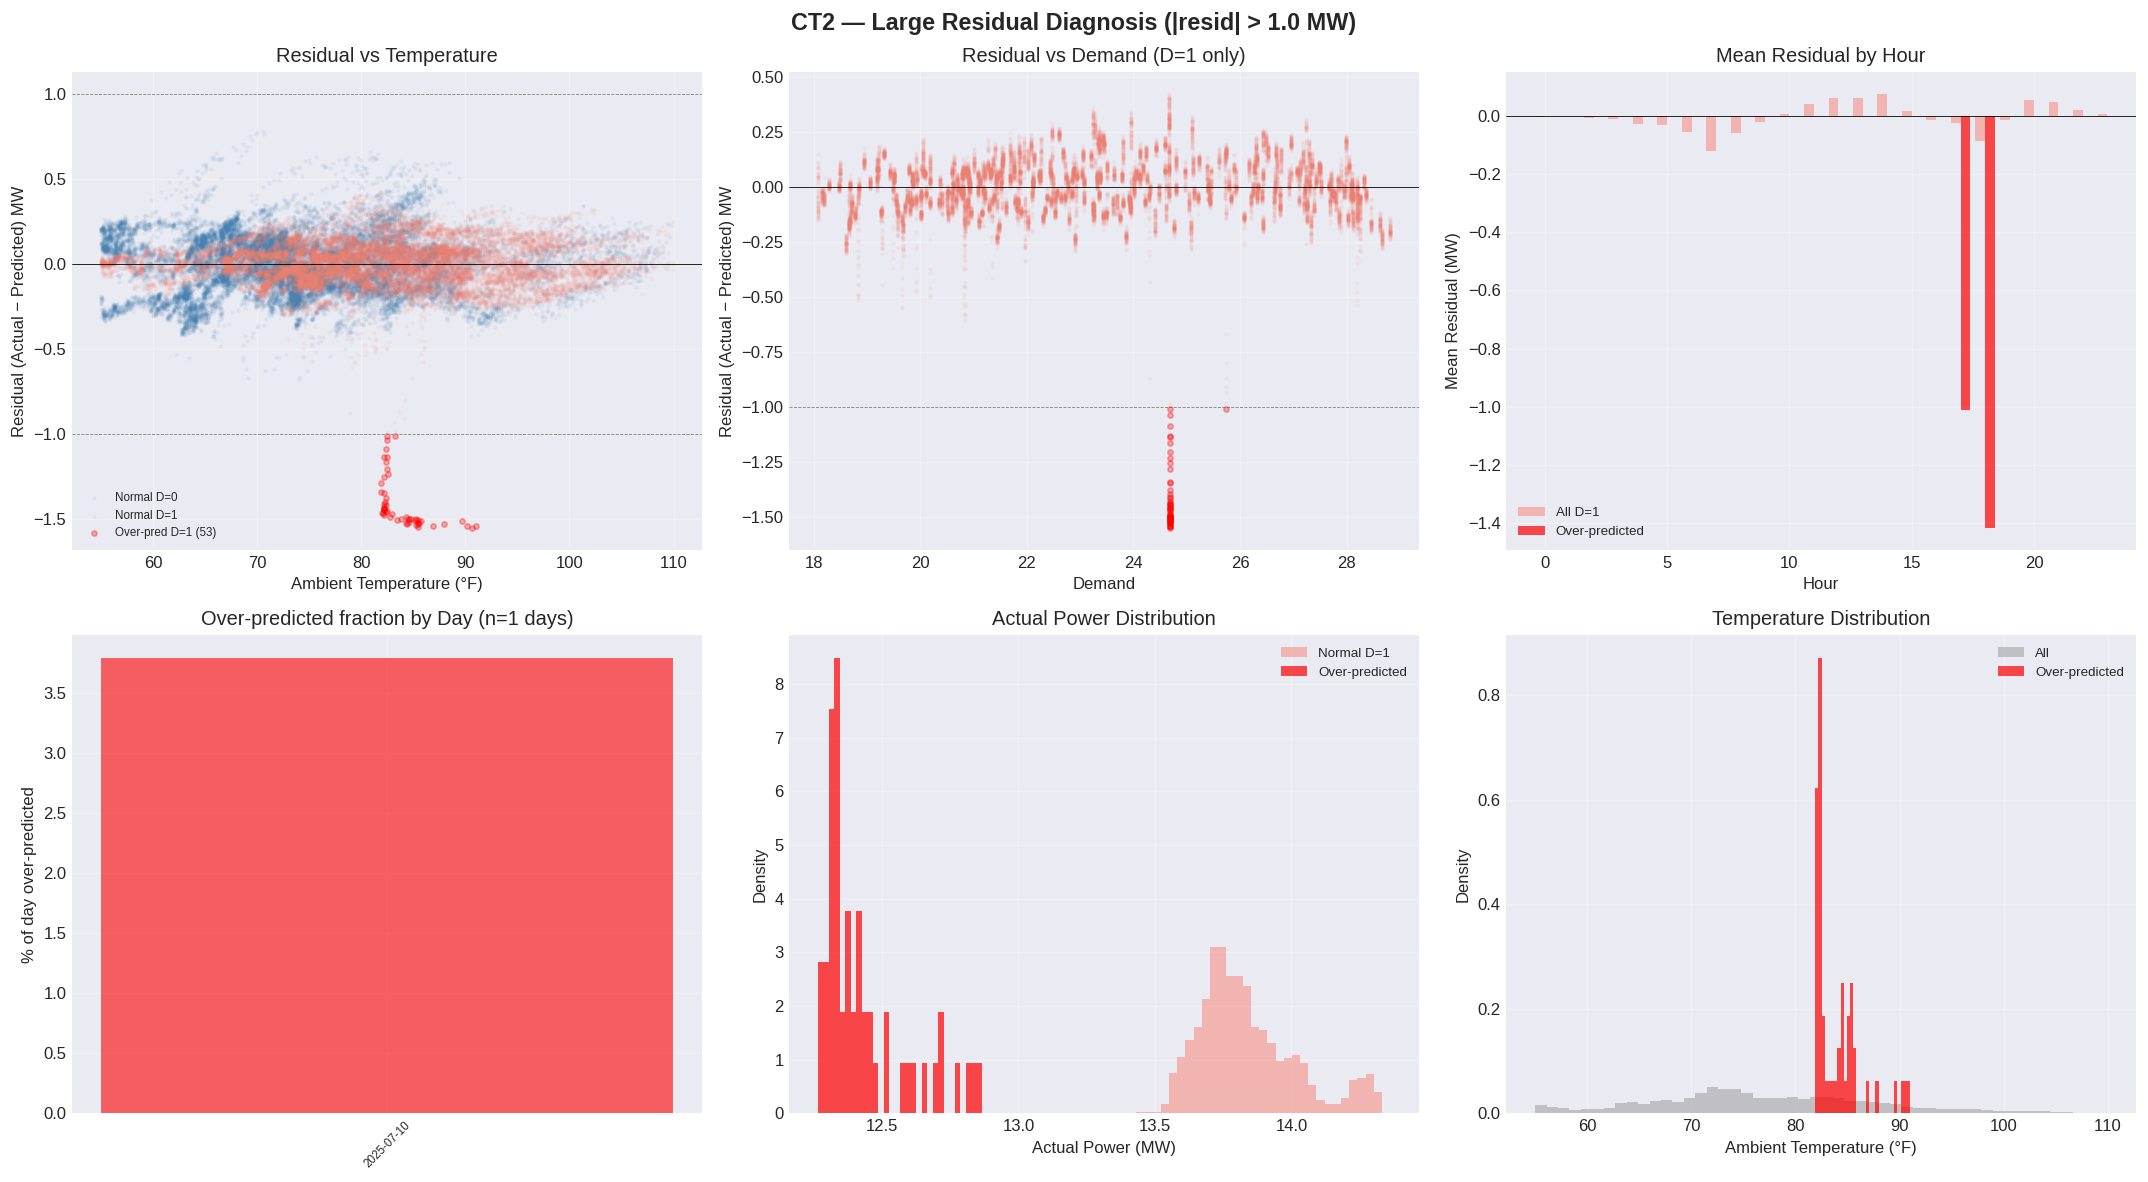


  Saved: ./outputs/resid_diagnosis_CT2_power.png


In [ ]:
from patsy import cr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ============================================================================
# RESIDUAL DIAGNOSIS: |residual| > 1 MW
# ============================================================================

RESID_THRESH = 1.0   # MW
SPEC = CONFIG['model']['spec']

for ct_prefix, ct_label, df_raw in [('ct1','CT1',df_ct1), ('ct2','CT2',df_ct2)]:
    df_prep = prepare_df(df_raw, ct_label,
                         CONFIG['data']['train_temp_range_F'], CONFIG['treatment'])

    y_col, formula = build_formula(ct_prefix, SPEC)
    needed = [y_col, 'D', 'ambient_air_temp_f', 'ambient_rh_pct',
              f'{ct_prefix}_gas_supply_pressure_psi',
              f'{ct_prefix}_inlet_air_supply_pressure_psig',
              'hour', 'day', 'demand']
    df_clean = df_prep.dropna(subset=[c for c in needed if c in df_prep.columns]).copy()

    # Fit on full sample
    m = smf.ols(formula, data=df_clean).fit()
    df_clean['y_hat'] = m.predict(df_clean)
    df_clean['resid'] = df_clean[y_col] - df_clean['y_hat']   # actual - predicted
    df_clean['abs_resid'] = df_clean['resid'].abs()

    # Split by residual direction
    over  = df_clean[df_clean['resid'] < -RESID_THRESH].copy()  # predicted >> actual (left-upper cluster)
    under = df_clean[df_clean['resid'] >  RESID_THRESH].copy()  # predicted << actual

    n_total = len(df_clean)
    print(f'\n{"="*72}')
    print(f'{ct_label} — Residual Diagnosis (threshold = ±{RESID_THRESH} MW)')
    print(f'{"="*72}')
    print(f'  Total observations:  {n_total:,}')
    print(f'  |resid| > {RESID_THRESH} MW:     {len(over)+len(under):,} ({(len(over)+len(under))/n_total*100:.1f}%)')
    print(f'    Over-predicted (pred >> actual):  {len(over):,}  ({len(over)/n_total*100:.1f}%)')
    print(f'    Under-predicted (pred << actual): {len(under):,}  ({len(under)/n_total*100:.1f}%)')

    # ---- OVER-PREDICTED (the orange upper-left cluster) ----
    if len(over) > 10:
        print(f'\n  --- OVER-PREDICTED (pred >> actual by >{RESID_THRESH} MW) ---')
        print(f'  IAC distribution:')
        d_counts = over['D'].value_counts().sort_index()
        for d_val, cnt in d_counts.items():
            pct = cnt / len(over) * 100
            print(f'    D={int(d_val)}: {cnt:,} ({pct:.1f}%)')

        print(f'\n  Hour distribution (top 10):')
        hr = over['hour'].value_counts().sort_index()
        for h, cnt in hr.head(24).items():
            bar = '█' * int(cnt / max(hr) * 30)
            print(f'    Hour {int(h):2d}: {cnt:4d}  {bar}')

        print(f'\n  Temperature stats:')
        print(f'    Mean: {over["ambient_air_temp_f"].mean():.1f}°F   '
              f'Median: {over["ambient_air_temp_f"].median():.1f}°F   '
              f'Range: [{over["ambient_air_temp_f"].min():.1f}, {over["ambient_air_temp_f"].max():.1f}]°F')

        print(f'\n  Demand stats:')
        print(f'    Mean: {over["demand"].mean():.1f}   '
              f'Median: {over["demand"].median():.1f}   '
              f'Range: [{over["demand"].min():.1f}, {over["demand"].max():.1f}]')

        # Compare demand: outliers vs normal
        normal = df_clean[df_clean['abs_resid'] <= RESID_THRESH]
        print(f'\n  Demand comparison:')
        print(f'    Over-predicted mean demand: {over["demand"].mean():.1f}')
        print(f'    Normal mean demand:         {normal["demand"].mean():.1f}')
        print(f'    Difference:                 {over["demand"].mean() - normal["demand"].mean():+.1f}')

        print(f'\n  Day distribution (top 10):')
        day_counts = over['day'].value_counts().head(10)
        for d, cnt in day_counts.items():
            pct_of_day = cnt / len(df_clean[df_clean['day'] == d]) * 100
            print(f'    {d}: {cnt:4d} obs  ({pct_of_day:.0f}% of that day\'s data)')

        print(f'\n  Actual power stats:')
        print(f'    Over-predicted: mean={over[y_col].mean():.2f} MW  '
              f'range=[{over[y_col].min():.2f}, {over[y_col].max():.2f}]')
        print(f'    Normal D=1:     mean={normal[normal["D"]==1][y_col].mean():.2f} MW  '
              f'range=[{normal[normal["D"]==1][y_col].min():.2f}, {normal[normal["D"]==1][y_col].max():.2f}]')

    # ---- UNDER-PREDICTED ----
    if len(under) > 10:
        print(f'\n  --- UNDER-PREDICTED (pred << actual by >{RESID_THRESH} MW) ---')
        d_counts = under['D'].value_counts().sort_index()
        for d_val, cnt in d_counts.items():
            pct = cnt / len(under) * 100
            print(f'    D={int(d_val)}: {cnt:,} ({pct:.1f}%)')
        print(f'    Mean temp: {under["ambient_air_temp_f"].mean():.1f}°F   '
              f'Mean demand: {under["demand"].mean():.1f}')

    # ---- PLOTS ----
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'{ct_label} — Large Residual Diagnosis (|resid| > {RESID_THRESH} MW)', fontsize=14, fontweight='bold')

    # 1. Residual vs Temperature, colored by D
    ax = axes[0, 0]
    norm_d0 = df_clean[(df_clean['abs_resid'] <= RESID_THRESH) & (df_clean['D'] == 0)]
    norm_d1 = df_clean[(df_clean['abs_resid'] <= RESID_THRESH) & (df_clean['D'] == 1)]
    ax.scatter(norm_d0['ambient_air_temp_f'], norm_d0['resid'], c='steelblue', alpha=0.05, s=3, label='Normal D=0')
    ax.scatter(norm_d1['ambient_air_temp_f'], norm_d1['resid'], c='salmon', alpha=0.05, s=3, label='Normal D=1')
    if len(over) > 0:
        over_d0 = over[over['D'] == 0]
        over_d1 = over[over['D'] == 1]
        if len(over_d0) > 0: ax.scatter(over_d0['ambient_air_temp_f'], over_d0['resid'], c='blue', alpha=0.3, s=10, label=f'Over-pred D=0 ({len(over_d0)})')
        if len(over_d1) > 0: ax.scatter(over_d1['ambient_air_temp_f'], over_d1['resid'], c='red', alpha=0.3, s=10, label=f'Over-pred D=1 ({len(over_d1)})')
    ax.axhline(0, color='black', lw=0.5)
    ax.axhline(-RESID_THRESH, color='gray', ls='--', lw=0.5)
    ax.axhline(RESID_THRESH, color='gray', ls='--', lw=0.5)
    ax.set_xlabel('Ambient Temperature (°F)')
    ax.set_ylabel('Residual (Actual − Predicted) MW')
    ax.set_title('Residual vs Temperature')
    ax.legend(fontsize=7, loc='lower left')

    # 2. Residual vs Demand
    ax = axes[0, 1]
    ax.scatter(norm_d1['demand'], norm_d1['resid'], c='salmon', alpha=0.05, s=3)
    if len(over) > 0:
        ax.scatter(over['demand'], over['resid'], c='red', alpha=0.3, s=10, zorder=5)
    ax.axhline(0, color='black', lw=0.5)
    ax.axhline(-RESID_THRESH, color='gray', ls='--', lw=0.5)
    ax.set_xlabel('Demand')
    ax.set_ylabel('Residual (Actual − Predicted) MW')
    ax.set_title('Residual vs Demand (D=1 only)')

    # 3. Residual vs Hour
    ax = axes[0, 2]
    if len(over) > 0:
        hr_all = df_clean[df_clean['D']==1].groupby('hour')['resid'].mean()
        hr_out = over.groupby('hour')['resid'].mean()
        ax.bar(hr_all.index - 0.2, hr_all.values, width=0.4, color='salmon', alpha=0.5, label='All D=1')
        ax.bar(hr_out.index + 0.2, hr_out.values, width=0.4, color='red', alpha=0.7, label='Over-predicted')
        ax.legend(fontsize=8)
    ax.axhline(0, color='black', lw=0.5)
    ax.set_xlabel('Hour')
    ax.set_ylabel('Mean Residual (MW)')
    ax.set_title('Mean Residual by Hour')

    # 4. Over-predicted by Day (timeline)
    ax = axes[1, 0]
    if len(over) > 0:
        day_ct = over.groupby('day').size()
        day_ct_all = df_clean.groupby('day').size()
        day_pct = (day_ct / day_ct_all * 100).dropna()
        ax.bar(range(len(day_pct)), day_pct.values, color='red', alpha=0.6)
        ax.set_xticks(range(0, len(day_pct), max(1, len(day_pct)//10)))
        ax.set_xticklabels([str(d)[:10] for d in day_pct.index[::max(1, len(day_pct)//10)]], rotation=45, fontsize=7)
        ax.set_ylabel('% of day over-predicted')
        ax.set_title(f'Over-predicted fraction by Day (n={len(day_pct)} days)')

    # 5. Actual power histogram: over-predicted vs normal D=1
    ax = axes[1, 1]
    if len(over) > 0:
        ax.hist(normal[normal['D']==1][y_col], bins=50, alpha=0.5, color='salmon', label='Normal D=1', density=True)
        ax.hist(over[y_col], bins=30, alpha=0.7, color='red', label='Over-predicted', density=True)
        ax.legend(fontsize=8)
    ax.set_xlabel(f'Actual Power (MW)')
    ax.set_ylabel('Density')
    ax.set_title('Actual Power Distribution')

    # 6. Temperature histogram: over-predicted vs all
    ax = axes[1, 2]
    if len(over) > 0:
        ax.hist(df_clean['ambient_air_temp_f'], bins=50, alpha=0.4, color='gray', label='All', density=True)
        ax.hist(over['ambient_air_temp_f'], bins=30, alpha=0.7, color='red', label='Over-predicted', density=True)
        ax.legend(fontsize=8)
    ax.set_xlabel('Ambient Temperature (°F)')
    ax.set_ylabel('Density')
    ax.set_title('Temperature Distribution')

    plt.tight_layout()
    fname = f'{OUT}/resid_diagnosis_{ct_label}_power.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\n  Saved: {fname}')


---
## Section 3. GBT


### Section 3-1: GBT helper function
（Feature builder + X matrix）


In [ ]:
# ============================================================================
# Build aligned feature sets for OLS and GBT
# ============================================================================

def get_feature_cols(ct_prefix, spec='A'):
    """Return list of X columns (no outcome, no D) aligned with OLS formula."""
    base = ['ambient_air_temp_f', 'ambient_rh_pct',
            f'{ct_prefix}_gas_supply_pressure_psi',
            f'{ct_prefix}_inlet_air_supply_pressure_psig',
            'demand'] # Add 'demand' here
    if spec == 'B':
        base += [f'{ct_prefix}_pcd', f'{ct_prefix}_t7_avg_temp']
    return base   # hour handled separately (categorical)


def prepare_Xy_gbt(df, ct_prefix, spec='A'):
    """Build numeric feature matrix for GBT.
    Hour is one-hot encoded (matching OLS C(hour)).
    Returns (X_df, feature_names)."""
    x_cols = get_feature_cols(ct_prefix, spec)
    # Check availability
    available = [c for c in x_cols if c in df.columns]
    missing   = [c for c in x_cols if c not in df.columns]
    if missing:
        print(f'    WARNING: missing features for GBT Spec {spec}: {missing}')

    X = df[['D'] + available].copy()
    # One-hot for hour (same as OLS C(hour))
    hour_dummies = pd.get_dummies(df['hour'].astype(int), prefix='hour', drop_first=True)
    X = pd.concat([X, hour_dummies], axis=1)
    return X, list(X.columns)

def point_uplift_gbt(model, feat_names, df_ref, ct_prefix, spec, temp, hour=15):
    """Evaluate GBT counterfactual uplift at a single temperature point,
    holding all other features at their median values (mirrors OLS point_uplift)."""
    x_cols = get_feature_cols(ct_prefix, spec)
    row = {c: [df_ref[c].median()] for c in x_cols if c in df_ref.columns}
    row['D'] = [1.0]
    row['ambient_air_temp_f'] = [float(temp)]
    row_df = pd.DataFrame(row)

    # One-hot encode hour (matching prepare_Xy_gbt)
    hour_dummies = pd.get_dummies(pd.Series([hour], dtype=int), prefix='hour', drop_first=True)
    row_df = pd.concat([row_df, hour_dummies], axis=1)

    # Align to feat_names
    for c in feat_names:
        if c not in row_df.columns:
            row_df[c] = 0
    row_df = row_df[feat_names]

    row_on  = row_df.copy(); row_on['D']  = 1.0
    row_off = row_df.copy(); row_off['D'] = 0.0
    return float(model.predict(row_on[feat_names].values)[0] -
                 model.predict(row_off[feat_names].values)[0])


def gbt_smooth_uplift_curve(model, feat_names, df_ref, ct_prefix, spec):
    """Compute smooth uplift curve on a 0.5°F grid (same grid as OLS)."""
    t_min = np.floor(df_ref['ambient_air_temp_f'].min()*2)/2
    t_max = np.ceil(df_ref['ambient_air_temp_f'].max()*2)/2
    temps = np.arange(t_min, t_max+0.5, 0.5)
    uplifts = np.array([point_uplift_gbt(model, feat_names, df_ref,
                                          ct_prefix, spec, t) for t in temps])
    return temps, uplifts

print('Feature builder + GBT uplift helpers defined')

Feature builder + GBT uplift helpers defined


### Section 3-2: GBT 全域data training


### Section 3-3: GBT Strong Overlap uplift
（fit on global train, evaluate uplift on strong-overlap report set）


In [ ]:

# ============================================================================
# GBT BASELINE: global training + strong-overlap uplift (plugin)
# Uses the SAME prepare_df + overlap filter as OLS section.
# ============================================================================

SPEC     = CONFIG['model']['spec']
OVL_ON   = CONFIG['overlap']['enabled']
tag      = f'gbt_spec{SPEC}_overlap{"ON" if OVL_ON else "OFF"}'
GBT_OUT  = os.path.join(OUT, 'gbt_baseline')
os.makedirs(GBT_OUT, exist_ok=True)

gbt_effect_rows = []
gbt_curve_rows  = []

for ct_prefix, ct_label, df_raw in [('ct1','CT1',df_ct1), ('ct2','CT2',df_ct2)]:
    print(f'\n{"="*72}\n{ct_label} — GBT baseline\n{"="*72}')

    df_train = prepare_df(df_raw, ct_label,
                          CONFIG['data']['train_temp_range_F'], CONFIG['treatment'])
    df_report_base = prepare_df(df_raw, ct_label,
                                CONFIG['data']['report_temp_range_F'], CONFIG['treatment'])

    # Overlap filter on report
    if OVL_ON:
        df_report_strong, ovl_meta = apply_overlap_filter(df_report_base, CONFIG['overlap'])
        print(f'  Rows strong: {len(df_report_strong):,} / {len(df_report_base):,} ({ovl_meta["strong_frac"]*100:.1f}%)')
    else:
        df_report_strong = df_report_base.copy()
        ovl_meta = None

    outcomes = get_outcome_cols(ct_prefix)

    for outcome_name, y_col in outcomes.items():
        if y_col not in df_train.columns:
            print(f'  {outcome_name}: {y_col} not found, skipping'); continue

        # --- Fit GBT on global train ---
        X_tr, feat_names = prepare_Xy_gbt(df_train, ct_prefix, SPEC)
        y_tr = df_train[y_col]
        mask_ok = X_tr.notna().all(axis=1) & y_tr.notna()
        X_tr, y_tr = X_tr.loc[mask_ok, feat_names], y_tr.loc[mask_ok]

        if len(X_tr) < 200:
            print(f'  {outcome_name}: too few train rows ({len(X_tr)}), skipping'); continue

        m = LGBMRegressor(**CONFIG['compare']['lgbm_params'])
        m.fit(X_tr.values, y_tr.values)
        m._feat_names = feat_names

        # --- Full-sample R² ---
        y_hat_train = m.predict(X_tr.values)
        r2_full = float(1 - np.sum((y_tr.values - y_hat_train)**2) / np.sum((y_tr.values - y_tr.mean())**2))
        print(f'  {outcome_name}: Full-sample R²={r2_full:.4f}  N={len(X_tr):,}')

        # --- Counterfactual uplift on report_strong ---
        df_rep = df_report_strong.dropna(subset=['D','hour','day','ambient_air_temp_f']).copy()
        X_rep, _ = prepare_Xy_gbt(df_rep, ct_prefix, SPEC)

        # Align columns (ensure same feature set)
        for c in feat_names:
            if c not in X_rep.columns:
                X_rep[c] = 0
        X_rep = X_rep[feat_names]

        X1 = X_rep.copy(); X1['D'] = 1.0
        X0 = X_rep.copy(); X0['D'] = 0.0
        tau = m.predict(X1.values) - m.predict(X0.values)

        df_rep = df_rep.copy()
        df_rep['tau_gbt'] = tau

        ate = float(df_rep['tau_gbt'].mean())

# --- MERGED bootstrap: ATE + curve in ONE loop, pre-indexed, vectorized ---
        n_boot = CONFIG['bootstrap']['n_iterations']
        alpha  = 1 - CONFIG['bootstrap']['ci_level']

        # Temp grid for curve
        temps, point_est = gbt_smooth_uplift_curve(
            m, feat_names, df_rep, ct_prefix, SPEC)

        # Pre-build vectorized curve prediction grid (all temps at once)
        x_cols = get_feature_cols(ct_prefix, SPEC)
        _base = {c: [df_rep[c].median()] for c in x_cols if c in df_rep.columns}
        _base_df = pd.DataFrame(_base)
        grid_df = pd.concat([_base_df] * len(temps), ignore_index=True)
        grid_df['ambient_air_temp_f'] = temps
        hour_dum_grid = pd.get_dummies(pd.Series([15]*len(temps), dtype=int), prefix='hour', drop_first=True)
        grid_df = pd.concat([grid_df, hour_dum_grid], axis=1)
        grid_df['D'] = 0.0
        for c in feat_names:
            if c not in grid_df.columns:
                grid_df[c] = 0
        grid_df = grid_df[feat_names]

        # Pre-index day groups for fast resampling
        days_train = df_train['day'].unique()
        train_day_groups = {d: df_train[df_train['day'] == d] for d in days_train}
        day_list = list(days_train)

        # Pre-compute fixed report matrices (avoid re-copying per iteration)
        X1_fixed = X_rep.copy(); X1_fixed['D'] = 1.0
        X0_fixed = X_rep.copy(); X0_fixed['D'] = 0.0
        X1_vals = X1_fixed[feat_names].values
        X0_vals = X0_fixed[feat_names].values

        boot_ates   = np.full(n_boot, np.nan)
        boot_curves = np.full((n_boot, len(temps)), np.nan)

        for b in range(n_boot):
            bd = np.random.choice(day_list, size=len(day_list), replace=True)
            df_tr_b = pd.concat([train_day_groups[d] for d in bd], ignore_index=True)
            X_tr_b, fn_b = prepare_Xy_gbt(df_tr_b, ct_prefix, SPEC)
            y_tr_b = df_tr_b[y_col]
            mask_b = X_tr_b.notna().all(axis=1) & y_tr_b.notna()
            X_tr_b, y_tr_b = X_tr_b.loc[mask_b, fn_b], y_tr_b.loc[mask_b]
            if len(X_tr_b) < 200 or df_tr_b['D'].nunique() < 2:
                continue
            try:
                m_b = LGBMRegressor(**CONFIG['compare']['lgbm_params'])
                m_b.fit(X_tr_b.values, y_tr_b.values)

                # ATE on fixed report set
                tau_b = m_b.predict(X1_vals) - m_b.predict(X0_vals)
                boot_ates[b] = float(np.mean(tau_b))

                # Curve: vectorized (all temps at once)
                g_on  = grid_df.copy(); g_on['D']  = 1.0
                g_off = grid_df.copy(); g_off['D'] = 0.0
                boot_curves[b, :] = m_b.predict(g_on[feat_names].values) - m_b.predict(g_off[feat_names].values)
            except:
                pass
            if (b + 1) % 100 == 0:
                print(f'    {b+1}/{n_boot}', end='\r')

        # ATE CI
        valid_ates = boot_ates[~np.isnan(boot_ates)]
        if len(valid_ates) > 0:
            ci_lo = np.percentile(valid_ates, 100 * alpha / 2)
            ci_hi = np.percentile(valid_ates, 100 * (1 - alpha / 2))
        else:
            ci_lo, ci_hi = np.nan, np.nan

        # Curve CI
        ci_lo_arr = np.nanpercentile(boot_curves, 100 * alpha / 2, axis=0)
        ci_hi_arr = np.nanpercentile(boot_curves, 100 * (1 - alpha / 2), axis=0)
        n_valid = np.sum(~np.isnan(boot_curves[:, 0]))
        print(f'  {outcome_name}: ATE={ate:+.4f}  CI=[{ci_lo:+.4f}, {ci_hi:+.4f}]  N={len(df_rep):,}  ({n_valid}/{n_boot} valid)')

        gbt_effect_rows.append({
            'turbine': ct_label, 'outcome': outcome_name, 'model': 'GBT',
            'spec': SPEC, 'overlap': 'strong' if OVL_ON else 'off',
            'ate': ate, 'ci_lo': ci_lo, 'ci_hi': ci_hi,
            'n_report_strong': len(df_rep),
            'strong_frac': ovl_meta['strong_frac'] if ovl_meta else 1.0,
            'r2_full': r2_full,
        })

        gbt_curve_rows.append({
            'turbine': ct_label, 'outcome': outcome_name, 'spec': SPEC,
            'temps': temps, 'point_est': point_est,
            'ci_lo': ci_lo_arr, 'ci_hi': ci_hi_arr,
        })

# Save
gbt_effect_df = pd.DataFrame(gbt_effect_rows)
gbt_effect_df.to_csv(f'{GBT_OUT}/gbt_effects_summary_{tag}.csv', index=False)
print(f'\nSaved: {GBT_OUT}/gbt_effects_summary_{tag}.csv')
display(gbt_effect_df)

for cr in gbt_curve_rows:
    fname = f'gbt_uplift_curve_{cr["turbine"]}_{cr["outcome"]}_{tag}.csv'
    pd.DataFrame({
        'temp_f':    cr['temps'],
        'uplift':    cr['point_est'],
        'ci_lo':     cr['ci_lo'],
        'ci_hi':     cr['ci_hi'],
    }).to_csv(f'{GBT_OUT}/{fname}', index=False)
    print(f'Saved: {GBT_OUT}/{fname}')


CT1 — GBT baseline
  CT1: treatment 'full_vs_off' -> dropped 1,608 partial rows
  CT1: decontamination (+/-10min) -> dropped 305 rows
  CT1: temp [55-110F] -> 33,417 rows
  CT1: treatment 'full_vs_off' -> dropped 1,608 partial rows
  CT1: decontamination (+/-10min) -> dropped 305 rows
  CT1: temp [55-110F] -> 33,417 rows
  Rows strong: 12,680 / 33,417 (37.9%)
  power: Full-sample R²=0.9761  N=33,417
  power: ATE=+0.9838  CI=[+0.5436, +1.1296]  N=12,680  (500/500 valid)
  fuel: Full-sample R²=0.9667  N=33,417
  fuel: ATE=+314.0803  CI=[+178.1171, +358.4480]  N=12,680  (500/500 valid)

CT2 — GBT baseline
  CT2: treatment 'full_vs_off' -> dropped 1,735 partial rows
  CT2: decontamination (+/-10min) -> dropped 328 rows
  CT2: temp [55-110F] -> 42,046 rows
  CT2: treatment 'full_vs_off' -> dropped 1,735 partial rows
  CT2: decontamination (+/-10min) -> dropped 328 rows
  CT2: temp [55-110F] -> 42,046 rows
  Rows strong: 23,549 / 42,046 (56.0%)
  power: Full-sample R²=0.9749  N=42,046
  pow

,turbine,outcome,model,spec,overlap,ate,ci_lo,ci_hi,n_report_strong,strong_frac,r2_full
0,CT1,power,GBT,A,strong,0.9838,0.5436,1.1296,12680,0.3794,0.9761
1,CT1,fuel,GBT,A,strong,314.0803,178.1171,358.4480,12680,0.3794,0.9667
2,CT2,power,GBT,A,strong,1.0501,0.9205,1.1895,23549,0.5601,0.9749
3,CT2,fuel,GBT,A,strong,349.0469,295.6268,380.5678,23549,0.5601,0.9655


Saved: ./outputs/gbt_baseline/gbt_uplift_curve_CT1_power_gbt_specA_overlapON.csv
Saved: ./outputs/gbt_baseline/gbt_uplift_curve_CT1_fuel_gbt_specA_overlapON.csv
Saved: ./outputs/gbt_baseline/gbt_uplift_curve_CT2_power_gbt_specA_overlapON.csv
Saved: ./outputs/gbt_baseline/gbt_uplift_curve_CT2_fuel_gbt_specA_overlapON.csv


### GBT Uplift Curve Plots

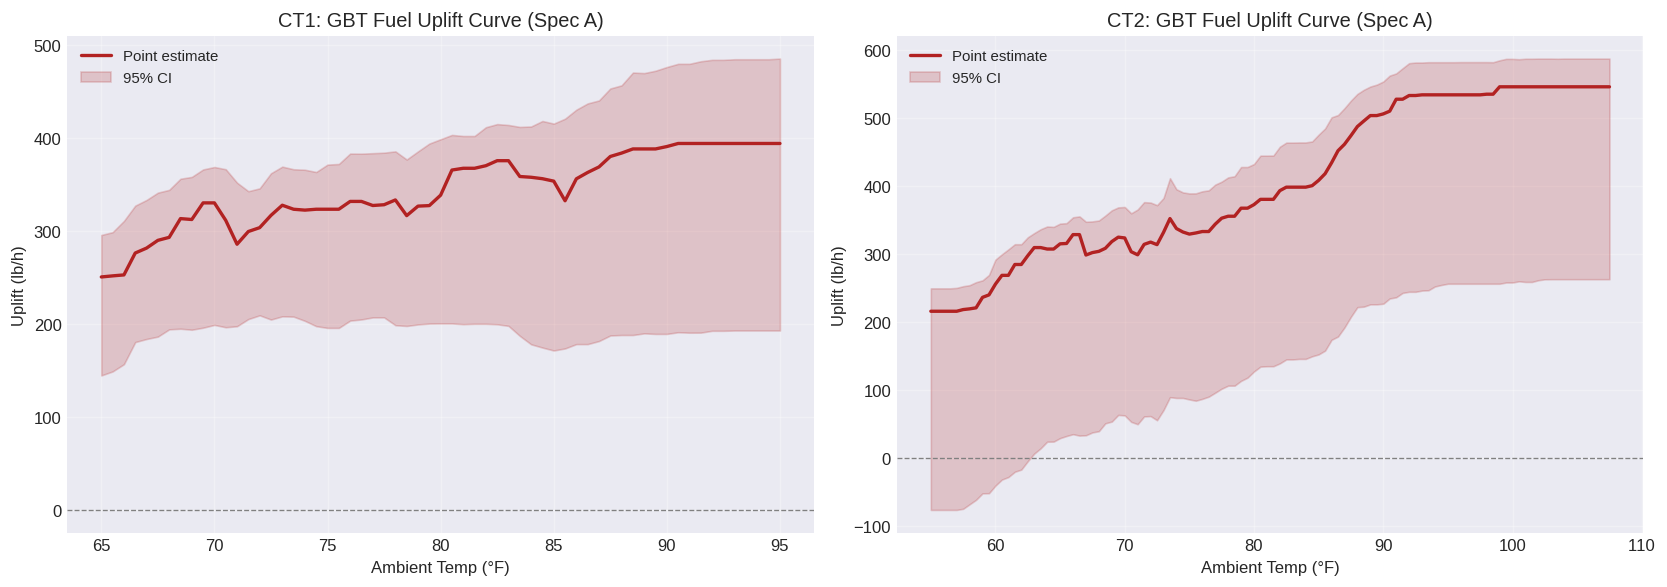

Saved: ./outputs/gbt_baseline/gbt_uplift_curve_fuel_gbt_specA_overlapON.png


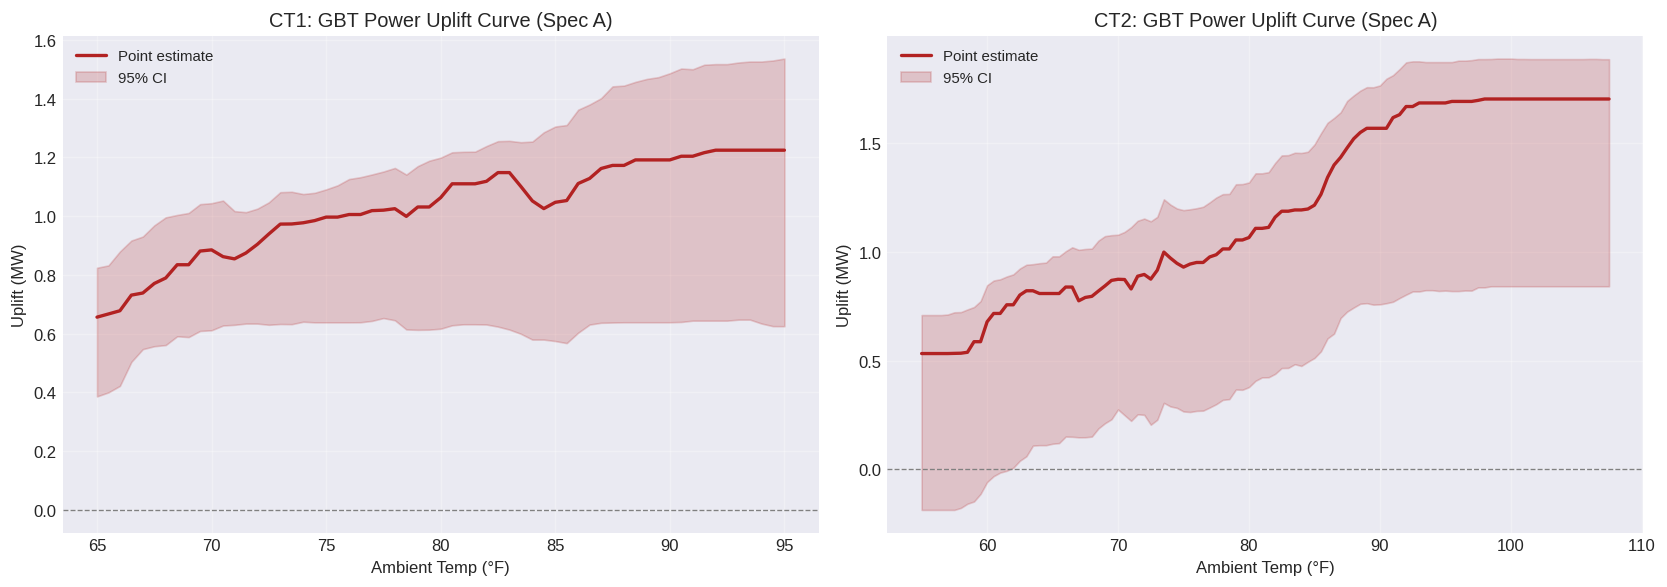

Saved: ./outputs/gbt_baseline/gbt_uplift_curve_power_gbt_specA_overlapON.png


In [ ]:
# ============================================================================
# GBT Uplift Curve Plots — smooth (power + fuel, per turbine)
# ============================================================================
if len(gbt_curve_rows) > 0:
    outcome_names = sorted(set(cr['outcome'] for cr in gbt_curve_rows))

    for outcome_name in outcome_names:
        curves = [cr for cr in gbt_curve_rows if cr['outcome'] == outcome_name]
        n_ct = len(curves)
        if n_ct == 0:
            continue

        unit = 'MW' if outcome_name == 'power' else 'lb/h'

        fig, axes = plt.subplots(1, n_ct, figsize=(7*n_ct, 5), squeeze=False)
        for i, cr in enumerate(curves):
            ax = axes[0, i]
            temps, pe = cr['temps'], cr['point_est']
            clo, chi  = cr['ci_lo'], cr['ci_hi']

            ax.plot(temps, pe, 'firebrick', lw=2, label='Point estimate')
            ax.fill_between(temps, clo, chi, alpha=0.2, color='firebrick',
                            label=f'{int(CONFIG["bootstrap"]["ci_level"]*100)}% CI')
            ax.axhline(0, color='grey', ls='--', lw=0.8)
            ax.set_xlabel('Ambient Temp (°F)')
            ax.set_ylabel(f'Uplift ({unit})')
            ax.set_title(f'{cr["turbine"]}: GBT {outcome_name.capitalize()} '
                         f'Uplift Curve (Spec {SPEC})')
            ax.legend(fontsize=9)

        plt.tight_layout()
        fname = f'gbt_uplift_curve_{outcome_name}_{tag}.png'
        fig.savefig(f'{GBT_OUT}/{fname}', dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved: {GBT_OUT}/{fname}')
else:
    print('No GBT curve data to plot.')

### Section 3-4: GBT diagnostic


In [ ]:

# ============================================================================
# GBT DIAGNOSTICS (hold-out day split, factual prediction quality)
# ============================================================================

if CONFIG.get('diagnostics', {}).get('enabled', True):
    SPEC = CONFIG['model']['spec']
    test_frac = CONFIG.get('diagnostics', {}).get('test_days_frac', CONFIG['compare']['test_days_frac'])

    diag_rows = []
    for ct_prefix, ct_label, df_raw in [('ct1','CT1',df_ct1), ('ct2','CT2',df_ct2)]:
        df_prep = prepare_df(df_raw, ct_label, CONFIG['data']['train_temp_range_F'], CONFIG['treatment'])

        for outcome_name, y_col in get_outcome_cols(ct_prefix).items():
            if y_col not in df_prep.columns:
                diag_rows.append({
                    'turbine': ct_label, 'outcome': outcome_name, 'model': 'GBT', 'spec': SPEC,
                    'rmse': np.nan, 'mae': np.nan, 'r2': np.nan, 'n_test': 0, 'note': f'{y_col} missing'
                })
                continue

            # Conservative NA drop (features + y)
            X_all, feat_names = prepare_Xy_gbt(df_prep, ct_prefix, SPEC)
            y_all = df_prep[y_col]
            mask_ok = X_all.notna().all(axis=1) & y_all.notna() & df_prep['day'].notna()
            X_all = X_all.loc[mask_ok, feat_names]
            y_all = y_all.loc[mask_ok]
            df_ok = df_prep.loc[mask_ok].copy()

            if len(df_ok) < 500:
                diag_rows.append({
                    'turbine': ct_label, 'outcome': outcome_name, 'model': 'GBT', 'spec': SPEC,
                    'rmse': np.nan, 'mae': np.nan, 'r2': np.nan, 'n_test': 0, 'note': 'too few rows'
                })
                continue

            # Day-block split
            days = np.array(sorted(df_ok['day'].unique()))
            n_test = max(1, int(len(days) * test_frac))
            test_days = np.random.choice(days, size=n_test, replace=False)

            tr_idx = ~df_ok['day'].isin(test_days)
            te_idx =  df_ok['day'].isin(test_days)

            X_tr, y_tr = X_all.loc[tr_idx], y_all.loc[tr_idx]
            X_te, y_te = X_all.loc[te_idx], y_all.loc[te_idx]

            if len(X_te) < 50:
                diag_rows.append({
                    'turbine': ct_label, 'outcome': outcome_name, 'model': 'GBT', 'spec': SPEC,
                    'rmse': np.nan, 'mae': np.nan, 'r2': np.nan, 'n_test': len(X_te), 'note': 'tiny test set'
                })
                continue

            try:
                m = LGBMRegressor(**CONFIG['compare']['lgbm_params'])
                m.fit(X_tr.values, y_tr.values)
                y_hat = m.predict(X_te.values)

                rmse = float(np.sqrt(mean_squared_error(y_te.values, y_hat)))
                mae  = float(mean_absolute_error(y_te.values, y_hat))
                r2   = float(r2_score(y_te.values, y_hat))

                diag_rows.append({
                    'turbine': ct_label, 'outcome': outcome_name, 'model': 'GBT', 'spec': SPEC,
                    'rmse': rmse, 'mae': mae, 'r2': r2, 'n_test': len(X_te), 'note': ''
                })
            except Exception as e:
                diag_rows.append({
                    'turbine': ct_label, 'outcome': outcome_name, 'model': 'GBT', 'spec': SPEC,
                    'rmse': np.nan, 'mae': np.nan, 'r2': np.nan, 'n_test': len(X_te),
                    'note': f'fit/predict failed: {e}'
                })

    gbt_diag_df = pd.DataFrame(diag_rows)
    display(gbt_diag_df)
    gbt_diag_df.to_csv(f'{OUT}/gbt_diagnostics_spec{SPEC}.csv', index=False)
    print(f'Saved: {OUT}/gbt_diagnostics_spec{SPEC}.csv')


  CT1: treatment 'full_vs_off' -> dropped 1,608 partial rows
  CT1: decontamination (+/-10min) -> dropped 305 rows
  CT1: temp [55-110F] -> 33,417 rows
  CT2: treatment 'full_vs_off' -> dropped 1,735 partial rows
  CT2: decontamination (+/-10min) -> dropped 328 rows
  CT2: temp [55-110F] -> 42,046 rows


,turbine,outcome,model,spec,rmse,mae,r2,n_test,note
0,CT1,power,GBT,A,0.3166,0.2031,0.7876,6000,
1,CT1,fuel,GBT,A,72.5486,49.2572,0.9024,6445,
2,CT2,power,GBT,A,0.1790,0.1242,0.8844,7546,
3,CT2,fuel,GBT,A,57.6878,45.1311,0.9222,8140,


Saved: ./outputs/gbt_diagnostics_specA.csv


  CT1: treatment 'full_vs_off' -> dropped 1,608 partial rows
  CT1: decontamination (+/-10min) -> dropped 305 rows
  CT1: temp [55-110F] -> 33,417 rows
  CT1/power GBT SpecA: RMSE=0.1899±0.0417  MAE=0.1246±0.0232  R²=0.8743±0.0552  (30/30 valid rounds)


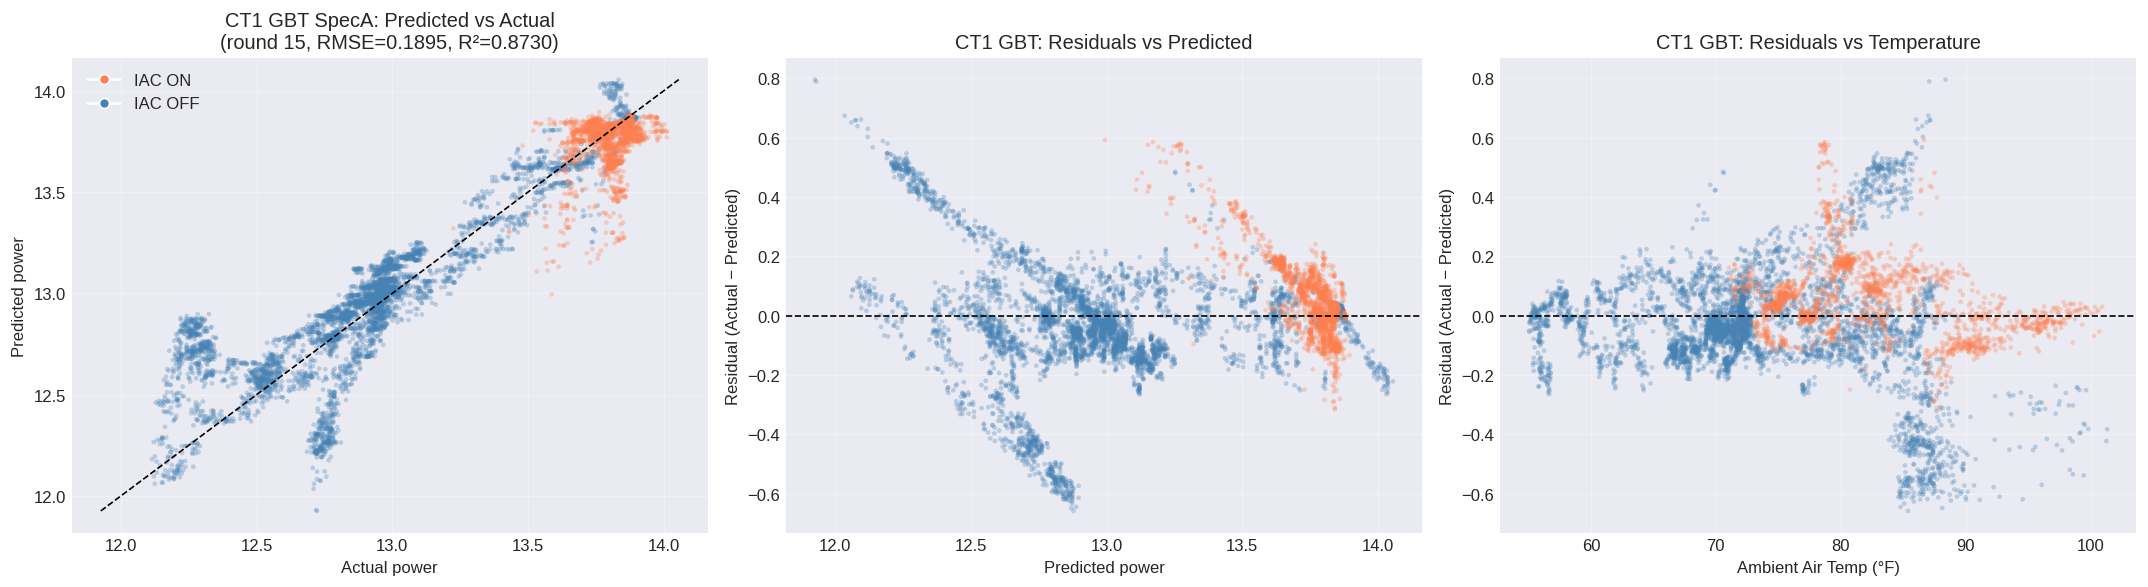

  Saved: ./outputs/gbt_diag_plots_CT1_power_specA.png  (median-RMSE round=15)
  CT1/fuel GBT SpecA: RMSE=66.9944±12.9803  MAE=46.8116±7.6657  R²=0.8559±0.0579  (30/30 valid rounds)


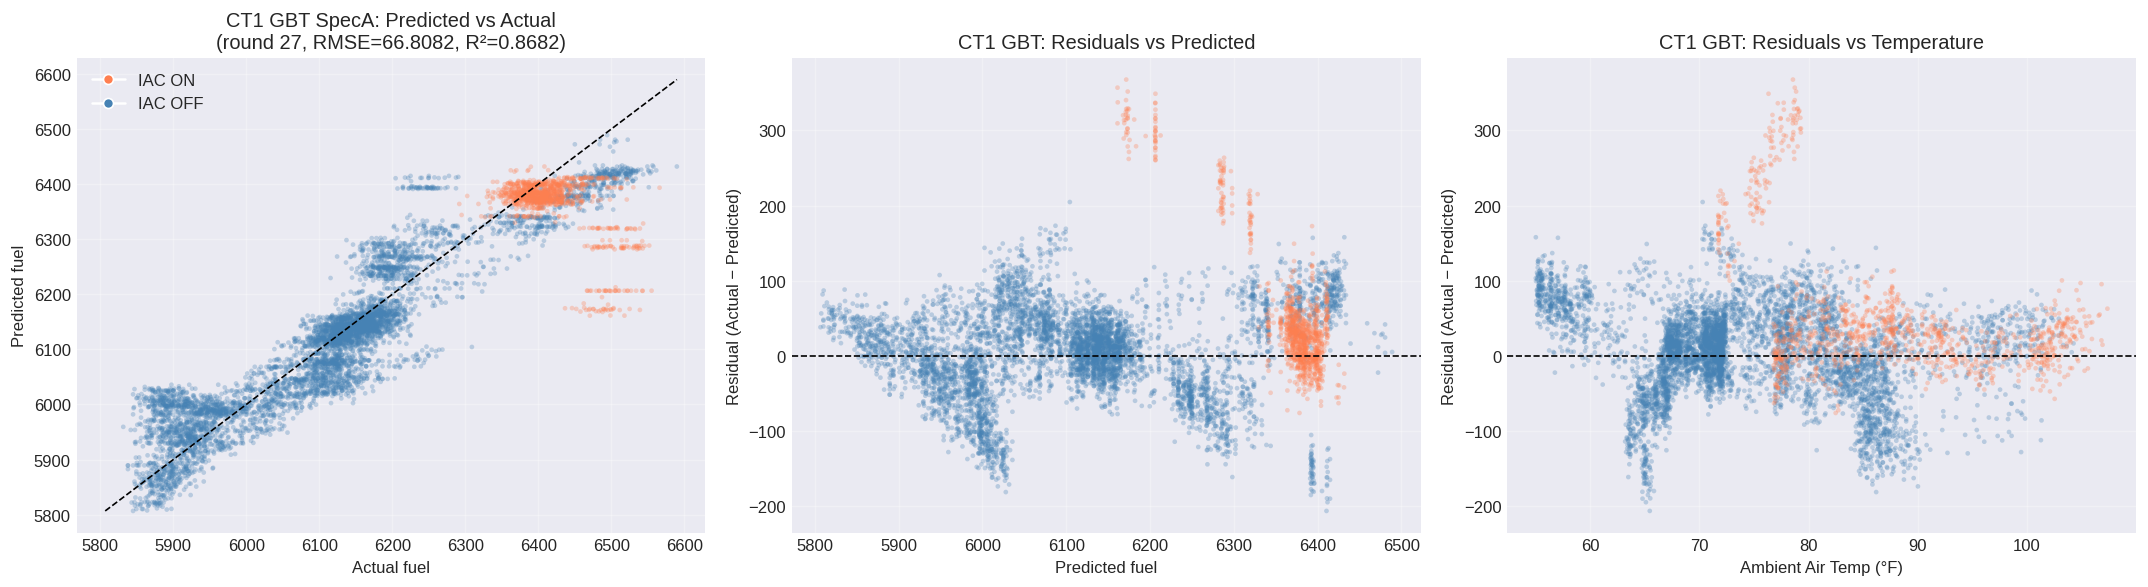

  Saved: ./outputs/gbt_diag_plots_CT1_fuel_specA.png  (median-RMSE round=27)
  CT2: treatment 'full_vs_off' -> dropped 1,735 partial rows
  CT2: decontamination (+/-10min) -> dropped 328 rows
  CT2: temp [55-110F] -> 42,046 rows
  CT2/power GBT SpecA: RMSE=0.1888±0.0292  MAE=0.1414±0.0230  R²=0.8924±0.0454  (30/30 valid rounds)


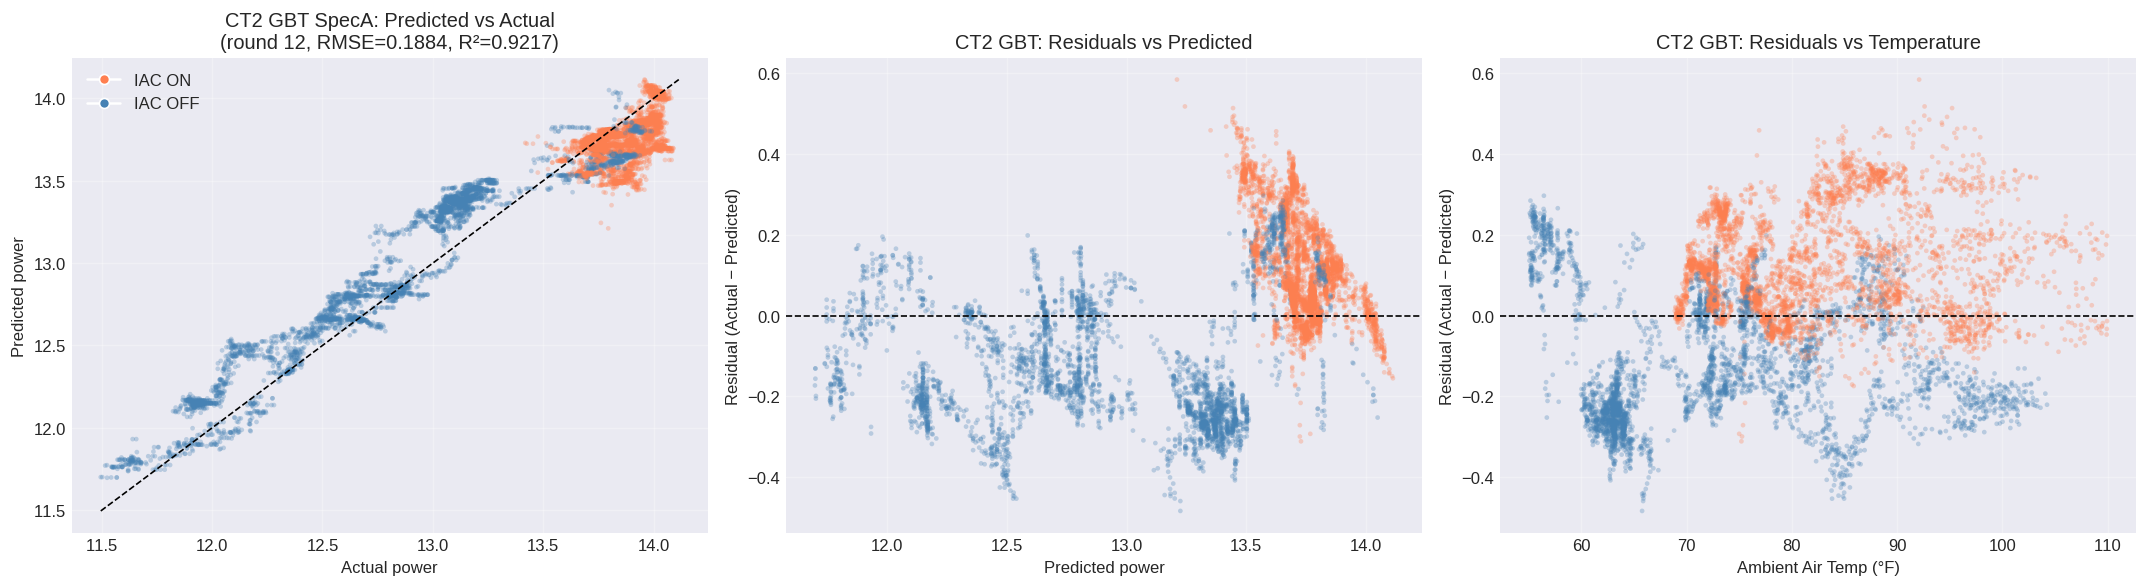

  Saved: ./outputs/gbt_diag_plots_CT2_power_specA.png  (median-RMSE round=12)
  CT2/fuel GBT SpecA: RMSE=62.4412±10.0373  MAE=47.3495±7.2057  R²=0.8886±0.0402  (30/30 valid rounds)


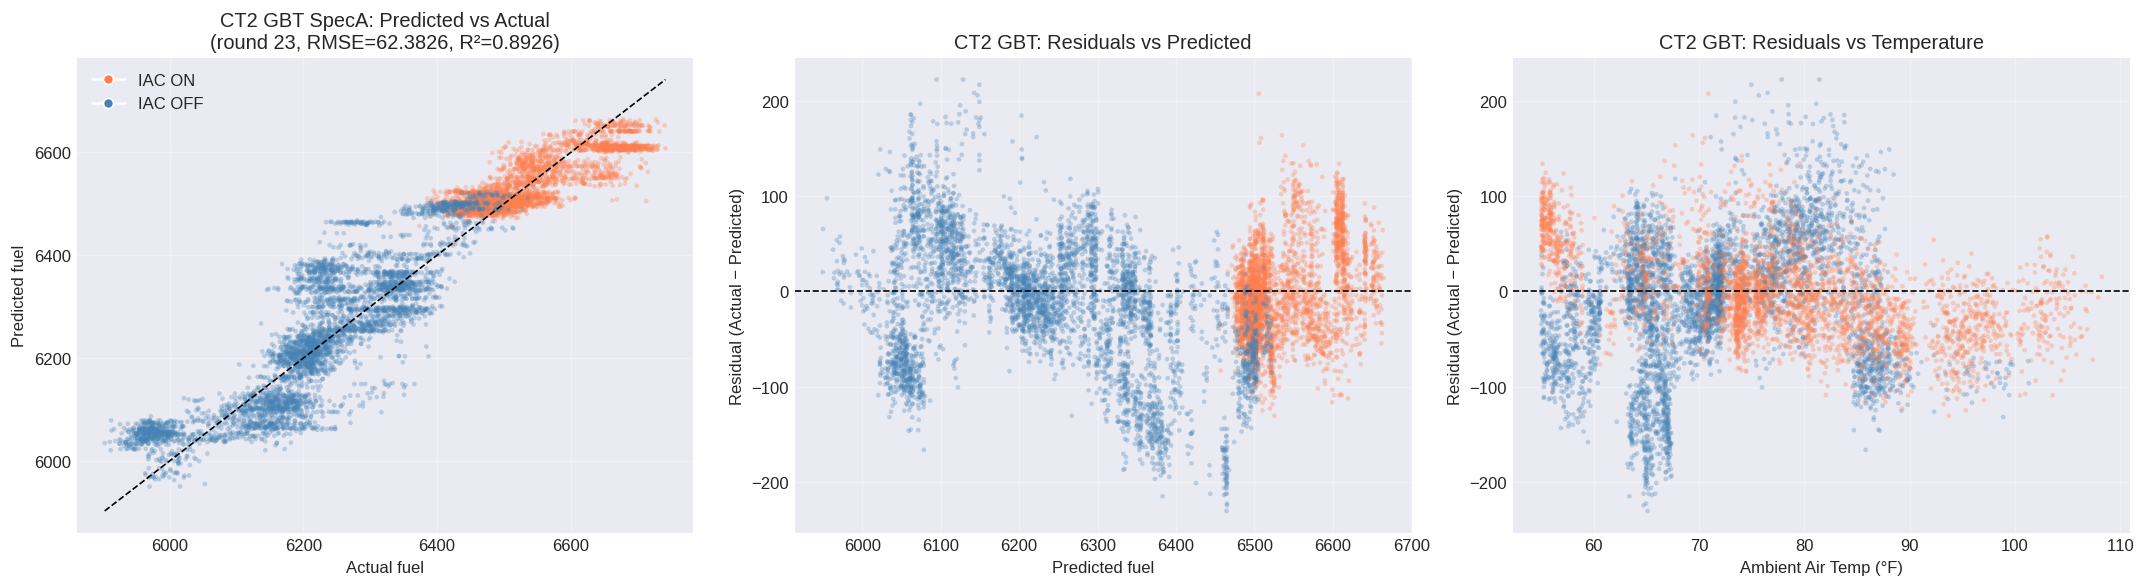

  Saved: ./outputs/gbt_diag_plots_CT2_fuel_specA.png  (median-RMSE round=23)


,turbine,outcome,model,spec,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std,n_test_mean,n_repeats_valid,note
0,CT1,power,GBT,A,0.1899,0.0417,0.1246,0.0232,0.8743,0.0552,6128.5667,30,
1,CT1,fuel,GBT,A,66.9944,12.9803,46.8116,7.6657,0.8559,0.0579,6128.5667,30,
2,CT2,power,GBT,A,0.1888,0.0292,0.1414,0.0230,0.8924,0.0454,8082.5333,30,
3,CT2,fuel,GBT,A,62.4412,10.0373,47.3495,7.2057,0.8886,0.0402,8082.5333,30,


Saved: ./outputs/gbt_diagnostics_specA.csv


In [ ]:
# ============================================================================
# GBT DIAGNOSTICS (Monte Carlo Cross-Validation, day-block split)
# ============================================================================

if CONFIG.get('diagnostics', {}).get('enabled', True):
    SPEC = CONFIG['model']['spec']
    test_frac = CONFIG.get('diagnostics', {}).get('test_days_frac', CONFIG['compare']['test_days_frac'])
    n_repeats = CONFIG.get('diagnostics', {}).get('mccv_repeats', 30)

    diag_rows = []
    for ct_prefix, ct_label, df_raw in [('ct1','CT1',df_ct1), ('ct2','CT2',df_ct2)]:
        df_prep = prepare_df(df_raw, ct_label, CONFIG['data']['train_temp_range_F'], CONFIG['treatment'])

        for outcome_name, y_col in get_outcome_cols(ct_prefix).items():
            if y_col not in df_prep.columns:
                diag_rows.append({
                    'turbine': ct_label, 'outcome': outcome_name, 'model': 'GBT', 'spec': SPEC,
                    'rmse_mean': np.nan, 'rmse_std': np.nan,
                    'mae_mean': np.nan, 'mae_std': np.nan,
                    'r2_mean': np.nan, 'r2_std': np.nan,
                    'n_test_mean': 0, 'n_repeats_valid': 0,
                    'note': f'{y_col} missing'
                })
                continue

            X_all, feat_names = prepare_Xy_gbt(df_prep, ct_prefix, SPEC)
            y_all = df_prep[y_col]
            mask_ok = X_all.notna().all(axis=1) & y_all.notna() & df_prep['day'].notna()
            X_all = X_all.loc[mask_ok, feat_names]
            y_all = y_all.loc[mask_ok]
            df_ok = df_prep.loc[mask_ok].copy()

            if len(df_ok) < 500:
                diag_rows.append({
                    'turbine': ct_label, 'outcome': outcome_name, 'model': 'GBT', 'spec': SPEC,
                    'rmse_mean': np.nan, 'rmse_std': np.nan,
                    'mae_mean': np.nan, 'mae_std': np.nan,
                    'r2_mean': np.nan, 'r2_std': np.nan,
                    'n_test_mean': 0, 'n_repeats_valid': 0,
                    'note': 'too few rows'
                })
                continue

            days = np.array(sorted(df_ok['day'].unique()))
            n_test = max(1, int(len(days) * test_frac))

            round_metrics = []
            for r in range(n_repeats):
                rng = np.random.RandomState(CONFIG['seed'] + r)
                test_days = rng.choice(days, size=n_test, replace=False)

                tr_idx = ~df_ok['day'].isin(test_days)
                te_idx =  df_ok['day'].isin(test_days)

                X_tr, y_tr = X_all.loc[tr_idx], y_all.loc[tr_idx]
                X_te, y_te = X_all.loc[te_idx], y_all.loc[te_idx]

                if len(X_te) < 50 or len(X_tr) < 200:
                    continue
                try:
                    m = LGBMRegressor(**CONFIG['compare']['lgbm_params'])
                    m.fit(X_tr.values, y_tr.values)
                    y_hat = m.predict(X_te.values)
                    round_metrics.append({
                        'rmse': float(np.sqrt(mean_squared_error(y_te.values, y_hat))),
                        'mae':  float(mean_absolute_error(y_te.values, y_hat)),
                        'r2':   float(r2_score(y_te.values, y_hat)),
                        'n_te': len(X_te),
                        '_y_true': y_te.values.copy(),
                        '_y_hat':  y_hat.copy(),
                        '_temp':   df_ok.loc[te_idx, 'ambient_air_temp_f'].values.copy(),
                        '_D':      df_ok.loc[te_idx, 'D'].values.copy(),
                    })
                except:
                    continue

            if len(round_metrics) > 0:
                mdf = pd.DataFrame(round_metrics)
                diag_rows.append({
                    'turbine': ct_label, 'outcome': outcome_name, 'model': 'GBT', 'spec': SPEC,
                    'rmse_mean': float(mdf['rmse'].mean()), 'rmse_std': float(mdf['rmse'].std()),
                    'mae_mean':  float(mdf['mae'].mean()),  'mae_std':  float(mdf['mae'].std()),
                    'r2_mean':   float(mdf['r2'].mean()),   'r2_std':   float(mdf['r2'].std()),
                    'n_test_mean': float(mdf['n_te'].mean()),
                    'n_repeats_valid': len(round_metrics),
                    'note': ''
                })
                print(f'  {ct_label}/{outcome_name} GBT Spec{SPEC}: '
                      f'RMSE={mdf["rmse"].mean():.4f}±{mdf["rmse"].std():.4f}  '
                      f'MAE={mdf["mae"].mean():.4f}±{mdf["mae"].std():.4f}  '
                      f'R²={mdf["r2"].mean():.4f}±{mdf["r2"].std():.4f}  '
                      f'({len(round_metrics)}/{n_repeats} valid rounds)')
                # --- Pick the median-RMSE round for diagnostic plots ---
                mdf = pd.DataFrame(round_metrics)
                median_rmse = mdf['rmse'].median()
                best_idx = (mdf['rmse'] - median_rmse).abs().idxmin()
                rep = round_metrics[best_idx]

                y_true_plot = rep['_y_true']
                y_hat_plot  = rep['_y_hat']
                temp_plot   = rep['_temp']
                D_plot      = rep['_D']
                resid       = y_true_plot - y_hat_plot

                fig, axes = plt.subplots(1, 3, figsize=(18, 5))

                # (1) Predicted vs Actual
                ax = axes[0]
                colors = np.where(D_plot == 1, 'coral', 'steelblue')
                ax.scatter(y_true_plot, y_hat_plot, c=colors, alpha=0.3, s=8, edgecolors='none')
                lo = min(y_true_plot.min(), y_hat_plot.min())
                hi = max(y_true_plot.max(), y_hat_plot.max())
                ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
                ax.set_xlabel(f'Actual {outcome_name}')
                ax.set_ylabel(f'Predicted {outcome_name}')
                ax.set_title(f'{ct_label} GBT Spec{SPEC}: Predicted vs Actual\n'
                             f'(round {best_idx}, RMSE={rep["rmse"]:.4f}, R²={rep["r2"]:.4f})')
                ax.legend(handles=[
                    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='coral', label='IAC ON'),
                    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', label='IAC OFF'),
                ], loc='upper left')

                # (2) Residuals vs Predicted
                ax = axes[1]
                ax.scatter(y_hat_plot, resid, c=colors, alpha=0.3, s=8, edgecolors='none')
                ax.axhline(0, color='k', ls='--', lw=1)
                ax.set_xlabel(f'Predicted {outcome_name}')
                ax.set_ylabel('Residual (Actual − Predicted)')
                ax.set_title(f'{ct_label} GBT: Residuals vs Predicted')

                # (3) Residuals vs Temperature
                ax = axes[2]
                ax.scatter(temp_plot, resid, c=colors, alpha=0.3, s=8, edgecolors='none')
                ax.axhline(0, color='k', ls='--', lw=1)
                ax.set_xlabel('Ambient Air Temp (°F)')
                ax.set_ylabel('Residual (Actual − Predicted)')
                ax.set_title(f'{ct_label} GBT: Residuals vs Temperature')

                plt.tight_layout()
                fname = f'gbt_diag_plots_{ct_label}_{outcome_name}_spec{SPEC}.png'
                fig.savefig(f'{OUT}/{fname}', dpi=150, bbox_inches='tight')
                plt.show()
                print(f'  Saved: {OUT}/{fname}  (median-RMSE round={best_idx})')
            else:
                diag_rows.append({
                    'turbine': ct_label, 'outcome': outcome_name, 'model': 'GBT', 'spec': SPEC,
                    'rmse_mean': np.nan, 'rmse_std': np.nan,
                    'mae_mean': np.nan, 'mae_std': np.nan,
                    'r2_mean': np.nan, 'r2_std': np.nan,
                    'n_test_mean': 0, 'n_repeats_valid': 0,
                    'note': 'all rounds failed'
                })

    gbt_diag_df = pd.DataFrame(diag_rows)
    display(gbt_diag_df)
    gbt_diag_df.to_csv(f'{OUT}/gbt_diagnostics_spec{SPEC}.csv', index=False)
    print(f'Saved: {OUT}/gbt_diagnostics_spec{SPEC}.csv')

---
## Section 4. Full Comparison OLS vs GBT

Four complementary comparison axes:
- **4A.** Paired MCCV — factual prediction quality on identical splits
- **4B.** Smooth uplift curve overlay — treatment effect agreement by temperature
- **4C.** ATE robustness table — cross-check plugin vs AIPW × OLS vs GBT
- **4D.** Per-observation agreement — τ̂ scatter, Bland-Altman, sign agreement

### 4A. Paired MCCV — Prediction Quality on Identical Splits

In [ ]:
from patsy import cr

# ============================================================================
# 4A. PAIRED MCCV: OLS vs GBT on identical day-block splits
# ============================================================================
CMP_OUT = os.path.join(OUT, 'compare_ols_gbt')
os.makedirs(CMP_OUT, exist_ok=True)

SPEC      = CONFIG['model']['spec']
test_frac = CONFIG.get('diagnostics', {}).get('test_days_frac', 0.20)
n_repeats = CONFIG.get('diagnostics', {}).get('mccv_repeats', 30)

paired_rows = []

for ct_prefix, ct_label, df_raw in [('ct1','CT1',df_ct1), ('ct2','CT2',df_ct2)]:
    df_prep = prepare_df(df_raw, ct_label,
                         CONFIG['data']['train_temp_range_F'], CONFIG['treatment'])

    for outcome_name, y_col in get_outcome_cols(ct_prefix).items():
        # --- OLS needs ---
        ols_y_col, formula = build_formula(ct_prefix, SPEC, y_col=y_col)
        needed_ols = [ols_y_col, 'D', 'ambient_air_temp_f', 'ambient_rh_pct',
                      f'{ct_prefix}_gas_supply_pressure_psi',
                      f'{ct_prefix}_inlet_air_supply_pressure_psig',
                      'hour', 'day', 'demand']
        if SPEC == 'B':
            needed_ols += [f'{ct_prefix}_pcd', f'{ct_prefix}_t7_avg_temp']

        # --- GBT needs ---
        X_all_gbt, feat_names = prepare_Xy_gbt(df_prep, ct_prefix, SPEC)
        y_all_gbt = df_prep[y_col]

        # --- Common clean mask (both models must have valid data) ---
        mask_ols = df_prep[needed_ols].notna().all(axis=1)
        mask_gbt = X_all_gbt.notna().all(axis=1) & y_all_gbt.notna()
        mask_ok  = mask_ols & mask_gbt & df_prep['day'].notna()

        df_clean    = df_prep.loc[mask_ok].copy()
        X_clean_gbt = X_all_gbt.loc[mask_ok, feat_names]
        y_clean     = y_all_gbt.loc[mask_ok]

        if len(df_clean) < 500:
            print(f'  {ct_label}/{outcome_name}: too few rows ({len(df_clean)}), skipping')
            continue

        days = np.array(sorted(df_clean['day'].unique()))
        n_test = max(1, int(len(days) * test_frac))

        round_metrics = []
        for r in range(n_repeats):
            rng = np.random.RandomState(CONFIG['seed'] + r)
            test_days = rng.choice(days, size=n_test, replace=False)

            tr_mask = ~df_clean['day'].isin(test_days)
            te_mask =  df_clean['day'].isin(test_days)

            df_tr = df_clean.loc[tr_mask]
            df_te = df_clean.loc[te_mask]
            if len(df_te) < 50 or df_tr['D'].nunique() < 2:
                continue

            # --- OLS ---
            try:
                m_ols = smf.ols(formula, data=df_tr).fit()
                # Filter test to hours seen in train (patsy C(hour) requirement)
                hours_tr = set(df_tr['hour'].unique())
                df_te_safe = df_te[df_te['hour'].isin(hours_tr)]
                if len(df_te_safe) < 50:
                    continue
                y_hat_ols = m_ols.predict(df_te_safe).values
            except Exception as e:
                if r == 0: print(f'    OLS round {r} failed: {e}')
                continue

            # --- GBT ---
            try:
                m_gbt = LGBMRegressor(**CONFIG['compare']['lgbm_params'])
                m_gbt.fit(X_clean_gbt.loc[tr_mask].values, y_clean.loc[tr_mask].values)
                # Use same safe test set for GBT
                te_safe_mask = df_clean.index.isin(df_te_safe.index)
                y_hat_gbt = m_gbt.predict(X_clean_gbt.loc[te_safe_mask].values)
            except Exception as e:
                if r == 0: print(f'    GBT round {r} failed: {e}')
                continue

            y_true = y_clean.loc[df_te_safe.index].values
            rmse_ols = float(np.sqrt(mean_squared_error(y_true, y_hat_ols)))
            rmse_gbt = float(np.sqrt(mean_squared_error(y_true, y_hat_gbt)))
            mae_ols  = float(mean_absolute_error(y_true, y_hat_ols))
            mae_gbt  = float(mean_absolute_error(y_true, y_hat_gbt))
            r2_ols   = float(r2_score(y_true, y_hat_ols))
            r2_gbt   = float(r2_score(y_true, y_hat_gbt))

            round_metrics.append({
                'rmse_ols': rmse_ols, 'rmse_gbt': rmse_gbt,
                'mae_ols':  mae_ols,  'mae_gbt':  mae_gbt,
                'r2_ols':   r2_ols,   'r2_gbt':   r2_gbt,
            })

        if len(round_metrics) < 5:
            print(f'  {ct_label}/{outcome_name}: only {len(round_metrics)} valid rounds, skipping')
            continue

        mdf = pd.DataFrame(round_metrics)
        mdf['delta_rmse'] = mdf['rmse_ols'] - mdf['rmse_gbt']  # positive = GBT better
        mdf['delta_mae']  = mdf['mae_ols']  - mdf['mae_gbt']
        mdf['delta_r2']   = mdf['r2_gbt']   - mdf['r2_ols']    # positive = GBT better

        # Paired t-test on delta_rmse
        from scipy import stats
        t_stat, p_val = stats.ttest_1samp(mdf['delta_rmse'].values, 0)

        unit = 'MW' if outcome_name == 'power' else 'lb/h'
        print(f'\n  {ct_label}/{outcome_name} ({len(round_metrics)} rounds):')
        print(f'    RMSE  OLS={mdf["rmse_ols"].mean():.4f}±{mdf["rmse_ols"].std():.4f}  '
              f'GBT={mdf["rmse_gbt"].mean():.4f}±{mdf["rmse_gbt"].std():.4f}  '
              f'ΔRMSE={mdf["delta_rmse"].mean():+.4f}±{mdf["delta_rmse"].std():.4f}  '
              f'p={p_val:.4f}')
        print(f'    R²    OLS={mdf["r2_ols"].mean():.4f}±{mdf["r2_ols"].std():.4f}  '
              f'GBT={mdf["r2_gbt"].mean():.4f}±{mdf["r2_gbt"].std():.4f}')

        paired_rows.append({
            'turbine': ct_label, 'outcome': outcome_name, 'spec': SPEC,
            'n_rounds': len(round_metrics),
            'rmse_ols_mean': mdf['rmse_ols'].mean(), 'rmse_ols_std': mdf['rmse_ols'].std(),
            'rmse_gbt_mean': mdf['rmse_gbt'].mean(), 'rmse_gbt_std': mdf['rmse_gbt'].std(),
            'delta_rmse_mean': mdf['delta_rmse'].mean(), 'delta_rmse_std': mdf['delta_rmse'].std(),
            'delta_rmse_t': t_stat, 'delta_rmse_p': p_val,
            'r2_ols_mean': mdf['r2_ols'].mean(), 'r2_ols_std': mdf['r2_ols'].std(),
            'r2_gbt_mean': mdf['r2_gbt'].mean(), 'r2_gbt_std': mdf['r2_gbt'].std(),
        })

paired_df = pd.DataFrame(paired_rows)
paired_df.to_csv(f'{CMP_OUT}/paired_mccv_summary.csv', index=False)
display(paired_df)
print(f'\nSaved: {CMP_OUT}/paired_mccv_summary.csv')

  CT1: treatment 'full_vs_off' -> dropped 1,608 partial rows
  CT1: decontamination (+/-10min) -> dropped 305 rows
  CT1: temp [55-110F] -> 33,417 rows

  CT1/power (30 rounds):
    RMSE  OLS=0.1587±0.0298  GBT=0.1899±0.0417  ΔRMSE=-0.0312±0.0291  p=0.0000
    R²    OLS=0.9123±0.0378  GBT=0.8743±0.0552

  CT1/fuel (30 rounds):
    RMSE  OLS=56.7520±9.3556  GBT=66.9944±12.9803  ΔRMSE=-10.2424±8.9121  p=0.0000
    R²    OLS=0.8968±0.0388  GBT=0.8559±0.0579
  CT2: treatment 'full_vs_off' -> dropped 1,735 partial rows
  CT2: decontamination (+/-10min) -> dropped 328 rows
  CT2: temp [55-110F] -> 42,046 rows

  CT2/power (30 rounds):
    RMSE  OLS=0.1868±0.0295  GBT=0.1888±0.0292  ΔRMSE=-0.0020±0.0274  p=0.6924
    R²    OLS=0.8933±0.0480  GBT=0.8924±0.0454

  CT2/fuel (30 rounds):
    RMSE  OLS=63.0215±8.3607  GBT=62.4412±10.0373  ΔRMSE=+0.5803±8.0802  p=0.6969
    R²    OLS=0.8859±0.0405  GBT=0.8886±0.0402


,turbine,outcome,spec,n_rounds,rmse_ols_mean,rmse_ols_std,rmse_gbt_mean,rmse_gbt_std,delta_rmse_mean,delta_rmse_std,delta_rmse_t,delta_rmse_p,r2_ols_mean,r2_ols_std,r2_gbt_mean,r2_gbt_std
0,CT1,power,A,30,0.1587,0.0298,0.1899,0.0417,-0.0312,0.0291,-5.8869,0.0000,0.9123,0.0378,0.8743,0.0552
1,CT1,fuel,A,30,56.7520,9.3556,66.9944,12.9803,-10.2424,8.9121,-6.2948,0.0000,0.8968,0.0388,0.8559,0.0579
2,CT2,power,A,30,0.1868,0.0295,0.1888,0.0292,-0.0020,0.0274,-0.3996,0.6924,0.8933,0.0480,0.8924,0.0454
3,CT2,fuel,A,30,63.0215,8.3607,62.4412,10.0373,0.5803,8.0802,0.3934,0.6969,0.8859,0.0405,0.8886,0.0402



Saved: ./outputs/compare_ols_gbt/paired_mccv_summary.csv


### 4B. Smooth Uplift Curve Overlay — OLS vs GBT
Reuses curves computed in Section 2 (`all_results`) and Section 3 (`gbt_curve_rows`).

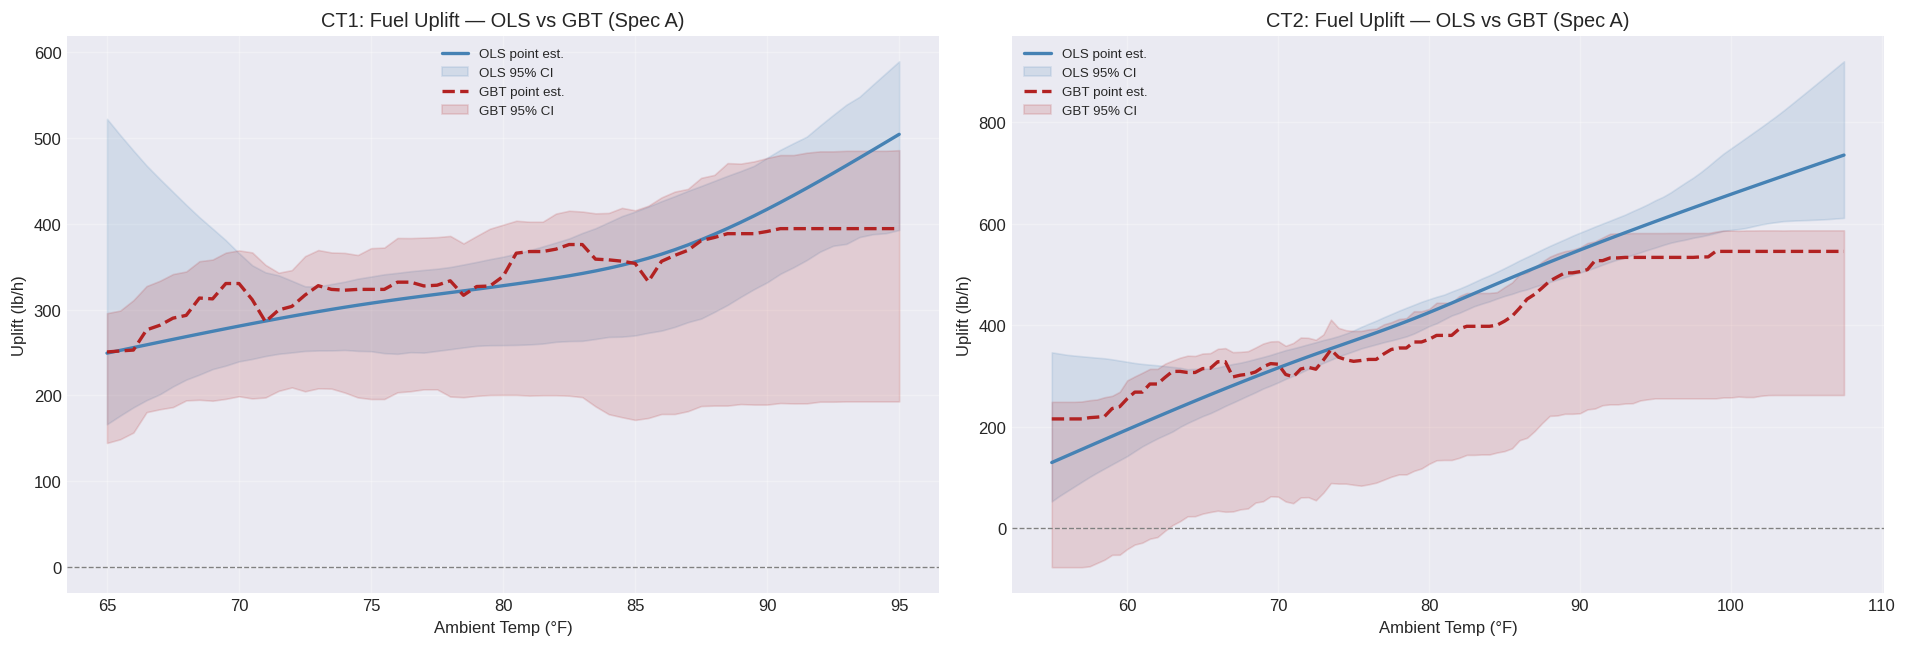

Saved: ./outputs/compare_ols_gbt/uplift_overlay_fuel_specA.png


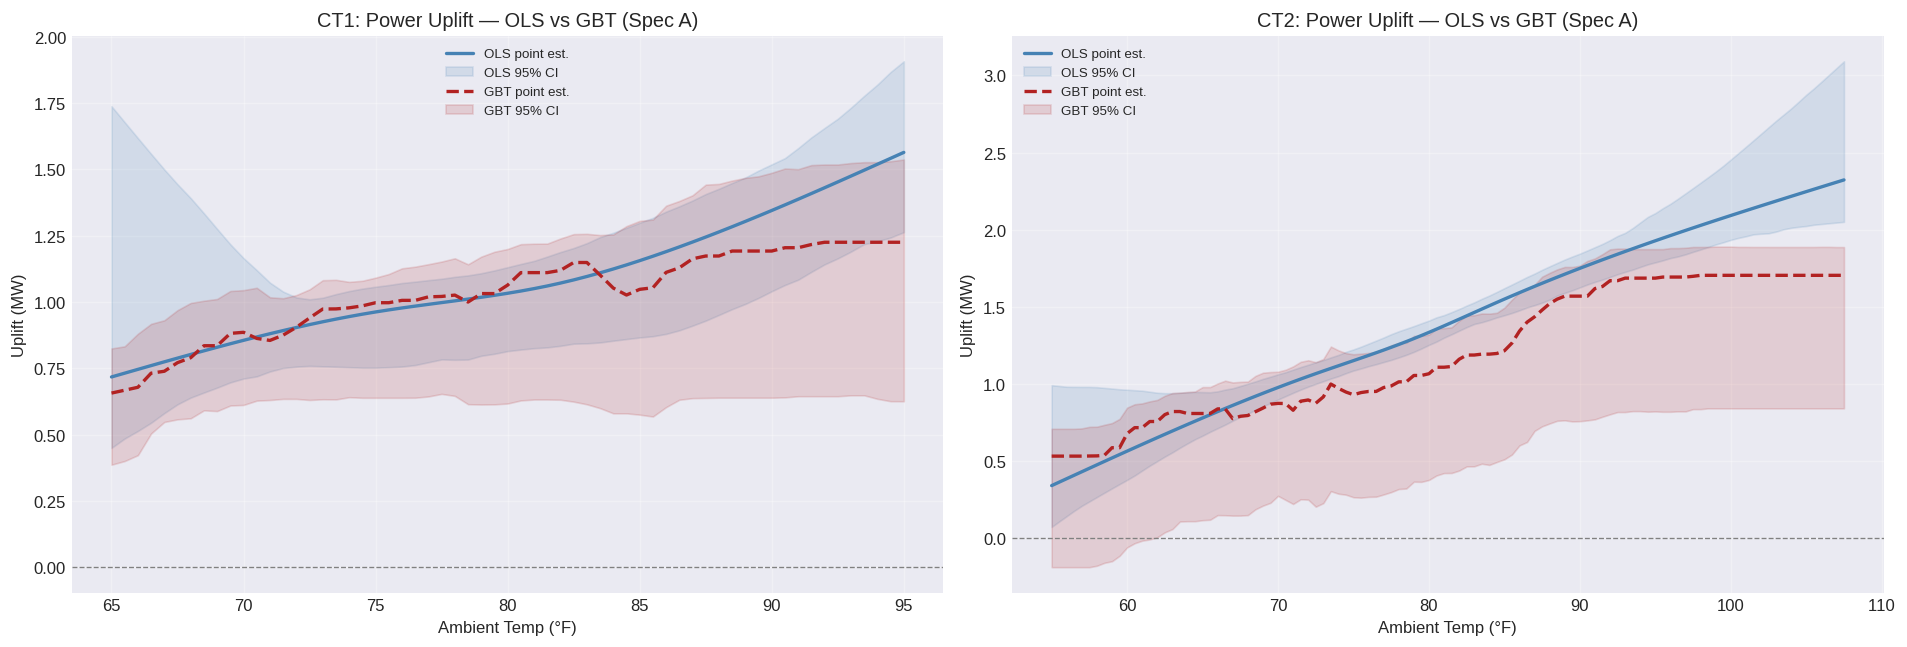

Saved: ./outputs/compare_ols_gbt/uplift_overlay_power_specA.png


In [ ]:
# ============================================================================
# 4B. SMOOTH UPLIFT OVERLAY: OLS (steelblue) vs GBT (firebrick) on same axes
# ============================================================================

outcome_names = sorted(set(r['outcome_name'] for r in all_results.values()))

for outcome_name in outcome_names:
    # Gather OLS results for this outcome
    ols_curves = {k: v for k, v in all_results.items() if v['outcome_name'] == outcome_name}
    # Gather GBT results for this outcome
    gbt_curves = [cr for cr in gbt_curve_rows if cr['outcome'] == outcome_name]

    turbines = sorted(set(v['ct_label'] for v in ols_curves.values()))
    n_ct = len(turbines)
    if n_ct == 0:
        continue

    unit = 'MW' if outcome_name == 'power' else 'lb/h'

    fig, axes = plt.subplots(1, n_ct, figsize=(8*n_ct, 5.5), squeeze=False)
    for i, ct_label in enumerate(turbines):
        ax = axes[0, i]

        # --- OLS curve ---
        ols_key = f'{ct_label}_{outcome_name}'
        if ols_key in ols_curves and ols_curves[ols_key]['curve'] is not None:
            temps_o, pe_o, clo_o, chi_o = ols_curves[ols_key]['curve']
            ax.plot(temps_o, pe_o, color='steelblue', lw=2, label='OLS point est.')
            ax.fill_between(temps_o, clo_o, chi_o, alpha=0.15, color='steelblue',
                            label='OLS 95% CI')

        # --- GBT curve ---
        gbt_match = [cr for cr in gbt_curves if cr['turbine'] == ct_label]
        if len(gbt_match) > 0:
            cr = gbt_match[0]
            ax.plot(cr['temps'], cr['point_est'], color='firebrick', lw=2,
                    ls='--', label='GBT point est.')
            ax.fill_between(cr['temps'], cr['ci_lo'], cr['ci_hi'],
                            alpha=0.15, color='firebrick', label='GBT 95% CI')

        ax.axhline(0, color='grey', ls='--', lw=0.8)
        ax.set_xlabel('Ambient Temp (°F)')
        ax.set_ylabel(f'Uplift ({unit})')
        ax.set_title(f'{ct_label}: {outcome_name.capitalize()} Uplift — OLS vs GBT (Spec {SPEC})')
        ax.legend(fontsize=8, loc='best')

    plt.tight_layout()
    fname = f'uplift_overlay_{outcome_name}_spec{SPEC}.png'
    fig.savefig(f'{CMP_OUT}/{fname}', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {CMP_OUT}/{fname}')

### 4C. ATE Robustness Table — Plugin vs AIPW × OLS vs GBT
Cross-checks treatment effect estimates from multiple estimators and models.

In [ ]:
from patsy import cr

# ============================================================================
# 4C. ATE ROBUSTNESS TABLE
# Collects: OLS plugin (S2), GBT plugin (S3), AIPW (computed here)
# ============================================================================

# --- Gather plugin ATEs from Section 2 (OLS) and Section 3 (GBT) ---
robustness_rows = []

for key, res in all_results.items():
    robustness_rows.append({
        'turbine': res['ct_label'], 'outcome': res['outcome_name'], 'spec': SPEC,
        'model': 'OLS', 'estimator': 'plugin',
        'ate': res['ate'], 'ci_lo': res['ci_lo'], 'ci_hi': res['ci_hi'],
    })

for er in gbt_effect_rows:
    robustness_rows.append({
        'turbine': er['turbine'], 'outcome': er['outcome'], 'spec': SPEC,
        'model': 'GBT', 'estimator': 'plugin',
        'ate': er['ate'], 'ci_lo': er['ci_lo'], 'ci_hi': er['ci_hi'],
    })

# --- Compute AIPW ATEs on a single fair split ---
np.random.seed(CONFIG['seed'])

for ct_prefix, ct_label, df_raw in [('ct1','CT1',df_ct1), ('ct2','CT2',df_ct2)]:
    df_prep = prepare_df(df_raw, ct_label,
                         CONFIG['data']['train_temp_range_F'], CONFIG['treatment'])

    for outcome_name, y_col in get_outcome_cols(ct_prefix).items():
        if y_col not in df_prep.columns:
            continue

        ols_y_col, formula = build_formula(ct_prefix, SPEC, y_col=y_col)
        x_base = get_feature_cols(ct_prefix, SPEC)
        available_x = [c for c in x_base if c in df_prep.columns]
        needed = [y_col, 'D', 'hour', 'day', 'ambient_air_temp_f'] + available_x
        df_clean = df_prep.dropna(subset=[c for c in needed if c in df_prep.columns]).copy()
        if len(df_clean) < 200:
            continue

        # Day-block split
        unique_days = np.array(sorted(df_clean['day'].unique()))
        n_test = max(1, int(len(unique_days) * CONFIG['compare']['test_days_frac']))
        test_days = np.random.choice(unique_days, size=n_test, replace=False)
        df_train = df_clean[~df_clean['day'].isin(test_days)].copy()
        df_test  = df_clean[ df_clean['day'].isin(test_days)].copy()

        # Overlap on test
        if CONFIG['overlap']['enabled']:
            _, ovl_meta_tr = apply_overlap_filter(df_train, CONFIG['overlap'])
            grid, bins = ovl_meta_tr['grid'], ovl_meta_tr['bins']
            mask_te, _ = _build_strong_mask(df_test, grid, bins)
            df_test = df_test[mask_te.values].copy()

        if len(df_test) < 50:
            continue

        # Fit models
        try:
            m_ols = smf.ols(formula, data=df_train).fit()
        except:
            continue
        X_tr_gbt, feat_names = prepare_Xy_gbt(df_train, ct_prefix, SPEC)
        y_tr_gbt = df_train[y_col]
        mask_g = X_tr_gbt.notna().all(axis=1) & y_tr_gbt.notna()
        m_gbt = LGBMRegressor(**CONFIG['compare']['lgbm_params'])
        m_gbt.fit(X_tr_gbt.loc[mask_g, feat_names].values, y_tr_gbt.loc[mask_g].values)

        # Propensity
        prop_feats_cand = ['ambient_air_temp_f'] + [f'hour_{h}' for h in range(1,24)]
        prop_feats = [c for c in prop_feats_cand if c in X_tr_gbt.columns]
        if len(prop_feats) < 2:
            prop_feats = [c for c in ['ambient_air_temp_f','ambient_rh_pct']
                          if c in X_tr_gbt.columns]
        m_prop = LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000)
        m_prop.fit(X_tr_gbt.loc[mask_g, prop_feats].values,
                   X_tr_gbt.loc[mask_g, 'D'].values)

        # Predict on test
        ts = df_test.copy()

        # Clip test temps to training range
        t_lo_train = df_train['ambient_air_temp_f'].min()
        t_hi_train = df_train['ambient_air_temp_f'].max()
        ts['ambient_air_temp_f'] = ts['ambient_air_temp_f'].clip(t_lo_train, t_hi_train)

        # Filter test to hours seen in train (patsy C(hour) requirement)
        hours_tr = set(df_train['hour'].unique())
        ts = ts[ts['hour'].isin(hours_tr)].copy()
        if len(ts) < 50:
            continue

        ts_on = ts.copy(); ts_on['D'] = 1.0
        ts_off = ts.copy(); ts_off['D'] = 0.0

        X_te, _ = prepare_Xy_gbt(ts, ct_prefix, SPEC)
        for c in feat_names:
            if c not in X_te.columns: X_te[c] = 0
        X_te = X_te[feat_names]

        # Propensity on test
        hour_dum_te = pd.get_dummies(ts['hour'].astype(int), prefix='hour')
        X_prop_te = pd.DataFrame(index=ts.index)
        for f in prop_feats:
            if f.startswith('hour_'):
                X_prop_te[f] = hour_dum_te[f] if f in hour_dum_te.columns else 0
            else:
                X_prop_te[f] = ts[f]
        e_hat = np.clip(m_prop.predict_proba(X_prop_te.values)[:, 1],
                        *CONFIG['compare']['propensity_clip'])

        Y = ts[y_col].values
        D = ts['D'].values

        for mdl_tag, mdl_name in [('ols','OLS'), ('gbt','GBT')]:
            if mdl_tag == 'ols':
                m1 = m_ols.predict(ts_on)
                m0 = m_ols.predict(ts_off)
            else:
                X1 = X_te.copy(); X1['D'] = 1.0
                X0 = X_te.copy(); X0['D'] = 0.0
                m1 = m_gbt.predict(X1[feat_names].values)
                m0 = m_gbt.predict(X0[feat_names].values)
            tau = m1 - m0
            psi = tau + D*(Y - m1)/e_hat - (1-D)*(Y - m0)/(1-e_hat)
            ate_aipw = float(np.mean(psi))

            # Bootstrap CI
            days_te = ts['day'].unique()
            boot_psi = []
            for b in range(CONFIG['compare']['boot_n']):
                bd = np.random.choice(days_te, size=len(days_te), replace=True)
                ts_b = pd.concat([ts[ts['day']==d] for d in bd], ignore_index=True)
                if len(ts_b) < 20: continue
                idx_b = ts_b.index  # after concat these are 0..n
                # Recompute psi for bootstrap sample
                D_b = ts_b['D'].values
                Y_b = ts_b[y_col].values
                if mdl_tag == 'ols':
                    ts_b_on = ts_b.copy(); ts_b_on['D'] = 1.0
                    ts_b_off = ts_b.copy(); ts_b_off['D'] = 0.0
                    # ts_b comes from ts which is already hour-filtered, so safe
                    ts_b_on['ambient_air_temp_f'] = ts_b_on['ambient_air_temp_f'].clip(t_lo_train, t_hi_train)
                    ts_b_off['ambient_air_temp_f'] = ts_b_off['ambient_air_temp_f'].clip(t_lo_train, t_hi_train)
                    m1_b = m_ols.predict(ts_b_on)
                    m0_b = m_ols.predict(ts_b_off)
                else:
                    X_b, _ = prepare_Xy_gbt(ts_b, ct_prefix, SPEC)
                    for c in feat_names:
                        if c not in X_b.columns: X_b[c] = 0
                    X_b = X_b[feat_names]
                    X1_b = X_b.copy(); X1_b['D'] = 1.0
                    X0_b = X_b.copy(); X0_b['D'] = 0.0
                    m1_b = m_gbt.predict(X1_b.values)
                    m0_b = m_gbt.predict(X0_b.values)

                # Propensity for bootstrap sample
                hour_dum_b = pd.get_dummies(ts_b['hour'].astype(int), prefix='hour')
                X_prop_b = pd.DataFrame(index=ts_b.index)
                for f in prop_feats:
                    if f.startswith('hour_'):
                        X_prop_b[f] = hour_dum_b[f] if f in hour_dum_b.columns else 0
                    else:
                        X_prop_b[f] = ts_b[f].values
                e_b = np.clip(m_prop.predict_proba(X_prop_b.values)[:,1],
                              *CONFIG['compare']['propensity_clip'])

                tau_b = m1_b - m0_b
                psi_b = tau_b + D_b*(Y_b - m1_b)/e_b - (1-D_b)*(Y_b - m0_b)/(1-e_b)
                boot_psi.append(float(np.mean(psi_b)))

            alpha = 1 - CONFIG['compare']['boot_ci']
            if len(boot_psi) > 5:
                ci_lo = np.percentile(boot_psi, 100*alpha/2)
                ci_hi = np.percentile(boot_psi, 100*(1-alpha/2))
            else:
                ci_lo, ci_hi = np.nan, np.nan

            robustness_rows.append({
                'turbine': ct_label, 'outcome': outcome_name, 'spec': SPEC,
                'model': mdl_name, 'estimator': 'aipw',
                'ate': ate_aipw, 'ci_lo': ci_lo, 'ci_hi': ci_hi,
            })

# --- Assemble and display ---
rob_df = pd.DataFrame(robustness_rows)
rob_df['ate_str'] = rob_df.apply(
    lambda r: f'{r["ate"]:+.4f} [{r["ci_lo"]:+.4f}, {r["ci_hi"]:+.4f}]'
    if pd.notna(r['ci_lo']) else f'{r["ate"]:+.4f}', axis=1)

for outcome_name in rob_df['outcome'].unique():
    sub = rob_df[rob_df['outcome'] == outcome_name]
    unit = 'MW' if outcome_name == 'power' else 'lb/h'
    pivot = sub.pivot_table(index=['turbine','estimator'],
                            columns='model', values='ate_str', aggfunc='first')
    print(f'\n--- {outcome_name.upper()} ATE ({unit}) ---')
    print(pivot.to_string())

rob_df.to_csv(f'{CMP_OUT}/ate_robustness.csv', index=False)
print(f'\nSaved: {CMP_OUT}/ate_robustness.csv')

  CT1: treatment 'full_vs_off' -> dropped 1,608 partial rows
  CT1: decontamination (+/-10min) -> dropped 305 rows
  CT1: temp [55-110F] -> 33,417 rows
  CT2: treatment 'full_vs_off' -> dropped 1,735 partial rows
  CT2: decontamination (+/-10min) -> dropped 328 rows
  CT2: temp [55-110F] -> 42,046 rows

--- POWER ATE (MW) ---
model                                     GBT                         OLS
turbine estimator                                                        
CT1     aipw       +1.0939 [+0.7534, +1.3294]  +1.2349 [+1.0437, +1.5012]
        plugin     +0.9838 [+0.5436, +1.1296]  +1.0856 [+0.8560, +1.1678]
CT2     aipw       +1.1506 [+0.9651, +1.3009]  +1.2671 [+1.0916, +1.4228]
        plugin     +1.0501 [+0.9205, +1.1895]  +1.2589 [+1.1906, +1.3184]

--- FUEL ATE (lb/h) ---
model                                           GBT                               OLS
turbine estimator                                                                    
CT1     aipw       +338.0629 [+

### 4D. Per-Observation Agreement — τ̂ Scatter & Bland-Altman
Uses a single fair split to examine how OLS and GBT agree at the individual-observation level.

  CT1: treatment 'full_vs_off' -> dropped 1,608 partial rows
  CT1: decontamination (+/-10min) -> dropped 305 rows
  CT1: temp [55-110F] -> 33,417 rows


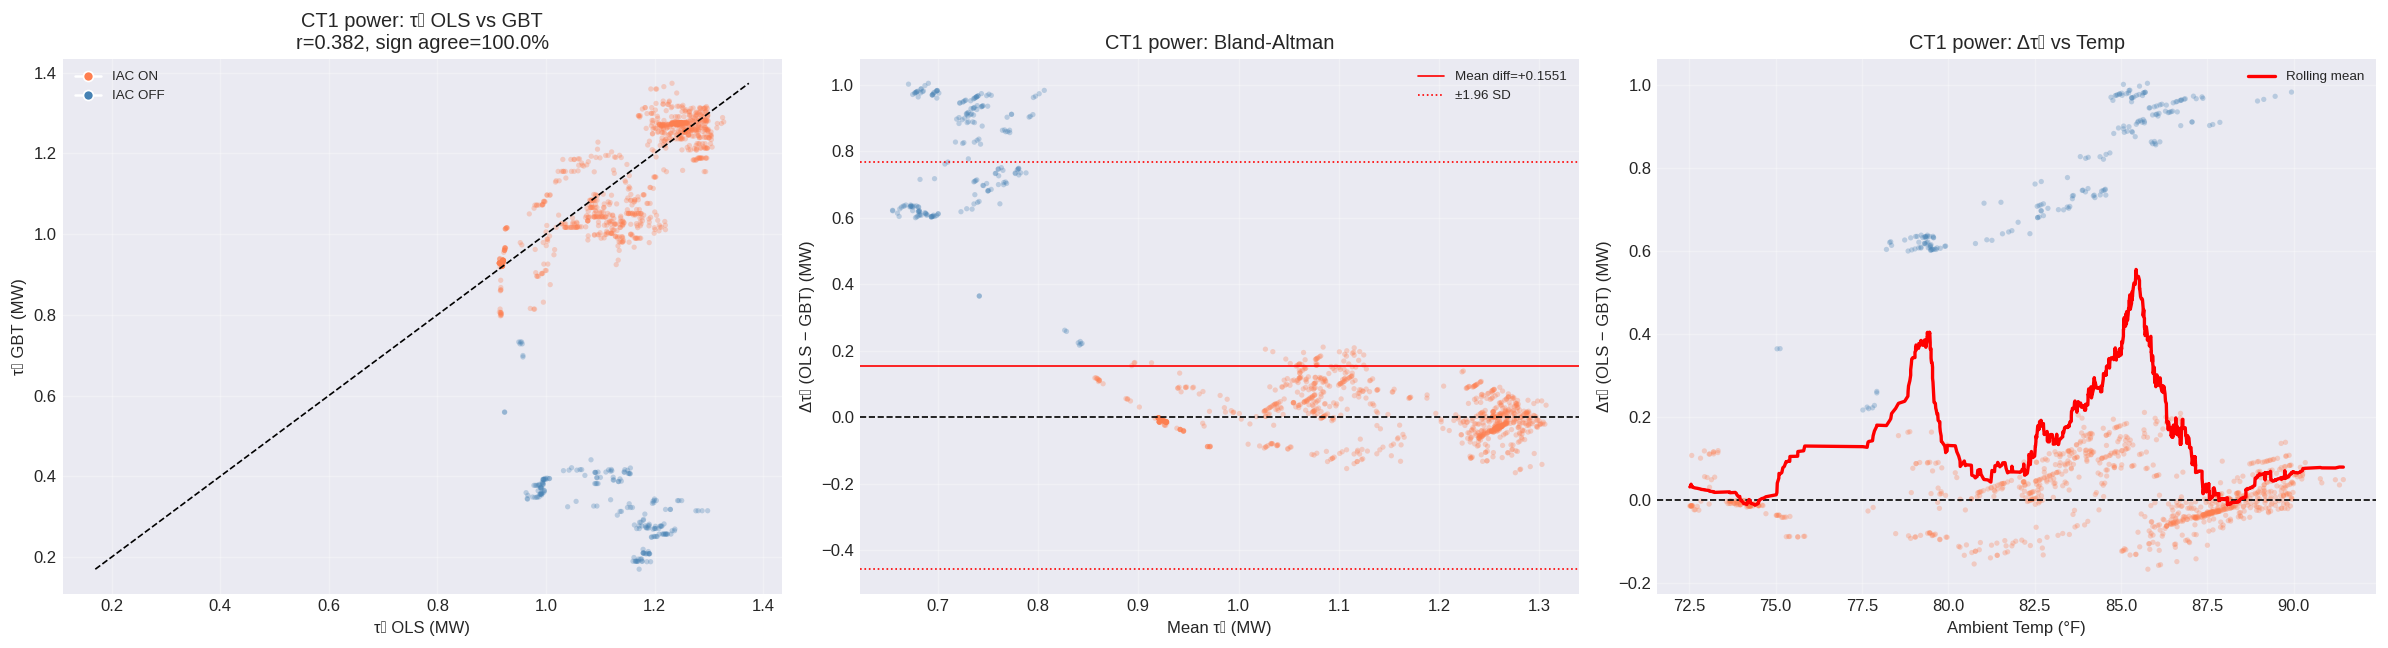

  Saved: ./outputs/compare_ols_gbt/tau_agreement_CT1_power_specA.png
  Correlation: 0.3818  |  Sign agreement: 100.0%  |  Mean Δτ̂: +0.1551 MW


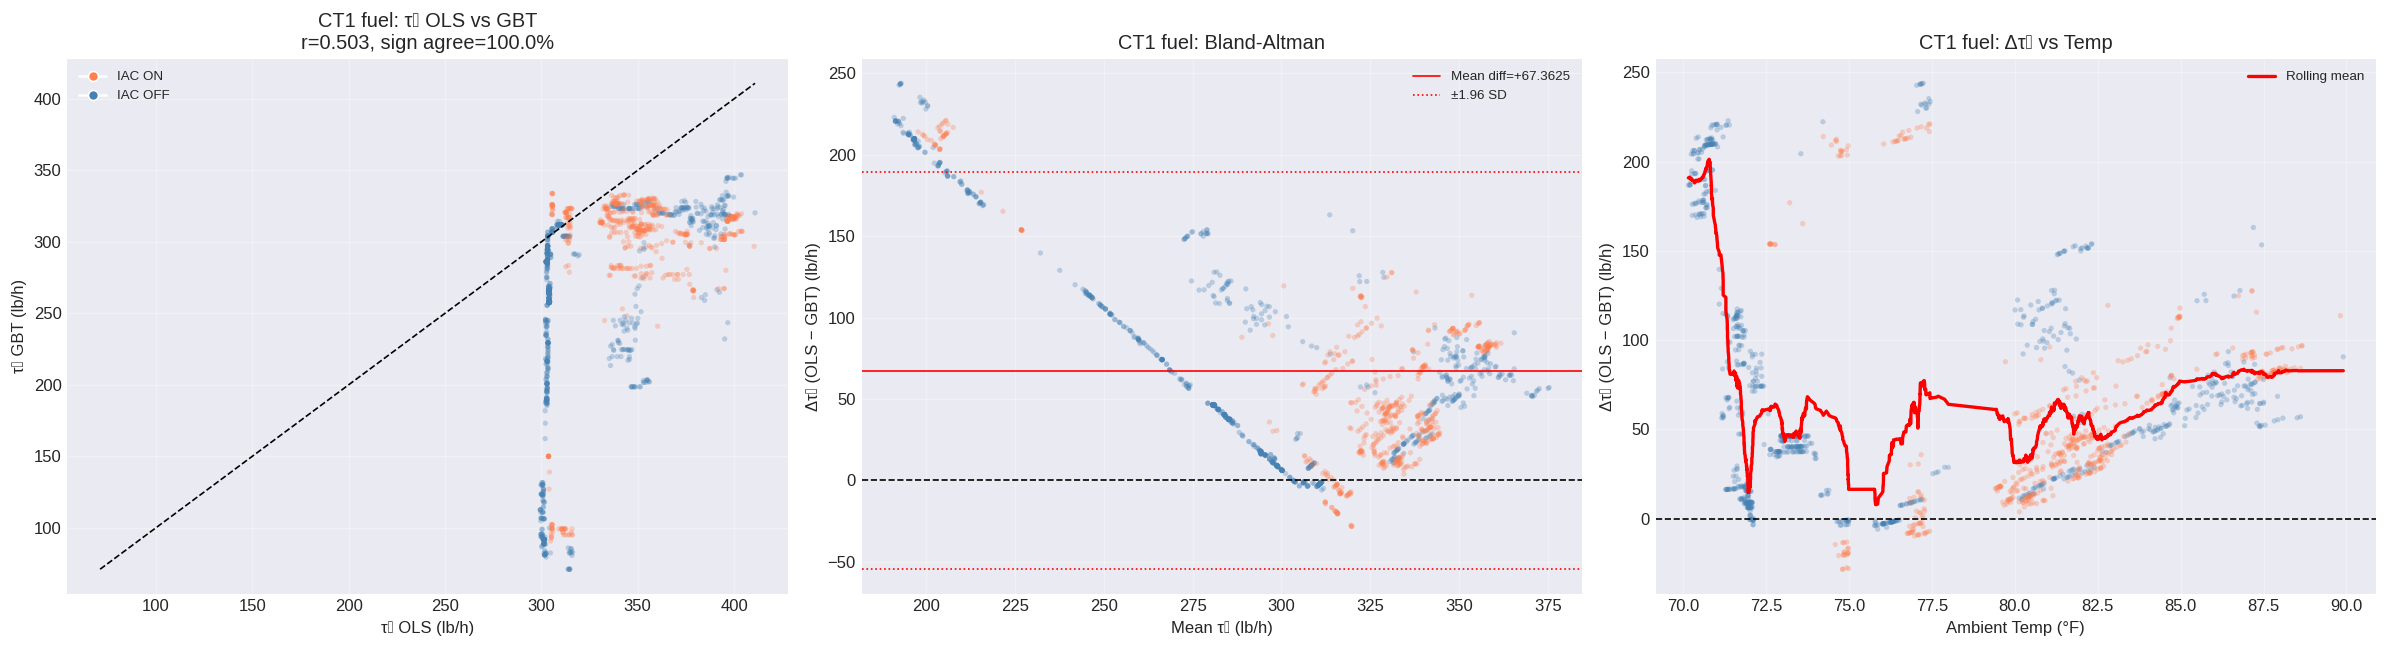

  Saved: ./outputs/compare_ols_gbt/tau_agreement_CT1_fuel_specA.png
  Correlation: 0.5026  |  Sign agreement: 100.0%  |  Mean Δτ̂: +67.3625 lb/h
  CT2: treatment 'full_vs_off' -> dropped 1,735 partial rows
  CT2: decontamination (+/-10min) -> dropped 328 rows
  CT2: temp [55-110F] -> 42,046 rows


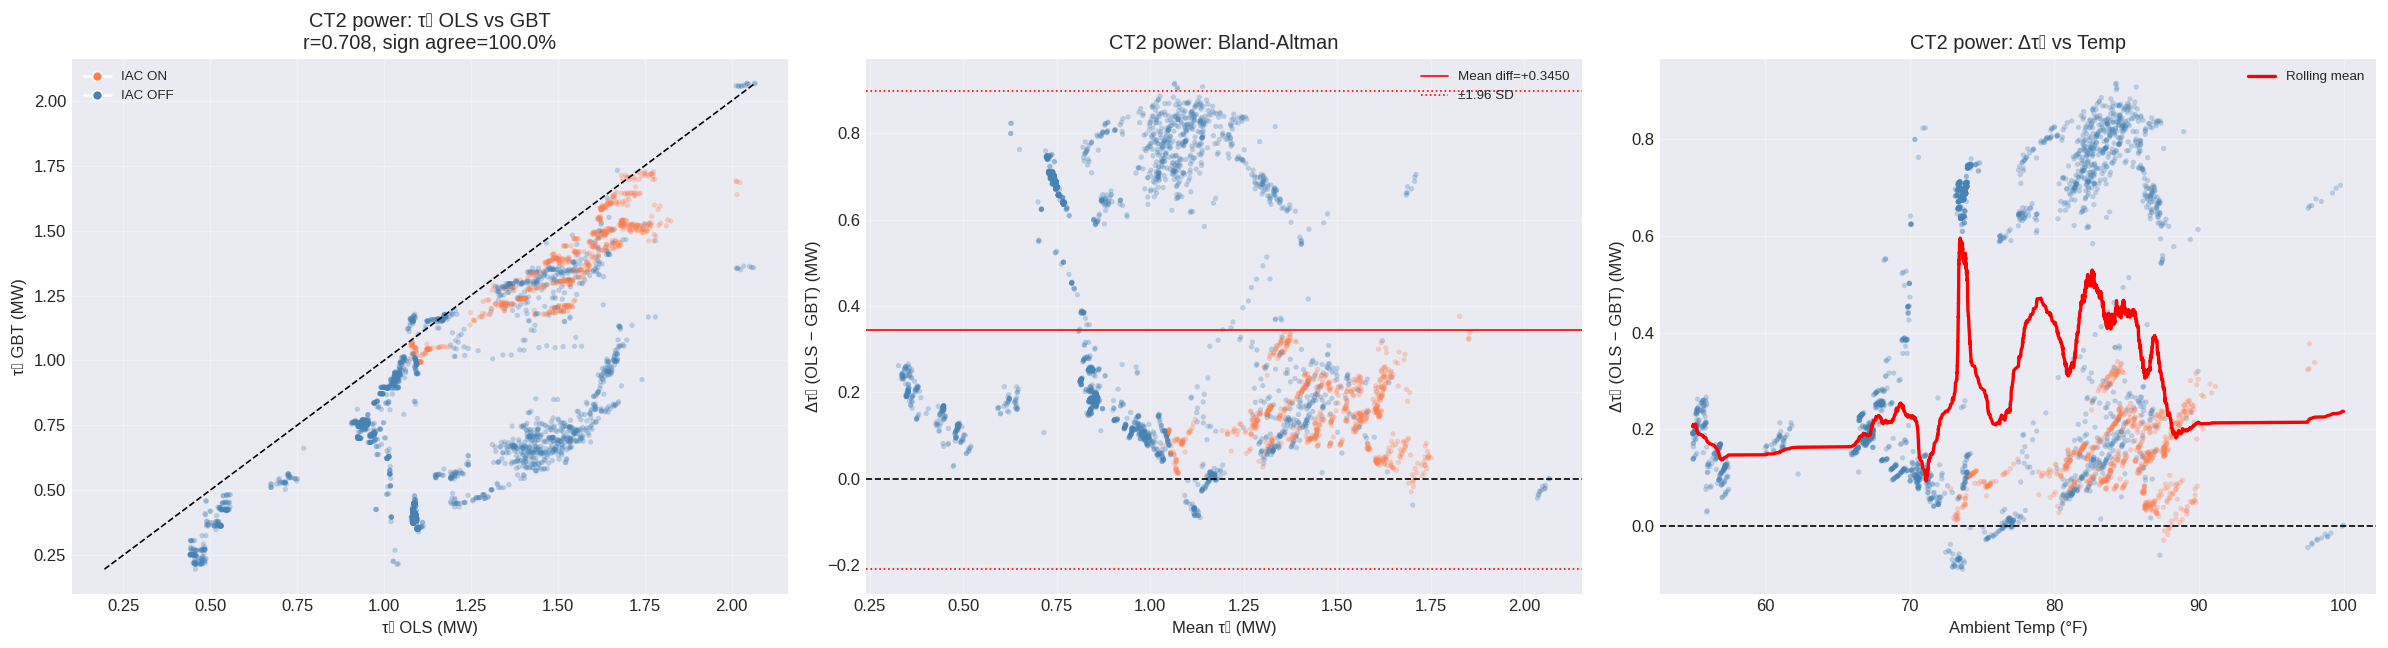

  Saved: ./outputs/compare_ols_gbt/tau_agreement_CT2_power_specA.png
  Correlation: 0.7079  |  Sign agreement: 100.0%  |  Mean Δτ̂: +0.3450 MW


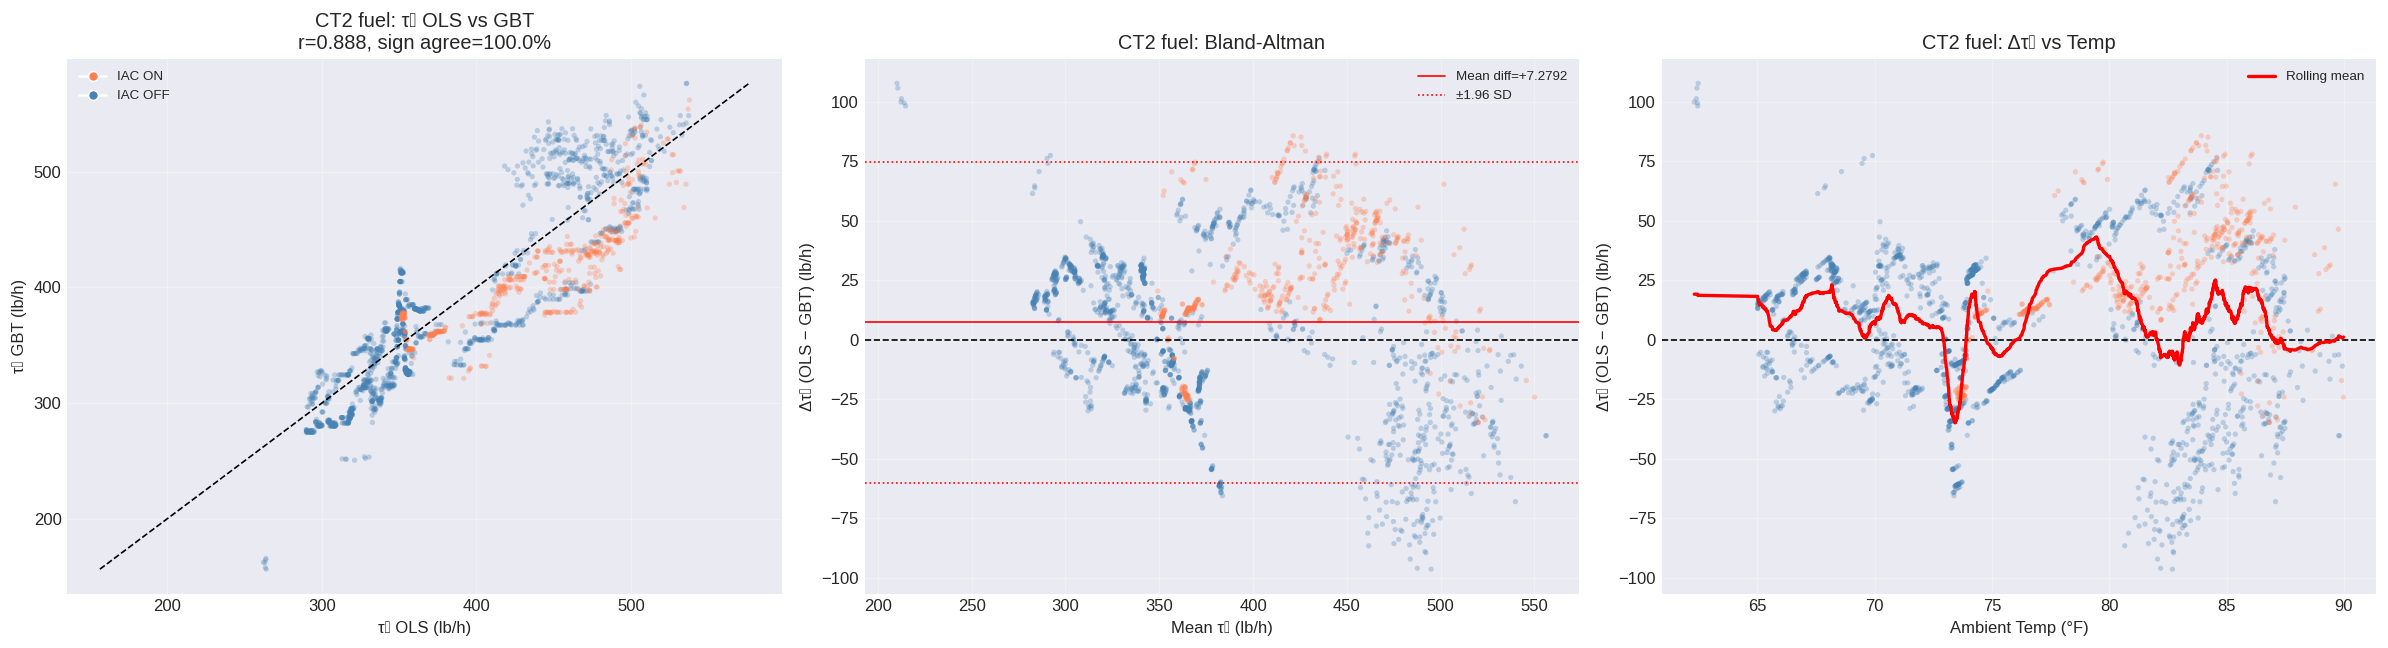

  Saved: ./outputs/compare_ols_gbt/tau_agreement_CT2_fuel_specA.png
  Correlation: 0.8875  |  Sign agreement: 100.0%  |  Mean Δτ̂: +7.2792 lb/h


In [ ]:
from patsy import cr

# ============================================================================
# 4D. PER-OBSERVATION AGREEMENT: tau scatter, Bland-Altman, sign agreement
# Uses the same fair split computed in 4C above.
# ============================================================================

np.random.seed(CONFIG['seed'])

for ct_prefix, ct_label, df_raw in [('ct1','CT1',df_ct1), ('ct2','CT2',df_ct2)]:
    df_prep = prepare_df(df_raw, ct_label,
                         CONFIG['data']['train_temp_range_F'], CONFIG['treatment'])

    for outcome_name, y_col in get_outcome_cols(ct_prefix).items():
        if y_col not in df_prep.columns:
            continue

        ols_y_col, formula = build_formula(ct_prefix, SPEC, y_col=y_col)
        x_base = get_feature_cols(ct_prefix, SPEC)
        available_x = [c for c in x_base if c in df_prep.columns]
        needed = [y_col, 'D', 'hour', 'day', 'ambient_air_temp_f'] + available_x
        df_clean = df_prep.dropna(subset=[c for c in needed if c in df_prep.columns]).copy()
        if len(df_clean) < 200:
            continue

        # Same split as 4C
        unique_days = np.array(sorted(df_clean['day'].unique()))
        n_test = max(1, int(len(unique_days) * CONFIG['compare']['test_days_frac']))
        test_days = np.random.choice(unique_days, size=n_test, replace=False)
        df_train = df_clean[~df_clean['day'].isin(test_days)].copy()
        df_test  = df_clean[ df_clean['day'].isin(test_days)].copy()

        if CONFIG['overlap']['enabled']:
            _, ovl_meta_tr = apply_overlap_filter(df_train, CONFIG['overlap'])
            grid, bins = ovl_meta_tr['grid'], ovl_meta_tr['bins']
            mask_te, _ = _build_strong_mask(df_test, grid, bins)
            df_test = df_test[mask_te.values].copy()

        if len(df_test) < 50:
            continue

        # Fit
        try:
            m_ols = smf.ols(formula, data=df_train).fit()
        except:
            continue
        X_tr_gbt, feat_names = prepare_Xy_gbt(df_train, ct_prefix, SPEC)
        y_tr_gbt = df_train[y_col]
        mask_g = X_tr_gbt.notna().all(axis=1) & y_tr_gbt.notna()
        m_gbt = LGBMRegressor(**CONFIG['compare']['lgbm_params'])
        m_gbt.fit(X_tr_gbt.loc[mask_g, feat_names].values, y_tr_gbt.loc[mask_g].values)

        # Counterfactual tau on test
        ts = df_test.copy()

        # Clip + hour filter
        t_lo_train = df_train['ambient_air_temp_f'].min()
        t_hi_train = df_train['ambient_air_temp_f'].max()
        ts['ambient_air_temp_f'] = ts['ambient_air_temp_f'].clip(t_lo_train, t_hi_train)
        hours_tr = set(df_train['hour'].unique())
        ts = ts[ts['hour'].isin(hours_tr)].copy()
        if len(ts) < 50:
            continue

        ts_on = ts.copy(); ts_on['D'] = 1.0
        ts_off = ts.copy(); ts_off['D'] = 0.0
        tau_ols = m_ols.predict(ts_on) - m_ols.predict(ts_off)

        X_te, _ = prepare_Xy_gbt(ts, ct_prefix, SPEC)
        for c in feat_names:
            if c not in X_te.columns: X_te[c] = 0
        X_te = X_te[feat_names]
        X1 = X_te.copy(); X1['D'] = 1.0
        X0 = X_te.copy(); X0['D'] = 0.0
        tau_gbt = m_gbt.predict(X1[feat_names].values) - m_gbt.predict(X0[feat_names].values)

        tau_ols = np.array(tau_ols, dtype=float)
        tau_gbt = np.array(tau_gbt, dtype=float)
        temp    = ts['ambient_air_temp_f'].values
        D_vals  = ts['D'].values

        unit = 'MW' if outcome_name == 'power' else 'lb/h'
        corr = np.corrcoef(tau_ols, tau_gbt)[0,1]
        sign_agree = np.mean(np.sign(tau_ols) == np.sign(tau_gbt)) * 100

        # ---------- PLOTS ----------
        fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

        # (1) Scatter: tau_OLS vs tau_GBT
        ax = axes[0]
        colors = np.where(D_vals == 1, 'coral', 'steelblue')
        ax.scatter(tau_ols, tau_gbt, c=colors, alpha=0.3, s=10, edgecolors='none')
        lims = [min(tau_ols.min(), tau_gbt.min()), max(tau_ols.max(), tau_gbt.max())]
        ax.plot(lims, lims, 'k--', lw=1)
        ax.set_xlabel(f'τ̂ OLS ({unit})')
        ax.set_ylabel(f'τ̂ GBT ({unit})')
        ax.set_title(f'{ct_label} {outcome_name}: τ̂ OLS vs GBT\n'
                     f'r={corr:.3f}, sign agree={sign_agree:.1f}%')
        ax.legend(handles=[
            plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='coral', label='IAC ON'),
            plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', label='IAC OFF'),
        ], fontsize=8, loc='upper left')

        # (2) Bland-Altman: mean vs diff
        ax = axes[1]
        mean_tau = (tau_ols + tau_gbt) / 2
        diff_tau = tau_ols - tau_gbt
        ax.scatter(mean_tau, diff_tau, c=colors, alpha=0.3, s=10, edgecolors='none')
        ax.axhline(0, color='k', ls='--', lw=1)
        ax.axhline(diff_tau.mean(), color='red', ls='-', lw=1, label=f'Mean diff={diff_tau.mean():+.4f}')
        ax.axhline(diff_tau.mean() + 1.96*diff_tau.std(), color='red', ls=':', lw=1, label='±1.96 SD')
        ax.axhline(diff_tau.mean() - 1.96*diff_tau.std(), color='red', ls=':', lw=1)
        ax.set_xlabel(f'Mean τ̂ ({unit})')
        ax.set_ylabel(f'Δτ̂ (OLS − GBT) ({unit})')
        ax.set_title(f'{ct_label} {outcome_name}: Bland-Altman')
        ax.legend(fontsize=8)

        # (3) Difference vs Temperature
        ax = axes[2]
        ax.scatter(temp, diff_tau, c=colors, alpha=0.3, s=10, edgecolors='none')
        ax.axhline(0, color='k', ls='--', lw=1)
        # LOESS-like smooth via rolling bin mean
        temp_sort_idx = np.argsort(temp)
        temp_sorted = temp[temp_sort_idx]
        diff_sorted = diff_tau[temp_sort_idx]
        win = max(len(temp)//20, 30)
        smooth_diff = pd.Series(diff_sorted).rolling(win, center=True, min_periods=10).mean().values
        ax.plot(temp_sorted, smooth_diff, 'red', lw=2, label='Rolling mean')
        ax.set_xlabel('Ambient Temp (°F)')
        ax.set_ylabel(f'Δτ̂ (OLS − GBT) ({unit})')
        ax.set_title(f'{ct_label} {outcome_name}: Δτ̂ vs Temp')
        ax.legend(fontsize=8)

        plt.tight_layout()
        fname = f'tau_agreement_{ct_label}_{outcome_name}_spec{SPEC}.png'
        fig.savefig(f'{CMP_OUT}/{fname}', dpi=150, bbox_inches='tight')
        plt.show()
        print(f'  Saved: {CMP_OUT}/{fname}')
        print(f'  Correlation: {corr:.4f}  |  Sign agreement: {sign_agree:.1f}%  |  '
              f'Mean Δτ̂: {diff_tau.mean():+.4f} {unit}')